# 🎙️ Speech AI & Voice Agents — From Waveforms to Real-Time Conversations

> **What you'll learn:** how sound becomes numbers (sample rate, bit depth, telephony audio, spectrograms, the mel scale, log-mel features and MFCCs); how speech recognition works (CTC, encoder–decoder **Whisper**, transducers) and how to measure it honestly with **WER** and text normalization, timestamps, long-form chunking, real-time factor and noise; how **text-to-speech** turns text into a waveform with an acoustic model and a vocoder, and how to check it with a round trip through ASR; how **voice activity detection**, endpointing and barge-in decide *when* to talk; and how to build, time and evaluate a cascaded **speech → LLM with a tool → speech** voice agent. You finish with a voice FAQ assistant on real bank-customer phone recordings.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Vision-Language Models and Multimodal RAG](02_Vision_Language_Models_and_Multimodal_RAG.ipynb) (previous notebook in this module) · [Hugging Face Transformers](../05_NLP/03_HuggingFace_Transformers.ipynb) (pipelines, encoder–decoder models, loading on MPS) · [Production Agents: Observability, Reliability, Cost](../16_Agentic_AI/08_Production_Agents_Observability_Reliability_Cost.ipynb) (tool calling, streaming, latency percentiles, caching) |
| **Tested with** | Python 3.12 · torch 2.14 (Apple MPS or CPU) · transformers 5.17 · torchcodec 0.16 · soundfile 0.14 · jiwer 4.0 · onnxruntime 1.30 · scipy 1.18 · openai 3.13 · local **gpt-oss-20b** served by llama.cpp |
| **Interview relevance** | ⭐⭐⭐ High for AI engineer roles that touch voice — "how does Whisper work?", "CTC vs encoder–decoder", "what does WER hide?", "why is my voice bot slow / why does it interrupt people?", "cascaded vs speech-to-speech", "design a call-centre voice agent", "what about voice cloning and deepfakes?" |

**🧩 This notebook completes the Multimodal & Generative Models module (3 notebooks):**

| # | Notebook | Focus |
|---|---|---|
| 01 | [Generative Models: VAEs, GANs and Diffusion](01_Generative_Models_VAEs_GANs_Diffusion.ipynb) | how models generate images |
| 02 | [Vision-Language Models and Multimodal RAG](02_Vision_Language_Models_and_Multimodal_RAG.ipynb) | models that read images and documents |
| 03 | **Speech AI and Voice Agents** (you are here) | models that listen and speak |

## 🤔 What Is Speech AI?

Imagine phoning a bank and talking to a very fast **human interpreter** who doesn't speak your language but has a colleague who does. The interpreter has to:

1. **Hear you**: turn the sound of your voice into words. That is **automatic speech recognition (ASR)**, also called **speech-to-text (STT)**.
2. **Pass the words to a colleague who thinks**: an **LLM** that understands the request and may look something up with a **tool**.
3. **Speak the answer**: turn text back into sound. That is **text-to-speech (TTS)**, also called speech synthesis.
4. **Know when you've finished talking**, and stop talking when you interrupt. That is **voice activity detection (VAD)**, **endpointing** and **barge-in**.

```
  caller's voice ──► [ VAD: is anyone speaking? ] ──► [ endpointing: has the turn ended? ]
                                                             │
                                                             ▼
                     [ ASR: audio → text ] ──► [ LLM + tools: text → reply ] ──► [ TTS: reply → audio ] ──► caller hears
                              ▲                                                             │
                              └──────────── barge-in: caller talks over the bot → stop TTS ◄┘
```

This chain is called a **cascaded voice agent**. The alternative is a **speech-to-speech** model that listens and speaks directly, without text in the middle (Section 10).

A few words we will use all the time:
- **Waveform**: the list of numbers a microphone produces, one per tiny moment in time.
- **Sample rate**: how many of those numbers per second (16,000 for most speech models, 8,000 for phone lines).
- **Spectrogram**: a picture of which pitches (frequencies) are loud at each moment. Speech models read a version of it called the **log-mel spectrogram**.
- **WER** (word error rate): the share of words the recognizer got wrong. The standard ASR metric.
- **Latency**: how long the caller waits. For voice, the key number is **time to first audio**: from the moment the caller stops talking to the moment they hear the bot.

## 🎯 Why It Matters

- **Voice is the most natural interface.** Call centres, in-car assistants, accessibility tools, meeting transcription, dictation, language learning and hands-free apps all run on ASR and TTS. Voice agents on phone lines are one of the fastest-growing uses of LLMs.
- **The hard parts are not the models.** Open models like Whisper transcribe clean speech very well. What breaks products is everything around them: 8 kHz phone audio, background noise, numbers read aloud, hallucinated words on silence, callers being cut off mid-sentence, bots that feel slow, and transcripts full of personal data.
- **Latency is the product.** In conversation people usually answer within a fraction of a second. A voice agent has to fit VAD, ASR, an LLM and TTS into roughly the same window. That forces streaming, small models and careful measurement. You will time every stage on this laptop.
- **In interviews** for AI engineer roles you may be asked how Whisper works, CTC vs encoder–decoder vs transducer, what WER measures and hides, how to reduce voice-agent latency, how endpointing and barge-in work, cascaded vs speech-to-speech, how to evaluate a voice agent, telephony constraints, voice cloning and deepfake safety, and to design a call-centre agent. Each one is practised here with real audio.

## ✅ By the End You Can

- [ ] Explain waveforms, sample rate, bit depth, Nyquist and aliasing, telephony audio, spectrograms, the mel scale, log-mel features and MFCCs, and compute them with real audio
- [ ] Run Whisper on a licence-checked test set and report WER correctly: text normalization, timestamps, long-form chunking, real-time factor and robustness to real noise
- [ ] Describe the TTS pipeline (text → tokens → acoustic model → vocoder), run a permissively licensed TTS model, measure its latency, and check intelligibility with a TTS → ASR round trip
- [ ] Build an energy VAD, compare it with a neural VAD, pick an endpointing silence threshold from measured data, and detect barge-in
- [ ] Build a cascaded STT → LLM (with a tool) → TTS voice agent with sentence-level streaming and a measured latency budget (p50/p95), and know how to cut it
- [ ] Evaluate and operate voice agents (WER/CER slices, latency percentiles, task success, MOS proxies, PII in transcripts, spoofing risks), and build a log-mel front end and WER alignment from scratch

## 📋 Table of Contents

1. [Audio Fundamentals: Waveforms, Sample Rate, Bit Depth](#1.-Audio-Fundamentals:-Waveforms,-Sample-Rate,-Bit-Depth-🟢)
2. [Resampling, Aliasing and Telephony Audio](#2.-Resampling,-Aliasing-and-Telephony-Audio-🟢)
3. [Spectrograms, the Mel Scale, Log-Mel Features and MFCCs](#3.-Spectrograms,-the-Mel-Scale,-Log-Mel-Features-and-MFCCs-🟡)
4. [Speech Recognition: CTC, Encoder–Decoder (Whisper) and Transducers](#4.-Speech-Recognition:-CTC,-Encoder–Decoder-(Whisper)-and-Transducers-🟡)
5. [Word Error Rate and Text Normalization](#5.-Word-Error-Rate-and-Text-Normalization-🟡)
6. [Timestamps, Long-Form Audio and Real-Time Factor](#6.-Timestamps,-Long-Form-Audio-and-Real-Time-Factor-🟡)
7. [Robustness: Real Noise and Phone-Line Audio](#7.-Robustness:-Real-Noise-and-Phone-Line-Audio-🔴)
8. [Text-to-Speech: Tokens, Acoustic Model, Vocoder](#8.-Text-to-Speech:-Tokens,-Acoustic-Model,-Vocoder-🟡)
9. [Voice Activity Detection, Endpointing and Barge-In](#9.-Voice-Activity-Detection,-Endpointing-and-Barge-In-🔴)
10. [Voice Agents End to End: STT → LLM with a Tool → TTS](#10.-Voice-Agents-End-to-End:-STT-→-LLM-with-a-Tool-→-TTS-🔴)
11. [Evaluating and Operating Voice Agents](#11.-Evaluating-and-Operating-Voice-Agents-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Voice-FAQ-Assistant-for-Bank-Callers) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cells below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. Audio is decoded with **torchcodec** (FFmpeg-based) and **soundfile**. `librosa` and `torchaudio` are **not** needed.

**What gets downloaded on the first run (about 1.2 GB, then cached).** Every model and dataset is pinned to an exact commit, and every licence was checked:

| What | Size | Licence | Used for |
|---|---|---|---|
| `openai/whisper-tiny.en` and `openai/whisper-base.en` | 151 MB + 290 MB | Apache-2.0 | speech recognition |
| `microsoft/speecht5_tts` + `microsoft/speecht5_hifigan` | 585 MB + 51 MB | MIT | text-to-speech (acoustic model + vocoder) |
| `Matthijs/cmu-arctic-xvectors` (speaker embeddings) | 18 MB | MIT; the voices come from **CMU ARCTIC**, recorded for speech-synthesis research and free for any use with attribution | the TTS voice |
| **LibriSpeech test-clean** (`openslr/librispeech_asr`), 3 of its 27 row groups | ~36 MB | CC BY 4.0 (public-domain audiobooks) | ASR evaluation with human transcripts |
| **MInDS-14** en-US (`PolyAI/minds14`) | 34 MB | CC BY 4.0 | real bank-customer requests at 8 kHz with intent labels |
| 4 noise recordings from **MS-SNSD** (Microsoft) | ~6 MB | MIT | real background noise |
| **Silero VAD** ONNX model | 2.3 MB | MIT | neural voice activity detection (run with onnxruntime; the `silero-vad` package is not needed) |

**Hardware and memory.** Whisper runs on Apple **MPS** when available (else CPU). SpeechT5 runs on the **CPU** because its step-by-step generation loop was faster there than on MPS in our tests. Models stay small, so the notebook's peak memory stays under about 3 GB (it prints the measured peak at the end).

**The LLM (Sections 10 and the Mini Project).** The agent's "brain" is an **OpenAI-compatible** chat server configured by three environment variables:

| Variable | Default | Meaning |
|---|---|---|
| `LLM_BASE_URL` | `http://127.0.0.1:8080/v1` | where the server listens |
| `LLM_MODEL` | `gpt-oss-20b` | model id to request |
| `LLM_API_KEY` | `local` | API key (local servers ignore it) |

To run the model we used: `brew install llama.cpp`, then `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja` (or `llama-server -m /path/to/gpt-oss-20b-MXFP4.gguf --port 8080 --jinja`). The same code works with **Ollama** (`LLM_BASE_URL=http://localhost:11434/v1`), **LM Studio** (`http://localhost:1234/v1`) or **OpenAI** (`https://api.openai.com/v1` plus your key and a model id). gpt-oss is a reasoning model: its hidden reasoning counts toward `max_tokens`, so we send `reasoning_effort: "low"` through llama.cpp's chat-template option and keep outputs short.

**LLM calls, cache and run time.** A fresh run sends about **90 LLM requests**: 1 connection check, 12 in Section 10, and up to 90 routing requests in the Mini Project, where identical transcripts are answered from the cache. It takes roughly **10–20 minutes** on an otherwise idle Apple-silicon laptop. Every timing is measured live, so if other heavy programs compete for memory or the GPU, latencies get slower and noisier; the notebook prints a warning when it detects that. Every reply is stored in `_outputs/speech_ai/llm_cache.json`, keyed by the exact request. On a re-run, a cached reply is **replayed** together with the timings measured when it was really made, and replayed calls are counted separately. Delete the file or set `LLM_CACHE=0` for fresh calls. LLM output is not deterministic, so every conclusion is computed from *this run's* data.

**Voices and consent.** This notebook never records anyone and never clones a real person's voice. All speech comes from licensed datasets whose speakers took part in data collection, and the synthetic voice comes from a corpus recorded for speech-synthesis research.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "torch>=2.4" "transformers>=5.0" "torchcodec>=0.16" "soundfile>=0.13" "jiwer>=4.0" "onnxruntime>=1.20" "openai>=1.99" scipy pyarrow huggingface_hub pandas matplotlib

import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")      # avoids a fork warning from the Rust tokenizers
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")    # keep download/loading bars out of the saved outputs

import gc
import hashlib
import importlib.metadata as md
import io
import json
import math
import re
import resource
import sys
import time
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path

import huggingface_hub
import jiwer
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import scipy.fft
import scipy.signal
import soundfile as sf
import torch
import transformers
from huggingface_hub import HfFileSystem, hf_hub_download
from IPython.display import Audio, display
from torchcodec.decoders import AudioDecoder

transformers.logging.set_verbosity_error()
huggingface_hub.utils.logging.set_verbosity_error()

PACKAGES = ["torch", "transformers", "torchcodec", "soundfile", "jiwer", "onnxruntime", "scipy", "openai"]
print(f"Python {sys.version.split()[0]} | " + " | ".join(f"{p} {md.version(p)}" for p in PACKAGES))

NOTEBOOK_START = time.perf_counter()
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
TTS_DEVICE = "cpu"                                             # SpeechT5's generation loop is faster on CPU here
print(f"ASR device: {DEVICE} | TTS device: {TTS_DEVICE}")

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
OUTPUT_DIR = Path("_outputs") / "speech_ai"                   # everything we write goes here (ignored by git)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HOME = str(Path.home())
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 70)


def rel(path):
    """Print paths relative to the notebook folder, never as absolute home-directory paths."""
    try:
        return Path(path).resolve().relative_to(Path.cwd().resolve()).as_posix()
    except ValueError:
        return str(path).replace(HOME, "~")


def sync():
    """Wait for queued GPU work so timings are real (MPS/CUDA run asynchronously)."""
    if torch.backends.mps.is_available():
        torch.mps.synchronize()
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def free_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def peak_rss_gb():
    """Peak resident memory of this Python process (macOS reports bytes, Linux kilobytes)."""
    peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return peak / 1e9 if sys.platform == "darwin" else peak * 1024 / 1e9


def check(name, got, expected, hint="", atol=1e-6, rtol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None / ...), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, (str, bool, np.bool_)) or b is None:
            return a == b
        if isinstance(b, dict):
            return isinstance(a, dict) and a.keys() == b.keys() and all(close(a[k], b[k]) for k in b)
        if isinstance(b, (list, tuple)) and any(isinstance(x, (str, list, tuple, dict)) or x is None for x in b):
            return isinstance(a, (list, tuple)) and len(a) == len(b) and all(close(x, y) for x, y in zip(a, b))
        try:
            a_arr, b_arr = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
        except (TypeError, ValueError):
            return a == b
        return a_arr.shape == b_arr.shape and bool(np.allclose(a_arr, b_arr, atol=atol, rtol=rtol))

    assert close(got, expected), f"❌ {name}: not quite (got {str(got)[:200]!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | torch 2.14.0 | transformers 5.17.0 | torchcodec 0.16.0 | soundfile 0.14.0 | jiwer 4.0.0 | onnxruntime 1.30.0 | scipy 1.18.1 | openai 3.13.0
ASR device: mps | TTS device: cpu


**Download the data (pinned, cached after the first run).** LibriSpeech's test-clean split is one 350 MB Parquet file on the Hub, split into **row groups** of 100 utterances. Instead of downloading all of it, we open it with `HfFileSystem` and read only 3 row groups. Only those byte ranges travel over the network.

In [2]:
REVISIONS = {
    "openai/whisper-tiny.en": "87c7102498dcde7456f24cfd30239ca606ed9063",
    "openai/whisper-base.en": "911407f4214e0e1d82085af863093ec0b66f9cd6",
    "microsoft/speecht5_tts": "30fcde30f19b87502b8435427b5f5068e401d5f6",
    "microsoft/speecht5_hifigan": "bb6f429406e86a9992357a972c0698b22043307d",
    "Matthijs/cmu-arctic-xvectors": "5c1297a9eb6c91714ea77c0d4ac5aca9b6a952e5",
    "PolyAI/minds14": "40ce77cb32a384e4d50a568e1ec39ac804019d33",
    "openslr/librispeech_asr": "71cacbfb7e2354c4226d01e70d77d5fca3d04ba1",
}
MSSNSD_COMMIT = "fe61c4ba0d9ac8dd7e23d719cc79f8947e1dc742"
SILERO_COMMIT = "867c2aa692646a1f1de3e94a15c9dd9f614c0acb"
DATA_DIR = OUTPUT_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

# LibriSpeech test-clean: 3 row groups (300 utterances) of the pinned Parquet file
LS_PATH = DATA_DIR / "librispeech_test_clean_subset.parquet"
if not LS_PATH.exists():
    remote = f"datasets/openslr/librispeech_asr@{REVISIONS['openslr/librispeech_asr']}/all/test.clean/0000.parquet"
    with HfFileSystem().open(remote, "rb") as f:
        parquet = pq.ParquetFile(f)
        groups = [parquet.read_row_group(i, columns=["audio", "text", "speaker_id", "chapter_id", "id"]) for i in (0, 9, 18)]
    pq.write_table(pa.concat_tables(groups), LS_PATH)

# MInDS-14, US English
MINDS_PATH = hf_hub_download("PolyAI/minds14", "en-US/train-00000-of-00001.parquet", repo_type="dataset",
                             revision=REVISIONS["PolyAI/minds14"])

# Speaker embeddings (x-vectors) for SpeechT5
XVECTOR_ZIP = hf_hub_download("Matthijs/cmu-arctic-xvectors", "spkrec-xvect.zip", repo_type="dataset",
                              revision=REVISIONS["Matthijs/cmu-arctic-xvectors"])

# Noise recordings (MS-SNSD) and the Silero VAD model, each with its licence file
GITHUB_FILES = {
    "noise_AirConditioner_1.wav": f"microsoft/MS-SNSD/{MSSNSD_COMMIT}/noise_test/AirConditioner_1.wav",
    "noise_Babble_2.wav": f"microsoft/MS-SNSD/{MSSNSD_COMMIT}/noise_test/Babble_2.wav",
    "noise_CopyMachine_1.wav": f"microsoft/MS-SNSD/{MSSNSD_COMMIT}/noise_test/CopyMachine_1.wav",
    "noise_VacuumCleaner_1.wav": f"microsoft/MS-SNSD/{MSSNSD_COMMIT}/noise_test/VacuumCleaner_1.wav",
    "MS-SNSD_LICENSE": f"microsoft/MS-SNSD/{MSSNSD_COMMIT}/LICENSE",
    "silero_vad.onnx": f"snakers4/silero-vad/{SILERO_COMMIT}/src/silero_vad/data/silero_vad.onnx",
    "silero_LICENSE": f"snakers4/silero-vad/{SILERO_COMMIT}/LICENSE",
}
for name, remote in GITHUB_FILES.items():
    if not (DATA_DIR / name).exists():
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/{remote}", DATA_DIR / name)

sizes = {"LibriSpeech subset": LS_PATH.stat().st_size, "MInDS-14 en-US": Path(MINDS_PATH).stat().st_size,
         "x-vectors": Path(XVECTOR_ZIP).stat().st_size,
         "noise + Silero": sum((DATA_DIR / n).stat().st_size for n in GITHUB_FILES)}
print("data files (MB):", {k: round(v / 1e6, 1) for k, v in sizes.items()})
for lic in ["MS-SNSD_LICENSE", "silero_LICENSE"]:
    print(f"{lic}: {(DATA_DIR / lic).read_text().strip().splitlines()[0]}")

data files (MB): {'LibriSpeech subset': 36.0, 'MInDS-14 en-US': 34.2, 'x-vectors': 17.9, 'noise + Silero': 6.8}
MS-SNSD_LICENSE: MIT License
silero_LICENSE: MIT License


**Connect to the LLM.** If no server is running, the next cell stops with instructions instead of pretending. The helper `chat()` streams every call, records **time to first token**, the moments each complete sentence arrived (for sentence-level TTS later), token counts and how many prompt tokens the server reused from its **prompt cache**, and stores the reply in the cache described above.

In [3]:
from openai import OpenAI

LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")
client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY, timeout=180, max_retries=2)

try:
    served = [m.id for m in client.models.list().data]
    print(f"✅ LLM server at {LLM_BASE_URL} — models: {served}")
except Exception as exc:
    raise RuntimeError(
        f"This notebook needs an OpenAI-compatible LLM server at {LLM_BASE_URL} ({type(exc).__name__}).\n"
        "Start one locally:  brew install llama.cpp  &&  llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja\n"
        "…or point LLM_BASE_URL / LLM_MODEL / LLM_API_KEY at Ollama, LM Studio, or a hosted provider."
    ) from exc

USE_LLM_CACHE = os.environ.get("LLM_CACHE", "1") == "1"
LLM_CACHE_PATH = OUTPUT_DIR / "llm_cache.json"
_llm_cache = json.loads(LLM_CACHE_PATH.read_text()) if USE_LLM_CACHE and LLM_CACHE_PATH.exists() else {}
LLM_STATS = Counter()
SENTENCE_END = re.compile(r"(.+?[.!?])\s+", re.S)              # a sentence is complete once whitespace follows . ! ?


def pop_sentences(buffer):
    """Split finished sentences off the front of a streaming text buffer; return (sentences, remainder)."""
    sentences = []
    while (m := SENTENCE_END.match(buffer)):
        sentences.append(m.group(1).strip())
        buffer = buffer[m.end():]
    return sentences, buffer


def chat(messages, tools=None, tool_choice=None, max_tokens=512):
    """One streamed chat call → dict with text, tool calls, timings (s) and token counts. Cached by exact request."""
    request = {"model": LLM_MODEL, "messages": messages, "max_tokens": max_tokens, "temperature": 0}
    if tools:
        request["tools"] = tools
    if tool_choice:
        request["tool_choice"] = tool_choice
    key = hashlib.sha256(json.dumps([LLM_BASE_URL, request], sort_keys=True).encode()).hexdigest()
    if USE_LLM_CACHE and key in _llm_cache:
        LLM_STATS["replayed"] += 1
        return {**_llm_cache[key], "replayed": True}

    start = time.perf_counter()
    stream = client.chat.completions.create(**request, stream=True, stream_options={"include_usage": True},
                                            extra_body={"chat_template_kwargs": {"reasoning_effort": "low"}})
    first_token, text, pending, sentences, calls, usage, timings = None, "", "", [], {}, None, {}
    for chunk in stream:
        timings = (chunk.model_extra or {}).get("timings") or timings
        if chunk.usage:
            usage = chunk.usage
        if not chunk.choices:
            continue
        delta = chunk.choices[0].delta
        now = time.perf_counter() - start
        if delta.content:
            first_token = now if first_token is None else first_token
            text += delta.content
            done, pending = pop_sentences(pending + delta.content)
            sentences += [(round(now, 3), s) for s in done]
        for tc in delta.tool_calls or []:
            entry = calls.setdefault(tc.index, {"id": None, "name": "", "arguments": ""})
            entry["id"] = tc.id or entry["id"]
            if tc.function is not None:
                entry["name"] += tc.function.name or ""
                entry["arguments"] += tc.function.arguments or ""
    latency = time.perf_counter() - start
    if pending.strip():
        sentences.append((round(latency, 3), pending.strip()))
    record = {"text": text, "sentences": sentences, "tool_calls": [calls[i] for i in sorted(calls)],
              "first_token_s": round(first_token, 3) if first_token is not None else None, "latency_s": round(latency, 3),
              "prompt_tokens": usage.prompt_tokens if usage else 0, "completion_tokens": usage.completion_tokens if usage else 0,
              "cached_prompt_tokens": int(timings.get("cache_n") or 0)}
    LLM_STATS["real"] += 1
    if USE_LLM_CACHE:
        _llm_cache[key] = record
        LLM_CACHE_PATH.write_text(json.dumps(_llm_cache))
    return {**record, "replayed": False}


hello = chat([{"role": "user", "content": "Reply with exactly one word: ready"}], max_tokens=256)
print(f"reply {hello['text']!r} | {hello['prompt_tokens']} prompt / {hello['completion_tokens']} completion tokens | "
      f"total {hello['latency_s']:.2f}s | replayed={hello['replayed']}")

✅ LLM server at http://127.0.0.1:8080/v1 — models: ['gpt-oss-20b']
reply 'ready' | 74 prompt / 21 completion tokens | total 5.20s | replayed=True


## 1. Audio Fundamentals: Waveforms, Sample Rate, Bit Depth 🟢

A microphone measures **air pressure** many times per second. Each measurement is a **sample**, and the list of samples is the **waveform**.

```
pressure ▲      .-.        .-.
         │    .'   '.    .'   '.         ← the real sound wave (continuous)
         │ ──●───────●──●───────●──►     ← samples taken every 1/16,000 s at 16 kHz
         │            '-'        time
```

| Term | Meaning | Typical values |
|---|---|---|
| **Sample rate** (Hz) | samples per second | 8,000 (phone) · 16,000 (speech models) · 44,100 / 48,000 (music, video) |
| **Bit depth** | bits used to store each sample | 16-bit integers (−32,768 … 32,767) in WAV/FLAC; models use **float32** in −1 … 1 |
| **Channels** | mono (1) or stereo (2) | speech models expect **mono** |
| **Bitrate** of raw PCM | sample rate × bit depth × channels | 16 kHz × 16 bit × 1 = 256 kbit/s |

**PCM** (pulse-code modulation) just means "the raw samples". WAV files usually hold PCM; **FLAC** compresses it without losing anything; MP3/Opus/AAC compress it *lossily*.

Let's load a real utterance from **LibriSpeech test-clean**: read English audiobooks with human transcripts. Each row stores the original FLAC file as bytes. We decode those bytes two independent ways, torchcodec and soundfile, and check they agree.

In [4]:
ls_rows = pq.read_table(LS_PATH).to_pylist()


def decode_audio(data, sample_rate=None):
    """Decode audio bytes (FLAC/WAV/...) to mono float32 in [-1, 1]. torchcodec resamples if sample_rate is given."""
    samples = AudioDecoder(data, sample_rate=sample_rate).get_all_samples()
    return samples.data.mean(dim=0).numpy().astype(np.float32), samples.sample_rate


for row in ls_rows:
    row["wave"], row["sr"] = decode_audio(row["audio"]["bytes"])
durations = np.array([len(r["wave"]) / r["sr"] for r in ls_rows])
print(f"{len(ls_rows)} LibriSpeech test-clean utterances from {len({r['speaker_id'] for r in ls_rows})} speakers | "
      f"sample rates {sorted({r['sr'] for r in ls_rows})} | duration median {np.median(durations):.1f}s, max {durations.max():.1f}s")

example = next(r for r in ls_rows if 9 <= len(r["wave"]) / r["sr"] <= 12)
wave, sr = example["wave"], example["sr"]
info = sf.info(io.BytesIO(example["audio"]["bytes"]))
sf_wave, sf_sr = sf.read(io.BytesIO(example["audio"]["bytes"]), dtype="float32")
print(f"\nutterance {example['id']}: {example['text']!r}")
print(f"file format {info.format} / {info.subtype} (16-bit integers inside) | {info.channels} channel | {info.samplerate} Hz")
print(f"decoded: {len(wave):,} samples × float32 = {wave.nbytes / 1e3:.0f} kB in memory | {len(wave) / sr:.2f}s | "
      f"peak {np.abs(wave).max():.3f} | RMS level {20 * np.log10(np.sqrt(np.mean(wave ** 2))):.1f} dBFS")
print(f"torchcodec vs soundfile: same length {len(sf_wave) == len(wave)}, max difference {np.abs(sf_wave - wave).max():.1e}")
assert sf_sr == sr and np.abs(sf_wave - wave).max() < 1e-6

300 LibriSpeech test-clean utterances from 7 speakers | sample rates [16000] | duration median 4.9s, max 25.9s

utterance 6930-75918-0004: 'SHE TAUGHT HER DAUGHTER THEN BY HER OWN AFFECTION FOR IT THAT LOVE FOR A COUNTRY WHERE THEY HAD BOTH BEEN HOSPITABLY RECEIVED AND WHERE A BRILLIANT FUTURE OPENED BEFORE THEM'
file format FLAC / PCM_16 (16-bit integers inside) | 1 channel | 16000 Hz
decoded: 177,040 samples × float32 = 708 kB in memory | 11.06s | peak 0.439 | RMS level -29.0 dBFS
torchcodec vs soundfile: same length True, max difference 0.0e+00


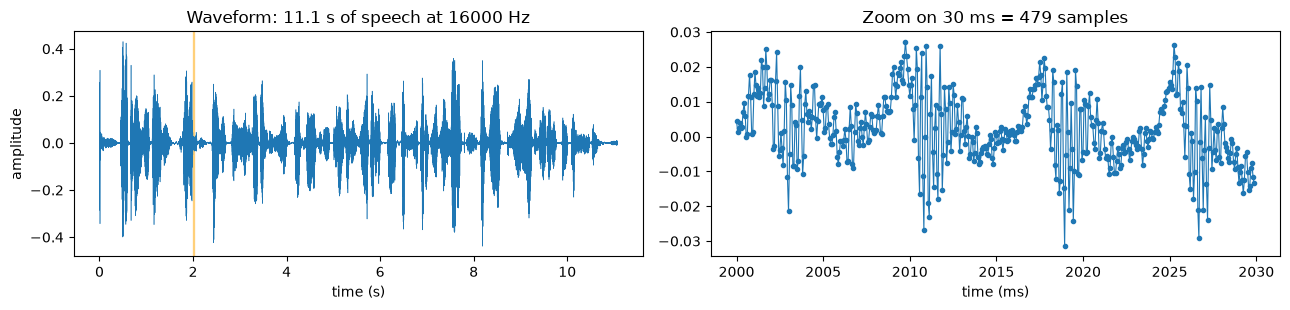

In [5]:
t = np.arange(len(wave)) / sr
zoom = slice(int(2.0 * sr), int(2.03 * sr))                   # 30 ms
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].plot(t, wave, lw=0.4)
axes[0].axvspan(2.0, 2.03, color="orange", alpha=0.4)
axes[0].set(xlabel="time (s)", ylabel="amplitude", title=f"Waveform: {len(wave) / sr:.1f} s of speech at {sr} Hz")
axes[1].plot(t[zoom] * 1000, wave[zoom], marker=".", lw=0.8)
axes[1].set(xlabel="time (ms)", title=f"Zoom on 30 ms = {zoom.stop - zoom.start} samples")
plt.tight_layout()
plt.show()

**Bit depth and quantization noise.** Storing a sample with *b* bits allows 2^b levels. Rounding to those levels adds **quantization noise**. For a full-scale sine wave the signal-to-quantization-noise ratio is about **6.02·b + 1.76 dB**. Speech is quieter than full scale, so it gets less.

Phone networks use only **8 bits** per sample, but not evenly spaced: **μ-law** (North America, Japan) and **A-law** (elsewhere) companding in the ITU **G.711** standard give quiet sounds finer steps, like a logarithmic ruler. At 8,000 samples/s × 8 bits that is **64 kbit/s**. Let's measure both on our real utterance.

In [6]:
def quantize_linear(x, bits):
    levels = 2 ** (bits - 1) - 1
    return np.round(np.clip(x, -1, 1) * levels) / levels


def mu_law_encode(x, mu=255):
    return np.sign(x) * np.log1p(mu * np.abs(x)) / np.log1p(mu)


def mu_law_decode(y, mu=255):
    return np.sign(y) * ((1 + mu) ** np.abs(y) - 1) / mu


def sqnr_db(clean, degraded):
    return 10 * np.log10(np.sum(clean ** 2) / np.sum((clean - degraded) ** 2))


rows = [{"format": f"linear {b}-bit", "SQNR on this speech (dB)": sqnr_db(wave, quantize_linear(wave, b)),
         "full-scale sine rule 6.02b+1.76 (dB)": 6.02 * b + 1.76} for b in (16, 8, 4)]
mu8 = mu_law_decode(quantize_linear(mu_law_encode(wave), 8))
rows.append({"format": "μ-law 8-bit (G.711)", "SQNR on this speech (dB)": sqnr_db(wave, mu8), "full-scale sine rule 6.02b+1.76 (dB)": np.nan})
print(pd.DataFrame(rows).round(1).to_string(index=False))
lin8, mu8_db = rows[1]["SQNR on this speech (dB)"], rows[3]["SQNR on this speech (dB)"]
print(f"\n→ At the same 8 bits, μ-law gives {mu8_db - lin8:+.1f} dB more SQNR than linear on real speech, because most speech samples are quiet.")
for name, rate, bits in [("CD music (stereo)", 44_100, 16 * 2), ("wideband speech", 16_000, 16), ("G.711 phone call", 8_000, 8)]:
    print(f"{name:18s}: {rate:>6,} Hz × {bits:2d} bits = {rate * bits / 1000:6.0f} kbit/s")

             format  SQNR on this speech (dB)  full-scale sine rule 6.02b+1.76 (dB)
      linear 16-bit                      90.3                                  98.1
       linear 8-bit                      24.1                                  49.9
       linear 4-bit                       3.6                                  25.8
μ-law 8-bit (G.711)                      37.4                                   NaN

→ At the same 8 bits, μ-law gives +13.3 dB more SQNR than linear on real speech, because most speech samples are quiet.
CD music (stereo) : 44,100 Hz × 32 bits =   1411 kbit/s
wideband speech   : 16,000 Hz × 16 bits =    256 kbit/s
G.711 phone call  :  8,000 Hz ×  8 bits =     64 kbit/s


### ✍️ Your Turn

How many **bytes** does one minute of raw 16 kHz, 16-bit, mono PCM take? Store an integer in `bytes_one_minute`.

In [7]:
bytes_one_minute = None  # TODO: your code here
check("bytes_one_minute", bytes_one_minute, 1_920_000, hint="samples per second × seconds × bytes per sample (16 bits = 2 bytes).")

⏳ bytes_one_minute: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
bytes_one_minute = 16_000 * 60 * 2
check("bytes_one_minute", bytes_one_minute, 1_920_000)
```

That's about 1.9 MB per minute, or 115 MB per hour. The same audio as float32 in memory takes twice as much, which matters when you batch hours of calls.
</details>

> 💡 **Interview angle:** "What does 16 kHz / 16-bit mean and why do models use it?" — 16,000 samples per second captures frequencies up to 8 kHz (enough for speech intelligibility), and 16-bit integers give ~96 dB of range. Models convert to float32 in [−1, 1]. Phone audio is 8 kHz with 8-bit μ-law/A-law (G.711), i.e. 64 kbit/s.

## 2. Resampling, Aliasing and Telephony Audio 🟢

**Nyquist rule:** a sample rate of *f*ₛ can only represent frequencies below **f**ₛ**/2** (the *Nyquist frequency*). 16 kHz audio holds up to 8 kHz; phone audio at 8 kHz holds only up to 4 kHz.

If a sound contains frequencies above *f*ₛ/2 when you sample it, they don't disappear. They **fold back** and pretend to be lower frequencies. That is **aliasing**, the same effect that makes wagon wheels spin backwards in films. So **resampling** down must first **low-pass filter** (remove everything above the new Nyquist), then keep fewer samples.

A controlled example first (synthetic tone, chosen so the answer is easy to predict): a 5 kHz tone sampled at 8 kHz.

In [8]:
fs_tone = 8_000
tone = np.sin(2 * np.pi * 5_000 * np.arange(fs_tone) / fs_tone)          # 1 s of a 5 kHz tone, sampled at 8 kHz
freqs = np.fft.rfftfreq(fs_tone, 1 / fs_tone)
print(f"5 kHz tone sampled at 8 kHz shows up at {freqs[np.argmax(np.abs(np.fft.rfft(tone)))]:.0f} Hz "
      f"(= 8000 − 5000: folded around the 4 kHz Nyquist frequency)")

5 kHz tone sampled at 8 kHz shows up at 3000 Hz (= 8000 − 5000: folded around the 4 kHz Nyquist frequency)


Now real speech. We turn our 16 kHz utterance into 8 kHz three ways and compare each 8 kHz version's spectrum with the original's 0–3.8 kHz band, which is what a perfect conversion would keep:
- ❌ **naive decimation**: keep every second sample, no filter;
- ✅ `scipy.signal.resample_poly` (polyphase filter, then decimate);
- ✅ torchcodec decoding straight to 8 kHz (FFmpeg's resampler).

naive x[::2] (no filter)     mean |spectrum error| vs original band: 0.53 dB
scipy resample_poly          mean |spectrum error| vs original band: 0.44 dB
torchcodec decode @ 8 kHz    mean |spectrum error| vs original band: 0.51 dB


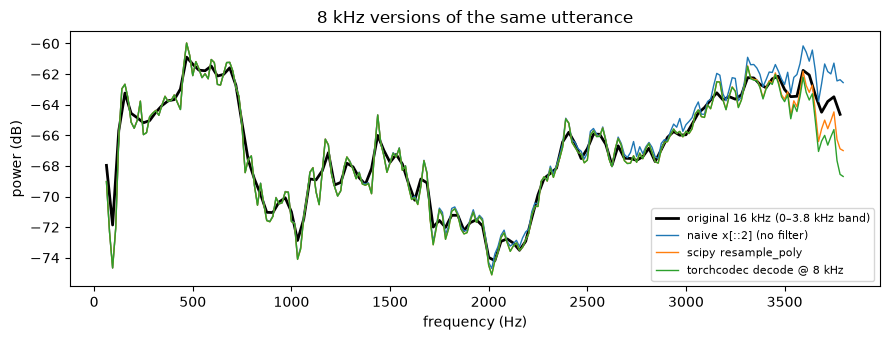

share of this utterance's energy above 4 kHz: 12.78% (much of 's', 'f' and 'th' lives there — why phone speech sounds muffled)
→ skipping the anti-aliasing filter adds +0.09 dB of average spectrum error in the kept band on this utterance. For read speech the folded energy is modest; it grows with louder high frequencies (music, noise, 44.1 → 8 kHz conversions).


In [9]:
def band_psd_db(x, fs, fmax=3800):
    f, p = scipy.signal.welch(x, fs=fs, nperseg=512)
    keep = (f > 50) & (f < fmax)
    return f[keep], 10 * np.log10(p[keep] + 1e-12)


f_ref, psd_ref = band_psd_db(wave, 16_000)
versions = {"naive x[::2] (no filter)": wave[::2],
            "scipy resample_poly": scipy.signal.resample_poly(wave, 1, 2).astype(np.float32),
            "torchcodec decode @ 8 kHz": decode_audio(example["audio"]["bytes"], 8_000)[0]}
spectrum_error = {}
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(f_ref, psd_ref, color="black", lw=2, label="original 16 kHz (0–3.8 kHz band)")
for name, x8 in versions.items():
    f8, p8 = band_psd_db(x8, 8_000)
    p8_on_ref = np.interp(f_ref, f8, p8)
    spectrum_error[name] = float(np.mean(np.abs(p8_on_ref - psd_ref)))
    print(f"{name:28s} mean |spectrum error| vs original band: {spectrum_error[name]:.2f} dB")
    ax.plot(f8, p8, lw=1, label=name)
ax.set(xlabel="frequency (Hz)", ylabel="power (dB)", title="8 kHz versions of the same utterance")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

f_all, p_all = scipy.signal.welch(wave, fs=16_000, nperseg=512)
share_above_4k = p_all[f_all >= 4000].sum() / p_all.sum()
print(f"share of this utterance's energy above 4 kHz: {share_above_4k:.2%} (much of 's', 'f' and 'th' lives there — why phone speech sounds muffled)")
extra_error = spectrum_error["naive x[::2] (no filter)"] - spectrum_error["scipy resample_poly"]
print(f"→ skipping the anti-aliasing filter adds {extra_error:+.2f} dB of average spectrum error in the kept band on this utterance. "
      "For read speech the folded energy is modest; it grows with louder high frequencies (music, noise, 44.1 → 8 kHz conversions).")

**Telephony audio.** A classic phone line (G.711) gives you **8 kHz**, a **300–3,400 Hz** band, and **8-bit μ-law**. Mobile and VoIP calls often use wideband codecs (AMR-WB, Opus), but many call-centre pipelines still deliver 8 kHz μ-law, e.g. telephony media streams sent to your server over a WebSocket. Speech models trained on 16 kHz expect you to **upsample** the audio back to 16 kHz. That doesn't restore the lost high frequencies, but it gives the model the input format it was trained on.

`to_telephone()` below imitates that path on clean audio. We use it in Section 7 to measure what phone audio costs in WER.

In [10]:
TELEPHONE_BAND = scipy.signal.butter(6, [300, 3400], btype="bandpass", fs=8_000, output="sos")


def to_telephone(x16):
    """16 kHz float audio → 8 kHz, 300–3400 Hz, 8-bit μ-law (G.711-style) → back to 16 kHz for the model."""
    x8 = scipy.signal.resample_poly(x16, 1, 2)
    x8 = scipy.signal.sosfiltfilt(TELEPHONE_BAND, x8)
    x8 = mu_law_decode(quantize_linear(mu_law_encode(np.clip(x8, -1, 1)), 8))
    return scipy.signal.resample_poly(x8, 2, 1).astype(np.float32)


phone = to_telephone(wave)
f_p, p_p = scipy.signal.welch(phone, fs=16_000, nperseg=512)
print(f"telephone version: {len(phone):,} samples at 16 kHz | energy above 4 kHz {p_p[f_p >= 4000].sum() / p_p.sum():.4%} | "
      f"waveform SNR vs the original {sqnr_db(wave, phone):.1f} dB (low because everything below 300 Hz and above 3.4 kHz is removed; Section 7 measures what that does to WER)")

telephone version: 177,040 samples at 16 kHz | energy above 4 kHz 0.0004% | waveform SNR vs the original 4.1 dB (low because everything below 300 Hz and above 3.4 kHz is removed; Section 7 measures what that does to WER)


### ✍️ Your Turn

1. A 3-second clip recorded at 44.1 kHz is resampled to 16 kHz. How many samples does it have? 2. What is the Nyquist frequency of 8 kHz phone audio? Store `[n_samples_16k, nyquist_phone_hz]` in `resample_answers`.

In [11]:
resample_answers = None  # TODO: your code here
check("resample_answers", resample_answers, [48_000, 4_000], hint="Samples depend only on duration × new rate; Nyquist = sample rate / 2.")

⏳ resample_answers: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
resample_answers = [3 * 16_000, 8_000 // 2]
check("resample_answers", resample_answers, [48_000, 4_000])
```

The original rate doesn't matter for the sample count. What matters is doing it with an anti-aliasing filter: `scipy.signal.resample_poly(x, 160, 441)` for 44.1 → 16 kHz.
</details>

> 💡 **Interview angle:** "Your ASR model is trained on 16 kHz but the call centre sends 8 kHz μ-law. What do you do?" — decode μ-law, resample to 16 kHz with a proper filter (never just repeat or drop samples), and expect higher WER because nothing above 4 kHz survives. Best fix: fine-tune or evaluate on real 8 kHz data. Always check the sample rate at every boundary.

## 3. Spectrograms, the Mel Scale, Log-Mel Features and MFCCs 🟡

A waveform shows *when* the sound is loud, not *which pitches* are present. The **short-time Fourier transform (STFT)** fixes that:

1. Cut the audio into short overlapping **frames**, e.g. **25 ms** long every **10 ms** (400 and 160 samples at 16 kHz).
2. Multiply each frame by a smooth **window** (Hann) so its edges don't create fake frequencies.
3. Take the Fourier transform of each frame → how much energy each frequency has → one column of the **spectrogram**.

Human hearing is **not linear in frequency**: the step from 100 → 200 Hz sounds as big as 1,000 → 2,000 Hz. The **mel scale** stretches low frequencies and squeezes high ones to match. The HTK formula is **mel = 2595 · log₁₀(1 + f / 700)**. Whisper uses the *Slaney* variant: linear below 1 kHz, logarithmic above.

```
waveform ─► frames (25 ms, hop 10 ms) ─► |FFT|² (201 bins) ─► 80 triangular mel filters ─► log ─► log-mel (80 × frames)
                                                                                        └► DCT, keep 13 ─► MFCCs
```

- **Log-mel spectrogram**: the input to Whisper and most modern speech models. The log matches how we hear loudness.
- **MFCCs** (mel-frequency cepstral coefficients): a **DCT** of the log-mel, keeping ~13 numbers per frame. Compact and decorrelated, so they were the standard for classic GMM-HMM recognizers and are still used in speaker ID and tiny keyword spotters.

Whisper front end: sample rate 16000 | n_fft 400 (25 ms) | hop 160 (10 ms) | 80 mel bins | chunk 30 s | mel filters (201, 80) (frequency bins × mel bins)
    250 Hz → HTK mel   344.2
    500 Hz → HTK mel   607.4
   1000 Hz → HTK mel  1000.0
   2000 Hz → HTK mel  1521.4
   4000 Hz → HTK mel  2146.1
   8000 Hz → HTK mel  2840.0

STFT power spectrogram (201, 1108) (frequency bins × frames) | Whisper log-mel (80, 3000) (mel bins × frames: always 30 s) | real audio fills the first 1106 frames | MFCCs (13, 1108)
log-mel value range -0.90 … 1.10 (log10, clamped to max−8, then (x+4)/4)


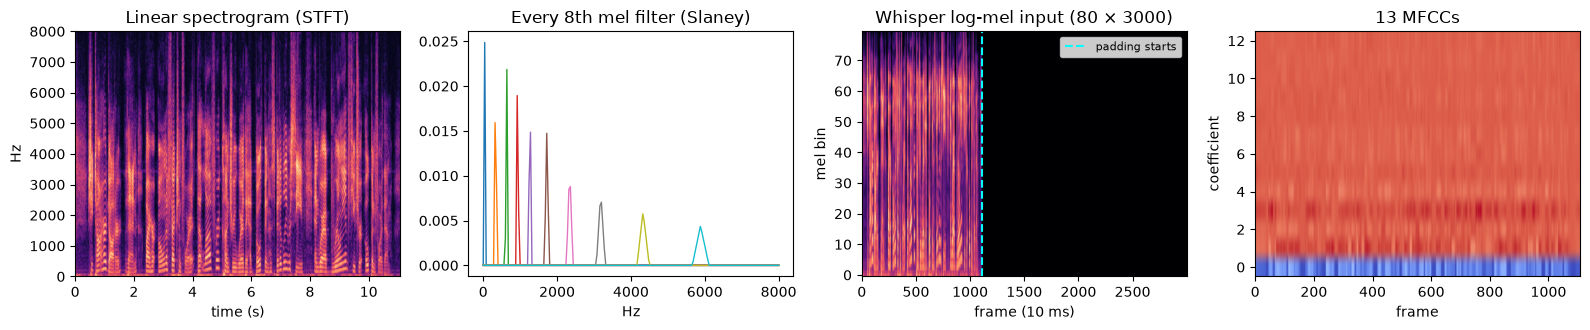

In [12]:
from transformers import WhisperFeatureExtractor

feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-tiny.en", revision=REVISIONS["openai/whisper-tiny.en"])
print(f"Whisper front end: sample rate {feature_extractor.sampling_rate} | n_fft {feature_extractor.n_fft} (25 ms) | "
      f"hop {feature_extractor.hop_length} (10 ms) | {feature_extractor.feature_size} mel bins | chunk {feature_extractor.chunk_length} s | "
      f"mel filters {feature_extractor.mel_filters.shape} (frequency bins × mel bins)")

for f_hz in [250, 500, 1000, 2000, 4000, 8000]:
    htk = 2595 * np.log10(1 + f_hz / 700)
    print(f"  {f_hz:5d} Hz → HTK mel {htk:7.1f}")

f_stft, t_stft, Z = scipy.signal.stft(wave, fs=16_000, window="hann", nperseg=400, noverlap=240)
power_db = 10 * np.log10(np.abs(Z) ** 2 + 1e-10)
features = feature_extractor(wave, sampling_rate=16_000, return_tensors="np").input_features[0]
n_real = len(wave) // feature_extractor.hop_length                   # frames that contain the real audio (rest is padding)
log_mel_nat = np.log(np.maximum(feature_extractor.mel_filters.T @ np.abs(Z) ** 2, 1e-10))   # (80 mel bins, frames)
mfcc = scipy.fft.dct(log_mel_nat, type=2, axis=0, norm="ortho")[:13]
print(f"\nSTFT power spectrogram {power_db.shape} (frequency bins × frames) | Whisper log-mel {features.shape} (mel bins × frames: always 30 s) | "
      f"real audio fills the first {n_real} frames | MFCCs {mfcc.shape}")
print(f"log-mel value range {features.min():.2f} … {features.max():.2f} (log10, clamped to max−8, then (x+4)/4)")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
axes[0].imshow(power_db, origin="lower", aspect="auto", extent=[0, t_stft[-1], 0, 8000], cmap="magma", vmin=power_db.max() - 80)
axes[0].set(xlabel="time (s)", ylabel="Hz", title="Linear spectrogram (STFT)")
axes[1].plot(np.linspace(0, 8000, 201), feature_extractor.mel_filters[:, ::8], lw=1)
axes[1].set(xlabel="Hz", title="Every 8th mel filter (Slaney)")
axes[2].imshow(features, origin="lower", aspect="auto", cmap="magma")
axes[2].axvline(n_real, color="cyan", ls="--", label="padding starts")
axes[2].set(xlabel="frame (10 ms)", ylabel="mel bin", title="Whisper log-mel input (80 × 3000)")
axes[2].legend(fontsize=8, loc="upper right")
axes[3].imshow(mfcc, origin="lower", aspect="auto", cmap="coolwarm")
axes[3].set(xlabel="frame", ylabel="coefficient", title="13 MFCCs")
plt.tight_layout()
plt.show()

Notice in the log-mel panel that Whisper **always pads (or cuts) to 30 seconds**: 480,000 samples → 3,000 frames. That's why feeding Whisper longer audio needs chunking (Section 6), and why Whisper on very short clips spends most of its encoder work on padding.

### ✍️ Your Turn

Write `htk_mel(f_hz)` using the HTK formula (it should work on NumPy arrays).

In [13]:
def htk_mel(f_hz):
    return None  # TODO: your code here


check("htk_mel", htk_mel(np.array([0.0, 700.0, 1000.0, 4000.0])), [0.0, 781.1728, 999.9856, 2146.0645],
      atol=1e-3, hint="2595 * np.log10(1 + f_hz / 700)")

⏳ htk_mel: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def htk_mel(f_hz):
    return 2595 * np.log10(1 + np.asarray(f_hz) / 700)


check("htk_mel", htk_mel(np.array([0.0, 700.0, 1000.0, 4000.0])), [0.0, 781.1728, 999.9856, 2146.0645], atol=1e-3)
```

The constants were chosen so 1,000 Hz ≈ 1,000 mel. Going from 1 kHz to 4 kHz (4×) only adds ~1,150 mel: high frequencies are squeezed together, just as our ears resolve them less finely.
</details>

> 💡 **Interview angle:** "Why do speech models use log-mel spectrograms?" — the STFT exposes frequency content over time; mel filters match human pitch resolution and shrink 201 bins to 80; the log compresses loudness like our hearing and makes the features better behaved for neural nets. MFCCs add a DCT to decorrelate them, which mattered for GMMs but not for deep nets.

## 4. Speech Recognition: CTC, Encoder–Decoder (Whisper) and Transducers 🟡

The hard part of ASR is **alignment**: 10 seconds of audio is ~1,000 feature frames, but maybe 25 words, and nobody tells the model which frames belong to which word. Three model families solve it differently:

| Family | How it outputs text | Streaming? | Examples |
|---|---|---|---|
| **CTC** (Connectionist Temporal Classification) | an encoder predicts a character/token **or a blank** for every frame; collapse repeats and drop blanks | ✅ natural (each frame decided with limited look-ahead) | wav2vec 2.0 / HuBERT fine-tuned with CTC |
| **Attention encoder–decoder** | an encoder reads all the audio; a decoder **writes tokens one by one** like a language model, attending to the encoder | ❌ needs the whole chunk; can **hallucinate** fluent text | **Whisper**, older LAS models |
| **Transducer** (RNN-T, TDT) | encoder + a *prediction network* over the tokens so far + a *joint network*; emits tokens as frames arrive | ✅ built for streaming, used in on-device and production ASR | Conformer-Transducer models (e.g. NVIDIA Parakeet) |

**CTC in one picture** (a controlled, hand-written example of frame predictions):

```
frames:  h h _ e e _ l l _ l o o _      (_ = blank)
collapse repeats → h _ e _ l _ l o _   → drop blanks → "hello"
```

The blank lets CTC output double letters ("ll") and silence. CTC assumes each frame's prediction is independent of the others, so it's fast but benefits from an external language model. An encoder–decoder's decoder *is* a language model: more fluent, but it can keep writing plausible text that was never said.

**Whisper** (OpenAI, 2022) is an encoder–decoder transformer trained on 680,000 hours of weakly supervised, internet-scale audio paired with transcripts:

```
30 s audio ─► 80-bin log-mel (3000 frames) ─► 2 conv layers (stride 2) ─► 1500 encoder positions (20 ms each) ─► transformer encoder
                                                                                                                      │ cross-attention
<|startoftranscript|> <|en|> <|transcribe|> <|notimestamps|> ─► transformer decoder ─► " Concord returned to its place…" <|endoftext|>
```

Special tokens select the **language**, the **task** (transcribe or translate to English) and whether to predict **timestamps**. The `.en` checkpoints are English-only and skip the language and task tokens. Sizes: tiny 39M, base 74M, small 244M, medium 769M, large 1.55B parameters.

In [14]:
def ctc_greedy_collapse(frame_labels, blank="_"):
    """Collapse repeated frame labels, then remove blanks (CTC greedy decoding)."""
    out, previous = [], None
    for label in frame_labels:
        if label != previous and label != blank:
            out.append(label)
        previous = label
    return "".join(out)


print(ctc_greedy_collapse(list("hh_ee_ll_lloo_")), "|", ctc_greedy_collapse(list("hh_ee_llllo_")), "← without a blank between the l's, 'll' collapses to 'l'")

hello | helo ← without a blank between the l's, 'll' collapses to 'l'


In [15]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor, pipeline

ASR_MODELS = {"tiny.en": "openai/whisper-tiny.en", "base.en": "openai/whisper-base.en"}
asr_pipes = {name: pipeline("automatic-speech-recognition", model=repo, revision=REVISIONS[repo], device=DEVICE, dtype=torch.float32)
             for name, repo in ASR_MODELS.items()}
whisper_normalize = asr_pipes["tiny.en"].tokenizer.normalize             # Whisper's English text normalizer (Section 5)
for name, pipe in asr_pipes.items():
    cfg = pipe.model.config
    print(f"whisper-{name}: {sum(p.numel() for p in pipe.model.parameters()) / 1e6:.0f}M params | encoder {cfg.encoder_layers} layers, "
          f"decoder {cfg.decoder_layers} layers, width {cfg.d_model} | {cfg.num_mel_bins} mel bins | {cfg.max_source_positions} encoder positions")

tiny_model, tiny_processor = asr_pipes["tiny.en"].model, WhisperProcessor.from_pretrained(ASR_MODELS["tiny.en"], revision=REVISIONS["openai/whisper-tiny.en"])
inputs = tiny_processor(wave, sampling_rate=16_000, return_tensors="pt").input_features.to(DEVICE)
with torch.inference_mode():
    encoder_out = tiny_model.model.encoder(inputs).last_hidden_state
    token_ids = tiny_model.generate(inputs)                                    # returns only the newly generated tokens
print(f"\nlog-mel input {tuple(inputs.shape)} → encoder output {tuple(encoder_out.shape)} (batch, positions, width)")
gen_config = tiny_model.generation_config
prompt_ids = [gen_config.decoder_start_token_id] + [token for _, token in (gen_config.forced_decoder_ids or [])]
print("decoder prompt (from generation_config):", tiny_processor.tokenizer.convert_ids_to_tokens(prompt_ids))
print("first generated tokens:", tiny_processor.tokenizer.convert_ids_to_tokens(token_ids[0][:6].tolist()))
print("text:", tiny_processor.batch_decode(token_ids, skip_special_tokens=True)[0].strip())

whisper-tiny.en: 38M params | encoder 4 layers, decoder 4 layers, width 384 | 80 mel bins | 1500 encoder positions
whisper-base.en: 73M params | encoder 6 layers, decoder 6 layers, width 512 | 80 mel bins | 1500 encoder positions



log-mel input (1, 80, 3000) → encoder output (1, 1500, 384) (batch, positions, width)
decoder prompt (from generation_config): ['<|startoftranscript|>', '<|notimestamps|>']
first generated tokens: ['ĠShe', 'Ġtaught', 'Ġher', 'Ġdaughter', ',', 'Ġthen']
text: She taught her daughter, then, by her own affection for it, that love for a country where they had both been hospitably received and where a brilliant future opened for them.


**Transcribe a real test set.** We pick 40 utterances of 3–15 s from our 300 LibriSpeech test-clean rows (7 speakers) and run both Whisper sizes. Each call is timed with the GPU synchronized, after one warm-up call.

In [16]:
def transcribe(pipe, wave16, chunk_long=True, **kwargs):
    """Run an ASR pipeline on 16 kHz float audio; return (output dict, seconds).
    Whisper reads at most 30 s at once, so longer clips are chunked unless chunk_long=False (Section 6 shows why)."""
    if chunk_long and len(wave16) > 30 * 16_000 and "chunk_length_s" not in kwargs:
        kwargs = {**kwargs, "chunk_length_s": 30, "batch_size": 4}
    sync()
    start = time.perf_counter()
    out = pipe({"raw": np.asarray(wave16, dtype=np.float32).copy(), "sampling_rate": 16_000}, **kwargs)
    sync()
    return out, time.perf_counter() - start


candidates = [i for i, r in enumerate(ls_rows) if 3 <= len(r["wave"]) / 16_000 <= 15]
test_set = [ls_rows[i] for i in sorted(np.random.default_rng(0).choice(candidates, 40, replace=False))]
test_audio_s = sum(len(r["wave"]) for r in test_set) / 16_000
print(f"test set: {len(test_set)} utterances, {len({r['speaker_id'] for r in test_set})} speakers, {test_audio_s:.0f} s of audio")

asr_results = {}
for name, pipe in asr_pipes.items():
    transcribe(pipe, test_set[0]["wave"])                                   # warm-up (kernel compilation, caches)
    outs = [transcribe(pipe, r["wave"]) for r in test_set]
    asr_results[name] = {"hyps": [o["text"] for o, _ in outs], "seconds": [s for _, s in outs]}
    print(f"whisper-{name}: {sum(asr_results[name]['seconds']):.1f}s for {test_audio_s:.0f}s of audio on {DEVICE}")
refs = [r["text"] for r in test_set]
print("\nreference :", refs[0])
for name in asr_pipes:
    print(f"{name:10s}:", asr_results[name]["hyps"][0])

test set: 40 utterances, 7 speakers, 233 s of audio


whisper-tiny.en: 5.7s for 233s of audio on mps


whisper-base.en: 10.0s for 233s of audio on mps

reference : CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS
tiny.en   :  Concord returned to its place amidst the tents.
base.en   :  Concorde returned to its place amidst the tents.


### ✍️ Your Turn

Use `ctc_greedy_collapse` to decode the frame labels `"__cc_aa_t__ss_"` with blank `"_"`. Store the text in `ctc_text`.

In [17]:
ctc_text = None  # TODO: your code here
check("ctc_text", ctc_text, "cats", hint="ctc_greedy_collapse(list('__cc_aa_t__ss_'))")

⏳ ctc_text: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ctc_text = ctc_greedy_collapse(list("__cc_aa_t__ss_"))
check("ctc_text", ctc_text, "cats")
```

Real CTC decoders do the same over the arg-max token per frame (greedy), or run beam search with a language model over the frame probabilities.
</details>

> 💡 **Interview angle:** "CTC vs encoder–decoder vs transducer?" — CTC: per-frame labels with a blank, conditionally independent, fast and streamable, weaker without an LM. Encoder–decoder (Whisper): an autoregressive decoder attends to the whole encoded chunk, strong and multilingual but not natively streaming and prone to hallucination. Transducer: adds a prediction network over previous tokens, so it streams and conditions on history. That's why it dominates on-device and low-latency ASR.

## 5. Word Error Rate and Text Normalization 🟡

**WER** compares the hypothesis with a reference after finding the **minimum number of word edits** (a Levenshtein alignment):

$$\text{WER} = \frac{S + D + I}{N}$$

S = substituted words, D = deleted (missed) words, I = inserted (extra) words, N = words in the reference. Because of insertions, **WER can exceed 100%**. **CER** is the same on characters, better for languages without spaces.

The catch: WER counts *strings*. LibriSpeech references are UPPERCASE without punctuation; Whisper writes "Mr. Smith paid $20." A fair comparison **normalizes both sides** first: lowercase, strip punctuation, and standardize spellings and numbers. Whisper ships an **English text normalizer** for exactly this. Watch what each step does to the *same* transcripts:

In [18]:
normalizers = {
    "raw strings": lambda s: s,
    "lowercase": str.lower,
    "basic (lowercase + strip punctuation)": asr_pipes["tiny.en"].tokenizer.basic_normalize,
    "Whisper English normalizer": whisper_normalize,
}
wer_table = pd.DataFrame({name: {norm_name: jiwer.wer([fn(x) for x in refs], [fn(x) for x in asr_results[name]["hyps"]])
                                 for norm_name, fn in normalizers.items()} for name in asr_pipes})
print("corpus WER on the same 40 utterances:\n" + wer_table.round(4).to_string())

norm_refs = [whisper_normalize(x) for x in refs]
norm_hyps = {name: [whisper_normalize(x) for x in asr_results[name]["hyps"]] for name in asr_pipes}
for name in asr_pipes:
    measures = jiwer.process_words(norm_refs, norm_hyps[name])
    print(f"\nwhisper-{name}: WER {measures.wer:.2%} | S={measures.substitutions} D={measures.deletions} I={measures.insertions} "
          f"of N={measures.hits + measures.substitutions + measures.deletions} words | CER {jiwer.cer(norm_refs, norm_hyps[name]):.2%}")

worst = int(np.argmax([jiwer.wer(r, h) if r else 0 for r, h in zip(norm_refs, norm_hyps["tiny.en"])]))
print("\nthe tiny model's worst utterance, aligned:")
print(jiwer.visualize_alignment(jiwer.process_words(norm_refs[worst], norm_hyps["tiny.en"][worst]), show_measures=False))

corpus WER on the same 40 utterances:
                                       tiny.en  base.en
raw strings                             0.9929   0.9943
lowercase                               0.1729   0.1700
basic (lowercase + strip punctuation)   0.0541   0.0512
Whisper English normalizer              0.0498   0.0469

whisper-tiny.en: WER 4.98% | S=28 D=0 I=7 of N=703 words | CER 1.73%

whisper-base.en: WER 4.69% | S=24 D=1 I=8 of N=703 words | CER 1.78%

the tiny model's worst utterance, aligned:
=== SENTENCE 1 ===

REF: *** perchance too kaffar is death might serve him in good stead
HYP: per    chance  to caffer is death might serve him in good stead
       I         S   S      S                                       



**Is base really better than tiny?** 40 utterances is a small sample, so we compute a **paired bootstrap** confidence interval: resample utterances with replacement and recompute both corpus WERs on the same resample.

In [19]:
def utterance_counts(refs_, hyps_):
    """(errors, reference words) per utterance, from jiwer's alignment."""
    rows_ = []
    for r, h in zip(refs_, hyps_):
        m = jiwer.process_words(r, h)
        rows_.append((m.substitutions + m.deletions + m.insertions, m.hits + m.substitutions + m.deletions))
    return np.array(rows_)


counts_tiny, counts_base = utterance_counts(norm_refs, norm_hyps["tiny.en"]), utterance_counts(norm_refs, norm_hyps["base.en"])
boot = np.random.default_rng(SEED).integers(0, len(test_set), size=(2000, len(test_set)))
diff = counts_tiny[boot, 0].sum(1) / counts_tiny[boot, 1].sum(1) - counts_base[boot, 0].sum(1) / counts_base[boot, 1].sum(1)
low, high = np.percentile(diff, [2.5, 97.5])
point = counts_tiny[:, 0].sum() / counts_tiny[:, 1].sum() - counts_base[:, 0].sum() / counts_base[:, 1].sum()
verdict = "base.en is significantly better" if low > 0 else "tiny.en is significantly better" if high < 0 else "the difference is not significant"
print(f"WER(tiny) − WER(base) = {point:+.2%}, 95% bootstrap CI [{low:+.2%}, {high:+.2%}] → {verdict} on these {len(test_set)} utterances")
print(f"utterances where tiny made more errors: {(counts_tiny[:, 0] > counts_base[:, 0]).sum()} | fewer: {(counts_tiny[:, 0] < counts_base[:, 0]).sum()} | same: {(counts_tiny[:, 0] == counts_base[:, 0]).sum()}")

WER(tiny) − WER(base) = +0.28%, 95% bootstrap CI [-0.73%, +1.29%] → the difference is not significant on these 40 utterances
utterances where tiny made more errors: 7 | fewer: 4 | same: 29


### ✍️ Your Turn

An alignment of a 12-word reference found 1 substitution, 2 deletions and 3 insertions. Compute the WER as a fraction and store it in `wer_by_hand`.

In [20]:
wer_by_hand = None  # TODO: your code here
check("wer_by_hand", wer_by_hand, 0.5, hint="(S + D + I) / N, where N counts reference words only.")

⏳ wer_by_hand: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
wer_by_hand = (1 + 2 + 3) / 12
check("wer_by_hand", wer_by_hand, 0.5)
```

The hypothesis has 12 − 2 + 3 = 13 words, but WER always divides by the **reference** length. With enough insertions it exceeds 1.0.
</details>

> 💡 **Interview angle:** "What does WER measure and what are its pitfalls?" — word-level edit distance over reference words: (S+D+I)/N. Pitfalls: normalization choices can move it by 10× (the table above), every word counts equally (a wrong account number costs the same as a wrong "uh"), it can exceed 100%, corpus WER ≠ average of per-utterance WERs, and it ignores meaning. Always report the normalizer, the test set, and slices (accent, noise, domain terms).

## 6. Timestamps, Long-Form Audio and Real-Time Factor 🟡

**Timestamps.** Whisper can predict **segment timestamps** as special tokens (every 20 ms). transformers can also produce **word timestamps** by aligning the decoder's cross-attention with the audio frames (dynamic time warping over selected "alignment heads"). Word timestamps power subtitles, search-in-audio, redaction, and the endpointing analysis in Section 9.

segments: [((0.0, 11.0), ' She taught her daughter, then, by her own affection for it, that love for a country where they had both been hospitably received, and where a brilliant future opened for them.')]
first words: [('She', (0.0, 0.56)), ('taught', (0.56, 0.72)), ('her', (0.72, 0.98)), ('daughter,', (0.98, 1.3)), ('then,', (1.3, 2.18)), ('by', (2.18, 2.48))]


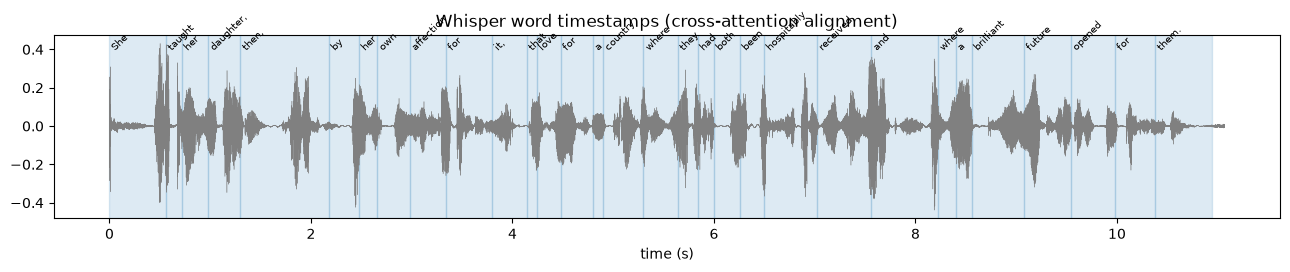

In [21]:
ts_utt = test_set[1]
seg_out, _ = transcribe(asr_pipes["base.en"], ts_utt["wave"], return_timestamps=True)
word_out, _ = transcribe(asr_pipes["base.en"], ts_utt["wave"], return_timestamps="word")
print("segments:", [(c["timestamp"], c["text"]) for c in seg_out["chunks"]])
print("first words:", [(c["text"].strip(), c["timestamp"]) for c in word_out["chunks"][:6]])

tt = np.arange(len(ts_utt["wave"])) / 16_000
fig, ax = plt.subplots(figsize=(13, 2.8))
ax.plot(tt, ts_utt["wave"], lw=0.3, color="gray")
for c in word_out["chunks"]:
    start_s, end_s = c["timestamp"]
    ax.axvspan(start_s, end_s if end_s is not None else tt[-1], alpha=0.15, color="tab:blue")
    ax.text(start_s, 0.9 * np.abs(ts_utt["wave"]).max(), c["text"].strip(), fontsize=7, rotation=45)
ax.set(xlabel="time (s)", title="Whisper word timestamps (cross-attention alignment)")
plt.tight_layout()
plt.show()

**Long-form audio.** Whisper's encoder sees at most 30 s. For a meeting or a call you have two options:
- **Chunked** (`chunk_length_s=30`): cut overlapping 30 s windows, transcribe them as a batch, and merge the overlaps. Batching pays off on a GPU with many windows; the overlaps cost extra compute.
- **Sequential** (OpenAI's original algorithm): transcribe 30 s, use the predicted timestamps to decide where the next window starts, and repeat. No overlap, but windows run one after another.

Which one is faster or more accurate depends on audio length, batch size and hardware, so we measure both.

We build ~110 s of real long-form audio by joining 14 consecutive utterances from one book chapter with 0.5 s of silence between them.

In [22]:
chapter = ls_rows[0]["chapter_id"]
chapter_rows = [r for r in ls_rows if r["chapter_id"] == chapter][:14]
long_wave = np.concatenate([np.concatenate([r["wave"], np.zeros(8_000, np.float32)]) for r in chapter_rows])
long_ref = whisper_normalize(" ".join(r["text"] for r in chapter_rows))
print(f"long-form audio: {len(long_wave) / 16_000:.0f} s, {len(long_ref.split())} reference words")

long_rows = []
try:
    transcribe(asr_pipes["tiny.en"], long_wave, chunk_long=False)       # plain call, no chunking
except ValueError as err:
    print(f"❌ plain call on >30 s audio: ValueError: {str(err)[:150]}…")

out, secs = transcribe(asr_pipes["tiny.en"], long_wave, chunk_length_s=30, batch_size=4)
long_rows.append({"method": "chunked 30 s windows, batch 4", "seconds": secs, "WER": jiwer.wer(long_ref, whisper_normalize(out["text"]))})
long_inputs = tiny_processor(long_wave, sampling_rate=16_000, return_tensors="pt", truncation=False, padding="longest", return_attention_mask=True)
sync()
start = time.perf_counter()
with torch.inference_mode():
    long_ids = tiny_model.generate(long_inputs.input_features.to(DEVICE), attention_mask=long_inputs.attention_mask.to(DEVICE), return_timestamps=True)
sync()
long_rows.append({"method": "sequential long-form generate", "seconds": time.perf_counter() - start,
                  "WER": jiwer.wer(long_ref, whisper_normalize(tiny_processor.batch_decode(long_ids, skip_special_tokens=True)[0]))})
print(f"sequential input features: {tuple(long_inputs.input_features.shape)} (not cut to 3000 frames)")
print(pd.DataFrame(long_rows).round(3).to_string(index=False))
faster = min(long_rows, key=lambda row: row["seconds"])["method"]
more_accurate = min(long_rows, key=lambda row: row["WER"])["method"]
print(f"→ on this run: faster = {faster} | lower WER = {more_accurate} "
      f"(each word is {100 / len(long_ref.split()):.2f} WER points on this {len(long_ref.split())}-word reference, so small gaps are a few words)")

long-form audio: 110 s, 279 reference words


❌ plain call on >30 s audio: ValueError: You have passed more than 3000 mel input features (> 30 seconds) which automatically enables long-form generation which requires the model to predict …


sequential input features: (1, 80, 10963) (not cut to 3000 frames)
                       method  seconds   WER
chunked 30 s windows, batch 4    1.855 0.029
sequential long-form generate    1.141 0.043
→ on this run: faster = sequential long-form generate | lower WER = chunked 30 s windows, batch 4 (each word is 0.36 WER points on this 279-word reference, so small gaps are a few words)


**Real-time factor (RTF)** = processing time ÷ audio duration. RTF 0.05 means one minute of audio takes 3 seconds; **RTF < 1** is required for live use, but it's not sufficient: a live agent also cares about **latency per turn**, the fixed cost of every call, which matters most for short utterances. We measure on this machine, including CPU for comparison.

In [23]:
rtf_rows = []
for name in asr_pipes:
    secs = np.array(asr_results[name]["seconds"])
    durs = np.array([len(r["wave"]) / 16_000 for r in test_set])
    rtf_rows.append({"model": f"whisper-{name}", "device": DEVICE, "RTF": secs.sum() / durs.sum(),
                     "p50 latency per utterance (s)": np.percentile(secs, 50), "p95 latency per utterance (s)": np.percentile(secs, 95)})
cpu_pipe = pipeline("automatic-speech-recognition", model=ASR_MODELS["tiny.en"], revision=REVISIONS["openai/whisper-tiny.en"], device="cpu", dtype=torch.float32)
transcribe(cpu_pipe, test_set[0]["wave"])
cpu_secs = np.array([transcribe(cpu_pipe, r["wave"])[1] for r in test_set[:8]])
cpu_durs = np.array([len(r["wave"]) / 16_000 for r in test_set[:8]])
rtf_rows.append({"model": "whisper-tiny.en", "device": "cpu (8 utterances)", "RTF": cpu_secs.sum() / cpu_durs.sum(),
                 "p50 latency per utterance (s)": np.percentile(cpu_secs, 50), "p95 latency per utterance (s)": np.percentile(cpu_secs, 95)})
del cpu_pipe
free_memory()
rtf_table = pd.DataFrame(rtf_rows)
print(rtf_table.round(3).to_string(index=False))
print(f"\n→ whisper-tiny.en on {DEVICE} transcribes {1 / rtf_table.RTF.iloc[0]:.0f}× faster than real time; base.en {1 / rtf_table.RTF.iloc[1]:.0f}×.")

          model             device   RTF  p50 latency per utterance (s)  p95 latency per utterance (s)
whisper-tiny.en                mps 0.025                          0.124                          0.232
whisper-base.en                mps 0.043                          0.222                          0.398
whisper-tiny.en cpu (8 utterances) 0.051                          0.274                          0.476

→ whisper-tiny.en on mps transcribes 41× faster than real time; base.en 23×.


> 💡 **Interview angle:** "How do you transcribe a 1-hour call with Whisper?" — VAD or fixed 30 s windows with overlap, batched (chunked) for throughput or sequential with timestamps for boundary accuracy; merge overlaps; guard against hallucinations on silence (VAD, `no_speech_threshold`, compression-ratio checks); report RTF and cost per audio hour. For live captions use a streaming-capable model or short windows with partial results.

## 7. Robustness: Real Noise and Phone-Line Audio 🔴

Test-clean is studio-quality reading. Real users are on speakerphone in a café. We add **real noise recordings** from Microsoft's MS-SNSD dataset (MIT licence), a room of people talking (**babble**) and an **air conditioner**, at controlled **signal-to-noise ratios**:

$$\text{SNR}_{dB} = 10 \log_{10} \frac{P_{speech}}{P_{noise}} \quad\Rightarrow\quad \text{noise scale} = \sqrt{\frac{P_{speech}}{P_{noise} \cdot 10^{\text{SNR}/10}}}$$

20 dB is a quiet office; 0 dB means the noise is as loud as the speech. We also test the G.711-style phone path from Section 2.

{'babble': '31 s', 'air conditioner': '23 s'}
requested 5 dB → achieved 5.00 dB


10 conditions × 2 models × 16 utterances in 71s
model                     base.en  tiny.en
condition                                 
clean                       0.073    0.076
phone line (8 kHz μ-law)    0.076    0.076
babble 20 dB                0.065    0.080
babble 10 dB                0.092    0.084
babble 5 dB                 0.126    0.145
babble 0 dB                 0.313    0.328
air conditioner 20 dB       0.069    0.073
air conditioner 10 dB       0.069    0.076
air conditioner 5 dB        0.088    0.084
air conditioner 0 dB        0.095    0.095


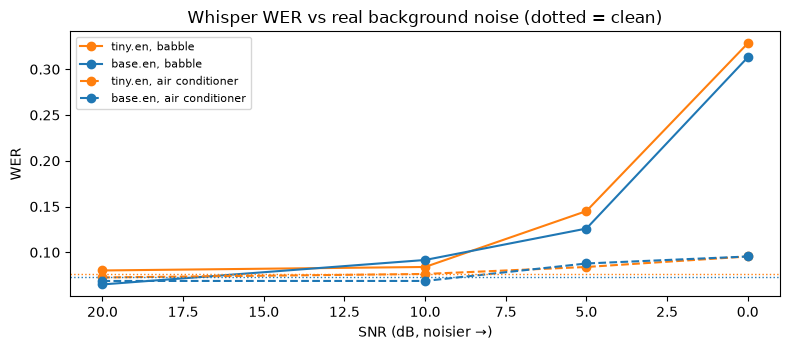

whisper-tiny.en: clean 7.6% → babble 0 dB 32.8% (4.3×) | air conditioner 0 dB 9.5% | phone line 7.6%
whisper-base.en: clean 7.3% → babble 0 dB 31.3% (4.3×) | air conditioner 0 dB 9.5% | phone line 7.6%
→ at 0 dB, babble noise hurts more on this run.


In [24]:
noises = {name: sf.read(DATA_DIR / f"noise_{file}.wav", dtype="float32")[0] for name, file in [("babble", "Babble_2"), ("air conditioner", "AirConditioner_1")]}
print({name: f"{len(x) / 16_000:.0f} s" for name, x in noises.items()})


def add_noise(clean, noise, snr_db, rng_):
    """Mix a random stretch of a real noise recording into `clean` at the requested SNR."""
    start_ = rng_.integers(0, len(noise) - len(clean))
    segment = noise[start_:start_ + len(clean)]
    scale = np.sqrt(np.mean(clean ** 2) / (np.mean(segment ** 2) * 10 ** (snr_db / 10)))
    return (clean + scale * segment).astype(np.float32)


mixed = add_noise(wave, noises["babble"], 5, np.random.default_rng(1))
achieved = 10 * np.log10(np.mean(wave ** 2) / np.mean((mixed - wave) ** 2))
print(f"requested 5 dB → achieved {achieved:.2f} dB")
assert abs(achieved - 5) < 1e-3

robust_set = test_set[:16]
robust_refs = [whisper_normalize(r["text"]) for r in robust_set]
conditions = {"clean": lambda x, g: x, "phone line (8 kHz μ-law)": lambda x, g: to_telephone(x)}
for noise_name in noises:
    for snr in (20, 10, 5, 0):
        conditions[f"{noise_name} {snr} dB"] = (lambda n, s: (lambda x, g: add_noise(x, noises[n], s, g)))(noise_name, snr)

def stable_seed(text):
    """Same text → same seed in every Python process (built-in hash() of a str is randomized per process)."""
    return int(hashlib.sha256(text.encode()).hexdigest()[:8], 16)


robust_rows = []
start = time.perf_counter()
for cond_name, degrade in conditions.items():
    audio = [degrade(r["wave"], np.random.default_rng(stable_seed(r["id"]))) for r in robust_set]
    for name, pipe in asr_pipes.items():
        hyps = [whisper_normalize(transcribe(pipe, a)[0]["text"]) for a in audio]
        robust_rows.append({"condition": cond_name, "model": name, "WER": jiwer.wer(robust_refs, hyps)})
robust = pd.DataFrame(robust_rows).pivot(index="condition", columns="model", values="WER").loc[list(conditions)]
print(f"{len(conditions)} conditions × {len(asr_pipes)} models × {len(robust_set)} utterances in {time.perf_counter() - start:.0f}s")
print(robust.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 3.6))
for noise_name, style in zip(noises, ["-", "--"]):
    for name, color in zip(asr_pipes, ["tab:orange", "tab:blue"]):
        ax.plot([20, 10, 5, 0], [robust.loc[f"{noise_name} {s} dB", name] for s in (20, 10, 5, 0)], style, marker="o", color=color,
                label=f"{name}, {noise_name}")
for name, color in zip(asr_pipes, ["tab:orange", "tab:blue"]):
    ax.axhline(robust.loc["clean", name], color=color, ls=":", lw=1)
ax.invert_xaxis()
ax.set(xlabel="SNR (dB, noisier →)", ylabel="WER", title="Whisper WER vs real background noise (dotted = clean)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for name in asr_pipes:
    print(f"whisper-{name}: clean {robust.loc['clean', name]:.1%} → babble 0 dB {robust.loc['babble 0 dB', name]:.1%} "
          f"({robust.loc['babble 0 dB', name] / max(robust.loc['clean', name], 1e-9):.1f}×) | air conditioner 0 dB {robust.loc['air conditioner 0 dB', name]:.1%} | "
          f"phone line {robust.loc['phone line (8 kHz μ-law)', name]:.1%}")
harder = "babble" if robust.loc["babble 0 dB"].mean() > robust.loc["air conditioner 0 dB"].mean() else "air conditioner"
print(f"→ at 0 dB, {harder} noise hurts more on this run.")

### ✍️ Your Turn

Speech power is `0.01` and a noise clip has power `0.04`. By what factor must you **scale the noise waveform** to mix at **10 dB SNR**? Store it in `noise_scale`.

In [25]:
noise_scale = None  # TODO: your code here
check("noise_scale", noise_scale, 0.15811388, atol=1e-6, hint="sqrt(P_speech / (P_noise * 10 ** (snr / 10)))")

⏳ noise_scale: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
noise_scale = math.sqrt(0.01 / (0.04 * 10 ** (10 / 10)))
check("noise_scale", noise_scale, 0.15811388)
```

Scaling amplitude by *a* scales power by *a²*: 0.04 × 0.158² = 0.001, exactly one tenth of the speech power (10 dB).
</details>

> 💡 **Interview angle:** "WER is 5% offline but users complain. Why?" — the offline set doesn't look like production: noise and far-field microphones, 8 kHz codecs, accents, domain words (product names, account numbers), different normalization. Build a small labelled set from real traffic, report WER per slice (noise, channel, accent, domain terms), and use noise augmentation, domain prompts or fine-tuning where a slice fails.

## 8. Text-to-Speech: Tokens, Acoustic Model, Vocoder 🟡

Modern neural TTS usually has three stages:

```
"Your card is frozen."
     │ 1. text front end: normalize ("$5" → "five dollars"), split into characters, phonemes or tokens
     ▼
 token ids ──► 2. ACOUSTIC MODEL (transformer) ──► mel spectrogram (what the audio should look like)
                    ▲ speaker embedding (which voice)
                                                       │ 3. VOCODER (e.g. HiFi-GAN) turns mel frames into a waveform
                                                       ▼
                                                 16 kHz audio
```

- The **acoustic model** decides *what* is said and the rhythm, pitch and speed (prosody). SpeechT5 generates mel frames **autoregressively**: one step at a time until a stop-probability passes a threshold.
- The **vocoder** fills in the fine waveform detail. Early neural vocoders (WaveNet) were autoregressive per *sample* and slow; GAN vocoders like **HiFi-GAN** run in one fast parallel pass.
- Newer systems replace the mel spectrogram with discrete **audio codec tokens** generated by a language model (Bark, many voice-cloning models), or train end to end (VITS/MMS).

**Choosing a TTS model means checking the licence of the weights *and* of the voices:**

| Model | Weights licence | Notes |
|---|---|---|
| `microsoft/speecht5_tts` + HiFi-GAN | **MIT** | **used here**: ~0.6 GB, needs a 512-d speaker x-vector |
| `suno/bark-small` | MIT | codec-token LM, ~1.5 GB, slow on CPU |
| `hexgrad/Kokoro-82M` | Apache-2.0 | small and natural, but needs the `kokoro` package and espeak-ng |
| `facebook/mms-tts-eng` | **CC BY-NC 4.0** | ❌ **non-commercial**: fine for research, not for a product, so not used |

**Our voice.** The speaker embedding is an **x-vector** computed from a recording of the CMU ARCTIC speaker **"slt"**. CMU ARCTIC was recorded in 2003 specifically for speech-synthesis research by experienced voice talent, and CMU releases it for any use with attribution. We use it *as a synthetic voice*, not to impersonate anyone.

acoustic model 144M params | vocoder 12.7M | speaker x-vector (1, 512) | reduction factor 2 | 80 mel bins


80 character tokens → 328 mel frames → 83,968 samples (5.25 s)
acoustic model 0.73s + vocoder 0.250s = 0.98s → RTF 0.19 on cpu
the acoustic model takes 74% of the time: autoregressive steps are the bottleneck


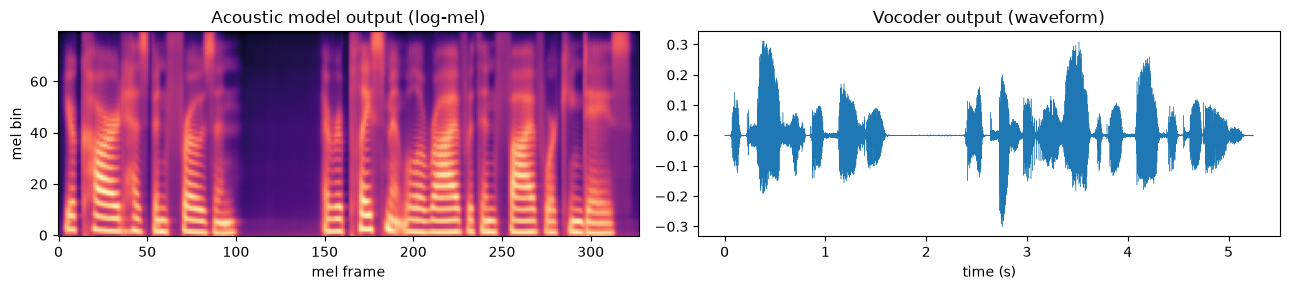

In [26]:
from transformers import SpeechT5ForTextToSpeech, SpeechT5HifiGan, SpeechT5Processor, SpeechT5Tokenizer

TTS_REPO, VOCODER_REPO = "microsoft/speecht5_tts", "microsoft/speecht5_hifigan"
tts_processor = SpeechT5Processor.from_pretrained(TTS_REPO, revision=REVISIONS[TTS_REPO])
tts_tokenizer_norm = SpeechT5Tokenizer.from_pretrained(TTS_REPO, revision=REVISIONS[TTS_REPO], normalize=True)   # spells out numbers
tts_model = SpeechT5ForTextToSpeech.from_pretrained(TTS_REPO, revision=REVISIONS[TTS_REPO]).to(TTS_DEVICE).eval()
vocoder = SpeechT5HifiGan.from_pretrained(VOCODER_REPO, revision=REVISIONS[VOCODER_REPO]).to(TTS_DEVICE).eval()
with zipfile.ZipFile(XVECTOR_ZIP) as archive:
    speaker_embedding = torch.tensor(np.load(io.BytesIO(archive.read("spkrec-xvect/cmu_us_slt_arctic-wav-arctic_a0508.npy")))).unsqueeze(0)
print(f"acoustic model {sum(p.numel() for p in tts_model.parameters()) / 1e6:.0f}M params | vocoder {sum(p.numel() for p in vocoder.parameters()) / 1e6:.1f}M | "
      f"speaker x-vector {tuple(speaker_embedding.shape)} | reduction factor {tts_model.config.reduction_factor} | {tts_model.config.num_mel_bins} mel bins")


def synthesize(text, tokenizer=None):
    """Text → 16 kHz waveform with SpeechT5 + HiFi-GAN. Returns (waveform, acoustic seconds, vocoder seconds, mel frames)."""
    tokenizer = tokenizer or tts_processor.tokenizer
    ids = tokenizer(text, return_tensors="pt")["input_ids"].to(TTS_DEVICE)
    with torch.inference_mode():
        start_ = time.perf_counter()
        mel = tts_model.generate(ids, speaker_embeddings=speaker_embedding.to(TTS_DEVICE))
        acoustic_s = time.perf_counter() - start_
        start_ = time.perf_counter()
        audio_ = vocoder(mel)
        vocoder_s = time.perf_counter() - start_
    return audio_.float().cpu().numpy(), acoustic_s, vocoder_s, mel


synthesize("Warm up.")                                              # first call allocates buffers
demo_text = "Your card has been frozen. A replacement will arrive within five working days."
demo_wave, acoustic_s, vocoder_s, demo_mel = synthesize(demo_text)
demo_s = len(demo_wave) / 16_000
print(f"{len(tts_processor.tokenizer(demo_text)['input_ids'])} character tokens → {demo_mel.shape[0]} mel frames → {len(demo_wave):,} samples ({demo_s:.2f} s)")
print(f"acoustic model {acoustic_s:.2f}s + vocoder {vocoder_s:.3f}s = {acoustic_s + vocoder_s:.2f}s → RTF {(acoustic_s + vocoder_s) / demo_s:.2f} on {TTS_DEVICE}")
print(f"the acoustic model takes {acoustic_s / (acoustic_s + vocoder_s):.0%} of the time: autoregressive steps are the bottleneck")
sf.write(OUTPUT_DIR / "tts_demo.wav", demo_wave, 16_000)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].imshow(demo_mel.T.numpy(), origin="lower", aspect="auto", cmap="magma")
axes[0].set(xlabel="mel frame", ylabel="mel bin", title="Acoustic model output (log-mel)")
axes[1].plot(np.arange(len(demo_wave)) / 16_000, demo_wave, lw=0.3)
axes[1].set(xlabel="time (s)", title="Vocoder output (waveform)")
plt.tight_layout()
plt.show()
display(Audio(demo_wave, rate=16_000))

**Sentence-level streaming.** A voice agent shouldn't wait to synthesize a whole paragraph. Split the reply into sentences and start playing the first one as soon as it's ready, while the next one is synthesized. Measured on a three-sentence reply:

In [27]:
reply = "I can help with that. Your new card will arrive within five working days. Is there anything else I can do for you today?"
whole_wave, a_s, v_s, _ = synthesize(reply)
whole_s = a_s + v_s
sentence_times = []
for sentence in re.split(r"(?<=[.!?])\s+", reply):
    _, a_s, v_s, _ = synthesize(sentence)
    sentence_times.append(a_s + v_s)
print(f"synthesize the whole reply first: first audio after {whole_s:.2f}s ({len(whole_wave) / 16_000:.1f}s of speech)")
print(f"sentence by sentence           : first audio after {sentence_times[0]:.2f}s (sentences take {[round(s, 2) for s in sentence_times]}s)")
print(f"→ streaming by sentence cuts time to first audio by {whole_s - sentence_times[0]:.2f}s ({1 - sentence_times[0] / whole_s:.0%})")

synthesize the whole reply first: first audio after 1.32s (7.3s of speech)
sentence by sentence           : first audio after 0.17s (sentences take [0.17, 0.39, 0.4]s)
→ streaming by sentence cuts time to first audio by 1.15s (87%)


**Round-trip intelligibility.** How do we know the speech is understandable without a human listener? **Synthesize → transcribe with ASR → compute WER against the input text.** It's a cheap automatic proxy for intelligibility, not naturalness (a robotic voice can score perfectly). We use 12 sentences from LibriSpeech transcripts plus 4 banking sentences containing numbers and abbreviations. The numeric ones are synthesized with the tokenizer's number normalizer switched on; Pitfall 4 shows what happens without it.

In [28]:
book_sentences = [r["text"].lower() for r in sorted(ls_rows, key=lambda r: len(r["text"])) if 6 <= len(r["text"].split()) <= 14][:12]
bank_sentences = ["Your balance is $1,250.", "Call us at 555 0199 before 5 PM.", "The ATM limit is 300 pounds per day.",
                  "Transfers over $10,000 need a second check."]
round_trip = []
for kind, sentences, tokenizer in [("book text", book_sentences, None), ("banking text with numbers", bank_sentences, tts_tokenizer_norm)]:
    for sentence in sentences:
        audio_, a_s, v_s, _ = synthesize(sentence, tokenizer)
        heard, _ = transcribe(asr_pipes["base.en"], audio_)
        spoken_text = tokenizer.decode(tokenizer(sentence)["input_ids"], skip_special_tokens=True) if tokenizer else sentence
        round_trip.append({"kind": kind, "text": sentence, "ASR heard": heard["text"].strip(),
                           "WER": jiwer.wer(whisper_normalize(spoken_text), whisper_normalize(heard["text"])),
                           "RTF": (a_s + v_s) / (len(audio_) / 16_000)})
round_trip = pd.DataFrame(round_trip)
print(round_trip.groupby("kind").agg(sentences=("WER", "size"), mean_WER=("WER", "mean"), median_RTF=("RTF", "median")).round(3).to_string())
print("\n" + round_trip[round_trip.WER > 0][["kind", "text", "ASR heard", "WER"]].round(2).to_string(index=False))

                           sentences  mean_WER  median_RTF
kind                                                      
banking text with numbers          4     0.179       0.139
book text                         12     0.012       0.131

                     kind                                 text                             ASR heard  WER
                book text        it's a stock company and rich         It's a stock company in rich. 0.14
banking text with numbers     Call us at 555 0199 before 5 PM.               Call us at 555-199-45M. 0.57
banking text with numbers The ATM limit is 300 pounds per day. The atom limit is 300 pounds per day. 0.14


Why do we compare the ASR output with the *spelled-out* text for the numeric sentences? Whisper writes "$1,250" while the TTS said "one thousand two hundred and fifty dollars"; Whisper's normalizer turns both back into the same digits, so the WER reflects what was actually heard.

**⚖️ Ethics: voice cloning and consent.** Modern models can clone a voice from seconds of audio. Treat voices as personal data:
- Use only voices with **explicit, documented consent** for synthesis (voice actors under contract, datasets recorded for TTS). Never clone public figures, colleagues or customers.
- **Disclose** that callers are talking to an AI. The EU AI Act has transparency obligations for AI systems that interact with people and for synthetic audio. In the US, the FCC ruled in 2024 that AI-generated voices in robocalls count as "artificial" voices under the TCPA.
- Prefer providers that **watermark** synthetic audio, keep audit logs of what was synthesized, and never use a voice as proof of identity (Section 11).

### ✍️ Your Turn

Write `split_sentences(text)` for streaming TTS: split after `.`, `!` or `?` **only when whitespace follows**, so a decimal like `10.50` is not split. Strip spaces.

In [29]:
def split_sentences(text):
    return None  # TODO: your code here


check("split_sentences", split_sentences("Hi there! Your balance is 10.50 dollars. Anything else?"),
      ["Hi there!", "Your balance is 10.50 dollars.", "Anything else?"],
      hint="re.split(r'(?<=[.!?])\\s+', text.strip()) — a look-behind keeps the punctuation.")

⏳ split_sentences: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def split_sentences(text):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s.strip()]


check("split_sentences", split_sentences("Hi there! Your balance is 10.50 dollars. Anything else?"),
      ["Hi there!", "Your balance is 10.50 dollars.", "Anything else?"])
```

Production splitters also handle abbreviations ("Dr.", "e.g.") and flush a long clause at a comma when no sentence end arrives quickly, so first audio isn't delayed by a very long sentence.
</details>

> 💡 **Interview angle:** "Walk me through a TTS pipeline." — text normalization (numbers, dates, abbreviations) → tokens or phonemes → acoustic model predicts mel frames with prosody and speaker identity → vocoder (HiFi-GAN) renders the waveform; or a codec-token LM plus a codec decoder. Latency lives in the autoregressive acoustic model; stream by sentence. Evaluate naturalness with MOS and intelligibility with round-trip WER.

## 9. Voice Activity Detection, Endpointing and Barge-In 🔴

A voice agent constantly answers three questions:

| Question | Name | What goes wrong |
|---|---|---|
| Is someone speaking right now? | **VAD** (voice activity detection) | noise triggers the bot; quiet speech is missed |
| Has the caller **finished** their turn? | **endpointing** / end-of-turn detection | too eager → **cuts people off**; too patient → **feels slow** |
| Did the caller start talking while the bot speaks? | **barge-in** (interruption) | bot talks over the caller, or stops for a cough |

**VAD options:**
- **Energy VAD**: speech is louder than background, so compare each frame's energy with the noise floor. Tiny and fast, but anything loud counts as "speech".
- **WebRTC VAD** (from Google's WebRTC project, `py-webrtcvad`): a classic Gaussian-mixture model on sub-band energies, 10/20/30 ms frames at 8–48 kHz, aggressiveness 0–3. Very cheap. Not installed here, so described only.
- **Silero VAD** (MIT): a small neural network (~2 MB ONNX) that outputs a speech probability every 32 ms at 16 kHz (512 samples) or 8 kHz (256 samples), carrying an internal state between chunks. We run its ONNX file directly with onnxruntime, following the protocol in the project's own ONNX wrapper: each chunk gets the previous chunk's last 64 samples (32 at 8 kHz) as context.

In [30]:
silero_session = ort.InferenceSession(str(DATA_DIR / "silero_vad.onnx"), providers=["CPUExecutionProvider"])
print("Silero inputs:", [(i.name, i.shape) for i in silero_session.get_inputs()], "| outputs:", [o.name for o in silero_session.get_outputs()])


def silero_speech_probs(x, sr=16_000):
    """Speech probability per chunk (32 ms) for a whole clip, streaming through the model chunk by chunk."""
    chunk, context_size = (512, 64) if sr == 16_000 else (256, 32)
    state = np.zeros((2, 1, 128), np.float32)
    context = np.zeros((1, context_size), np.float32)
    x = np.pad(np.asarray(x, np.float32), (0, (-len(x)) % chunk))
    probs = []
    for i in range(0, len(x), chunk):
        model_input = np.concatenate([context, x[None, i:i + chunk]], axis=1)
        out, state = silero_session.run(None, {"input": model_input, "state": state, "sr": np.array(sr, dtype=np.int64)})
        context = model_input[:, -context_size:]
        probs.append(float(out[0, 0]))
    return np.array(probs)


def energy_vad(x, sr=16_000, frame_s=0.032, margin_db=10.0, hangover=2):
    """Frame is speech if its energy is `margin_db` above the clip's noise floor (10th percentile); keep `hangover` frames after speech."""
    frame = int(frame_s * sr)
    n = len(x) // frame
    db = 10 * np.log10(np.mean(np.asarray(x[:n * frame]).reshape(n, frame) ** 2, axis=1) + 1e-10)
    raw = db > np.percentile(db, 10) + margin_db
    speech, left = np.zeros(n, bool), 0
    for i, is_loud in enumerate(raw):
        left = hangover if is_loud else max(left - 1, 0)
        speech[i] = is_loud or left > 0
    return speech


print(f"Silero on the example utterance: {len(silero_speech_probs(wave))} chunks of 32 ms, speech share {(silero_speech_probs(wave) > 0.5).mean():.2f}")

Silero inputs: [('input', [None, None]), ('state', [2, None, 128]), ('sr', [])] | outputs: ['output', 'stateN']
Silero on the example utterance: 346 chunks of 32 ms, speech share 0.91


**Experiment A: speech recall and false alarms.** For 16 clean test utterances, Whisper's word timestamps tell us where words are (reference speech). We measure the share of word time each VAD marks as speech (**recall**), clean and with noise at 5 dB. Then, on 8 s of each **noise-only** recording, we measure how much time is falsely marked as speech. Babble is left out of that part because it *is* speech.

In [31]:
def frame_reference(words, n_frames, frame_s=0.032):
    centres = (np.arange(n_frames) + 0.5) * frame_s
    ref_ = np.zeros(n_frames, bool)
    for start_s, end_s in words:
        ref_ |= (centres >= start_s) & (centres <= (end_s if end_s is not None else centres[-1]))
    return ref_


vad_rows = []
for r in robust_set:
    words = [c["timestamp"] for c in transcribe(asr_pipes["base.en"], r["wave"], return_timestamps="word")[0]["chunks"]]
    for cond_name, audio in [("clean", r["wave"]), ("air conditioner 5 dB", add_noise(r["wave"], noises["air conditioner"], 5, np.random.default_rng(stable_seed(r["id"])))),
                             ("babble 5 dB", add_noise(r["wave"], noises["babble"], 5, np.random.default_rng(stable_seed(r["id"]))))]:
        silero_mask = silero_speech_probs(audio) > 0.5
        energy_mask = energy_vad(audio)
        n = min(len(silero_mask), len(energy_mask))
        ref_ = frame_reference(words, n)
        for vad_name, mask in [("energy", energy_mask[:n]), ("Silero", silero_mask[:n])]:
            vad_rows.append({"VAD": vad_name, "condition": cond_name, "recall on word time": mask[ref_].mean()})
recall_table = pd.DataFrame(vad_rows).pivot_table(index="condition", columns="VAD", values="recall on word time")

false_alarm = {}
for file in ["AirConditioner_1", "VacuumCleaner_1", "CopyMachine_1"]:
    noise_only = sf.read(DATA_DIR / f"noise_{file}.wav", dtype="float32")[0][:8 * 16_000]
    false_alarm[file] = {"energy": energy_vad(noise_only).mean(), "Silero": (silero_speech_probs(noise_only) > 0.5).mean()}
print("share of word time detected as speech (higher is better):\n" + recall_table.round(3).to_string())
print("\nshare of NOISE-ONLY time flagged as speech (lower is better):\n" + pd.DataFrame(false_alarm).T.round(3).to_string())

share of word time detected as speech (higher is better):
VAD                   Silero  energy
condition                           
air conditioner 5 dB   0.872   0.182
babble 5 dB            0.892   0.374
clean                  0.877   0.800

share of NOISE-ONLY time flagged as speech (lower is better):
                  energy  Silero
AirConditioner_1   0.000     0.0
VacuumCleaner_1    0.008     0.0
CopyMachine_1      0.268     0.0


Read the two tables together. The energy VAD only knows "louder than the floor": at 5 dB SNR it misses most of the speech, and on bursty noise (the copy machine) it fires with nobody talking. Silero was trained to tell speech from noise, so it keeps finding speech at 5 dB and stays silent on the noise-only recordings. Both failure types hurt: false alarms send noise to ASR (Whisper then invents words, see Pitfall 3) and trigger false barge-ins; misses cut real speech out of the transcript.

**Experiment B: choosing the endpointing silence threshold.** The simplest endpointer declares "turn over" after **T seconds of silence**. Real callers pause mid-sentence ("I want to… um… change my address"). If a pause is longer than T, the bot jumps in: a **cut-off**. Every turn also waits T after the caller really finishes: **added latency**.

We measure the pauses in **150 real MInDS-14 recordings**: US-English crowd workers recorded bank requests, delivered as 8 kHz audio. Silero at 8 kHz finds the speech; the **longest internal pause** in each recording decides whether a given T would cut it off. These 150 recordings are only used to choose T. The Mini Project uses different ones.

MInDS-14 en-US: 563 recordings, 14 intents: ['abroad', 'address', 'app_error', 'atm_limit', 'balance', 'business_loan', 'card_issues', 'cash_deposit', 'direct_debit', 'freeze', 'high_value_payment', 'joint_account', 'latest_transactions', 'pay_bill']
endpoint-tuning recordings cover 14 of 14 intents


sample rate 8000 Hz | longest internal pause per recording: median 0.19s, p90 1.12s, max 5.63s
 silence threshold T (s)  callers cut off  added wait per turn (s)
                     0.2            0.493                      0.2
                     0.3            0.420                      0.3
                     0.4            0.367                      0.4
                     0.5            0.307                      0.5
                     0.6            0.247                      0.6
                     0.8            0.160                      0.8
                     1.0            0.120                      1.0
                     1.2            0.073                      1.2
                     1.5            0.060                      1.5
                     2.0            0.033                      2.0

rule: smallest T that cuts off ≤ 10% of callers → T_END = 1.2s (cuts off 7%; T = 0.3 s would cut off 42%)


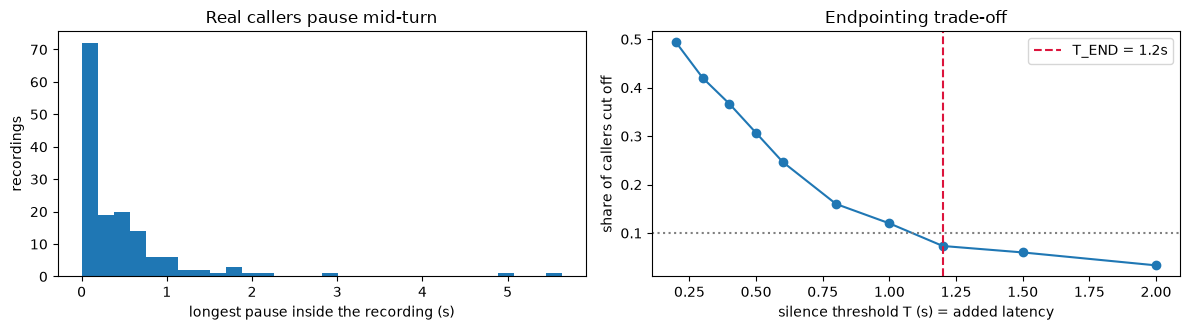

In [32]:
minds_table = pq.read_table(MINDS_PATH)
INTENTS = json.loads(minds_table.schema.metadata[b"huggingface"])["info"]["features"]["intent_class"]["names"]
minds_rows = minds_table.to_pylist()
print(f"MInDS-14 en-US: {len(minds_rows)} recordings, {len(INTENTS)} intents: {INTENTS}")

minds_order = np.random.default_rng(11).permutation(len(minds_rows))   # the file is sorted by intent, so sample at random
ENDPOINT_TUNING_IDX = sorted(minds_order[:150].tolist())
BARGE_IN_IDX = int(minds_order[150])
ENDPOINT_TUNING = [minds_rows[i] for i in ENDPOINT_TUNING_IDX]
print(f"endpoint-tuning recordings cover {len({r['intent_class'] for r in ENDPOINT_TUNING})} of {len(INTENTS)} intents")
longest_pause = []
for r in ENDPOINT_TUNING:
    x8, sr8 = decode_audio(r["audio"]["bytes"])
    speech = silero_speech_probs(x8, sr8) > 0.5
    idx = np.flatnonzero(speech)
    inner = speech[idx[0]:idx[-1] + 1] if len(idx) else np.array([], bool)
    runs, current = [0], 0
    for is_speech in inner:
        current = 0 if is_speech else current + 1
        runs.append(current)
    longest_pause.append(max(runs) * 0.032)
longest_pause = np.array(longest_pause)
print(f"sample rate {sr8} Hz | longest internal pause per recording: median {np.median(longest_pause):.2f}s, p90 {np.percentile(longest_pause, 90):.2f}s, max {longest_pause.max():.2f}s")

thresholds = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0])
cut_off = np.array([(longest_pause >= T).mean() for T in thresholds])
print(pd.DataFrame({"silence threshold T (s)": thresholds, "callers cut off": cut_off.round(3), "added wait per turn (s)": thresholds}).to_string(index=False))

MAX_CUT_OFF = 0.10                                                   # rule, stated before looking: cut off at most 1 caller in 10
T_END = float(thresholds[np.argmax(cut_off <= MAX_CUT_OFF)])
print(f"\nrule: smallest T that cuts off ≤ {MAX_CUT_OFF:.0%} of callers → T_END = {T_END:.1f}s "
      f"(cuts off {cut_off[thresholds == T_END][0]:.0%}; T = 0.3 s would cut off {cut_off[thresholds == 0.3][0]:.0%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(longest_pause, bins=30)
axes[0].set(xlabel="longest pause inside the recording (s)", ylabel="recordings", title="Real callers pause mid-turn")
axes[1].plot(thresholds, cut_off, marker="o")
axes[1].axvline(T_END, ls="--", color="crimson", label=f"T_END = {T_END:.1f}s")
axes[1].axhline(MAX_CUT_OFF, ls=":", color="gray")
axes[1].set(xlabel="silence threshold T (s) = added latency", ylabel="share of callers cut off", title="Endpointing trade-off")
axes[1].legend()
plt.tight_layout()
plt.show()

A fixed silence threshold forces a bad trade: fast *or* polite. Production systems add **semantic end-of-turn detection**: a small model looks at the transcript so far ("I want to change my…" is clearly unfinished) or at the audio's prosody, and shortens T when the turn sounds complete and lengthens it when it doesn't. LiveKit's open-weights turn-detector model and Pipecat's Smart Turn model are examples.

**Barge-in.** While the bot speaks, keep running VAD on the **microphone** stream. With **echo cancellation** removing the bot's own voice, speech on the mic means the caller is interrupting: stop playback within ~100–200 ms, cancel the pending LLM/TTS work, and **truncate the bot's last message in the conversation history to what the caller actually heard**. Requiring a few consecutive speech chunks avoids stopping for a click.

Below, the bot plays the TTS reply from earlier. A real MInDS-14 caller starts talking 1.5 s in, with a quiet air conditioner in the room. The mic signal here is the caller plus room noise, i.e. we assume echo cancellation already removed the bot's voice.

In [33]:
def detect_barge_in(mic, sr=16_000, min_chunks=3, use_silero=True):
    """Time (s) when `min_chunks` consecutive 32 ms chunks are speech, or None."""
    mask = silero_speech_probs(mic, sr) > 0.5 if use_silero else energy_vad(mic, sr, hangover=0)
    run = 0
    for i, is_speech in enumerate(mask):
        run = run + 1 if is_speech else 0
        if run == min_chunks:
            return (i + 1) * 0.032
    return None


caller16, _ = decode_audio(minds_rows[BARGE_IN_IDX]["audio"]["bytes"], 16_000)
caller_speech = silero_speech_probs(caller16) > 0.5
true_onset = 1.5 + np.argmax(caller_speech) * 0.032
mic = np.zeros(int(1.5 * 16_000) + len(caller16), np.float32)
mic[int(1.5 * 16_000):] = caller16
mic = add_noise(mic, noises["air conditioner"], 20, np.random.default_rng(SEED)) if np.any(mic) else mic
detected = detect_barge_in(mic)
played_share = min(detected / demo_s, 1.0)
demo_words = demo_text.split()
heard_text = " ".join(demo_words[:int(round(played_share * len(demo_words)))])
print(f"caller starts speaking at {true_onset:.2f}s | barge-in detected at {detected:.2f}s → reaction {1000 * (detected - true_onset):.0f} ms")
print(f"bot had played {played_share:.0%} of its {demo_s:.1f}s reply → keep in history: {heard_text!r}… (not the full sentence)")

copier = sf.read(DATA_DIR / "noise_CopyMachine_1.wav", dtype="float32")[0][:8 * 16_000]
print(f"\nfalse barge-in on 8 s of copy-machine noise: energy VAD → {detect_barge_in(copier, use_silero=False)} s | "
      f"Silero → {detect_barge_in(copier)} (None = never triggered)")

caller starts speaking at 2.75s | barge-in detected at 2.85s → reaction 100 ms
bot had played 54% of its 5.2s reply → keep in history: 'Your card has been frozen. A replacement'… (not the full sentence)

false barge-in on 8 s of copy-machine noise: energy VAD → 2.688 s | Silero → None (None = never triggered)


### ✍️ Your Turn

Write `endpoint_index(speech_mask, min_silence_frames)`: return the index of the frame at which the turn **ends**, i.e. the frame where the silence run *after speech has started* first reaches `min_silence_frames`. Return `None` if that never happens.

In [34]:
def endpoint_index(speech_mask, min_silence_frames):
    return None  # TODO: your code here


mask_example = [0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1]
endpoints = [endpoint_index(mask_example, 2), endpoint_index(mask_example, 3), endpoint_index(mask_example, 4)]
check("endpoint_index", None if all(e is None for e in endpoints) else endpoints, [8, 9, None],
      hint="Track seen_speech and a silence counter; reset the counter on speech; return i when it reaches min_silence_frames.")

⏳ endpoint_index: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def endpoint_index(speech_mask, min_silence_frames):
    seen_speech, silence = False, 0
    for i, is_speech in enumerate(speech_mask):
        if is_speech:
            seen_speech, silence = True, 0
        elif seen_speech:
            silence += 1
            if silence == min_silence_frames:
                return i
    return None


mask_example = [0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1]
check("endpoint_index", [endpoint_index(mask_example, 2), endpoint_index(mask_example, 3), endpoint_index(mask_example, 4)], [8, 9, None])
```

With 2 frames the one-frame pause at index 4 is tolerated. With 4 frames the caller resumes at index 10 before the threshold is reached, so no endpoint yet.
</details>

> 💡 **Interview angle:** "Users say the bot interrupts them, others say it's slow. What do you do?" — both are endpointing. Measure the pause distribution and cut-off rate vs silence threshold on real calls (like Experiment B), use a neural VAD rather than energy, add semantic end-of-turn detection so T adapts to whether the sentence is complete, tune per channel/language, and make barge-in robust (echo cancellation, min speech duration, truncate history to what was heard).

## 10. Voice Agents End to End: STT → LLM with a Tool → TTS 🔴

Time to connect everything. Our agent answers bank callers:

```
caller audio (8 kHz) ─► wait T_END of silence ─► Whisper ─► LLM call 1: pick a tool ─► lookup_banking_faq(intent) ─► approved answer
                                                                                                       │
                                   caller hears ◄─ TTS sentence 1 ◄─ LLM call 2 (streamed): phrase the answer for speech
```

**The latency budget** is the time from the caller's last word to the first sound they hear (**time to first audio, TTFA**):

| Stage | What we measure |
|---|---|
| endpointing | the silence we wait before deciding the turn ended (T_END from Section 9, plus one 32 ms VAD chunk) |
| ASR | Whisper on the whole utterance |
| LLM call 1 (tool choice) | full streamed call until the tool call is complete |
| LLM call 2 → first sentence | time until the first complete sentence has streamed in |
| TTS first sentence | synthesis of that sentence |

The tool returns **approved answers**: short texts written for this notebook to stand in for a bank's reviewed FAQ. They're illustrative, not real bank policy. Keeping facts in a tool rather than in the model's head is the same pattern as in the Agentic AI module.

In [35]:
FAQ_ANSWERS = {
    "abroad": "You can use your card abroad without telling us first. Fees for foreign payments are shown in the app.",
    "address": "You can change your address in the app under Profile. We may ask you to confirm it with a document.",
    "app_error": "Sorry the app isn't working. Please update it to the latest version and restart your phone.",
    "atm_limit": "Your daily cash withdrawal limit is shown in the app under Card settings. You can ask to raise it there.",
    "balance": "Your balance is on the home screen of the app. You can also check it at any cash machine.",
    "business_loan": "Business loan applications are handled by our business team. I can transfer you to them now.",
    "card_issues": "If your card isn't working, you can freeze it and order a replacement in the app.",
    "cash_deposit": "You can deposit cash at any branch counter. Some cash machines also accept deposits.",
    "direct_debit": "You can set up or cancel a direct debit in the app under Payments.",
    "freeze": "You can freeze your card instantly in the app under Card settings. Unfreeze it the same way if you find it.",
    "high_value_payment": "Large payments may need an extra security check. You'll get a notification in the app to approve it.",
    "joint_account": "You can open a joint account in the app if both of you are customers. Each person confirms their identity.",
    "latest_transactions": "Your latest transactions are listed in the app under Activity. Tap one to see the details.",
    "pay_bill": "You can pay a bill in the app under Payments using the reference on the bill.",
}
assert set(FAQ_ANSWERS) == set(INTENTS)
TOOLS = [{"type": "function", "function": {
    "name": "lookup_banking_faq",
    "description": "Get the bank's approved answer for the caller's request. Choose the single best matching intent.",
    "parameters": {"type": "object", "properties": {"intent": {"type": "string", "enum": INTENTS}}, "required": ["intent"]}}}]
ROUTER_SYSTEM = ("You are the voice assistant on a bank's phone line. The caller's words come from speech recognition and may contain "
                 "mistakes. Always call lookup_banking_faq with the single best intent.")
SPEAKER_SYSTEM = ("You are the voice assistant on a bank's phone line. Using the tool result, answer the caller in at most two short "
                  "spoken sentences. Plain words only: no lists, no markdown, no emojis.")


def route_intent(transcript):
    """LLM call 1: returns (intent or None, call record)."""
    messages = [{"role": "system", "content": ROUTER_SYSTEM}, {"role": "user", "content": transcript}]
    record = chat(messages, tools=TOOLS, tool_choice="required", max_tokens=512)
    intent = None
    if record["tool_calls"]:
        try:
            intent = json.loads(record["tool_calls"][0]["arguments"]).get("intent")
        except json.JSONDecodeError:
            intent = None
    return (intent if intent in FAQ_ANSWERS else None), record, messages


def voice_turn(row, asr_name="base.en"):
    """One full turn on a MInDS-14 recording. Returns a dict of texts and stage timings (seconds)."""
    audio16, _ = decode_audio(row["audio"]["bytes"], 16_000)
    heard, asr_s = transcribe(asr_pipes[asr_name], audio16)
    intent, routing, messages = route_intent(heard["text"].strip())
    call = routing["tool_calls"][0] if routing["tool_calls"] else {"id": None, "name": "lookup_banking_faq", "arguments": "{}"}
    tool_result = {"intent": intent, "approved_answer": FAQ_ANSWERS.get(intent, "I can transfer you to a colleague who can help.")}
    messages = [{"role": "system", "content": SPEAKER_SYSTEM}] + messages[1:] + [
        {"role": "assistant", "content": None, "tool_calls": [{"id": call["id"] or "call_0", "type": "function",
                                                               "function": {"name": call["name"], "arguments": call["arguments"]}}]},
        {"role": "tool", "tool_call_id": call["id"] or "call_0", "content": json.dumps(tool_result)}]
    reply = chat(messages, max_tokens=512)
    sentences = reply["sentences"] or [(reply["latency_s"], reply["text"].strip())]
    first_sentence_s, first_sentence = sentences[0]
    _, a_s, v_s, _ = synthesize(first_sentence)
    tts_all_s = sum(sum(synthesize(s)[1:3]) for _, s in sentences)            # synthesize everything too, for the no-streaming comparison
    _, a2, v2, _ = synthesize(re.split(r"(?<=[.!?])\s+", tool_result["approved_answer"])[0])   # lever: speak the approved text directly
    return {"heard": heard["text"].strip(), "true intent": INTENTS[row["intent_class"]], "routed intent": intent, "reply": reply["text"].strip(),
            "endpointing": T_END + 0.032, "ASR": asr_s, "LLM tool choice": routing["latency_s"], "LLM first sentence": first_sentence_s,
            "TTS first sentence": a_s + v_s, "LLM full reply": reply["latency_s"], "TTS whole reply": tts_all_s,
            "TTS approved answer (1st sentence)": a2 + v2, "reply prompt tokens": reply["prompt_tokens"],
            "reply cached prompt tokens": reply["cached_prompt_tokens"], "replayed": routing["replayed"] and reply["replayed"]}


demo_pool = [i for i in range(len(minds_rows)) if i not in set(ENDPOINT_TUNING_IDX) and i != BARGE_IN_IDX]
AGENT_DEMO_IDX = sorted(np.random.default_rng(3).choice(demo_pool, 6, replace=False).tolist())
turns = pd.DataFrame([voice_turn(minds_rows[i]) for i in AGENT_DEMO_IDX])
STAGES = ["endpointing", "ASR", "LLM tool choice", "LLM first sentence", "TTS first sentence"]
turns["time to first audio"] = turns[STAGES].sum(axis=1)
print(turns[["true intent", "routed intent", "heard", "reply"]].to_string())

     true intent  routed intent                                                                                                                                                                                   heard                                                                                                       reply
0  joint_account  joint_account                                                                                                                I would like to set up a joint account. How would I go about doing that?  You can open a joint account in the app if both of you are customers. Each person confirms their identity.
1       pay_bill       pay_bill                                                                                                                                                                     I need to pay bill.                         Sure, you can pay a bill in the app under Payments using the reference on the bill.
2       pay_bill       pay_b

`voice_turn` also synthesizes the **approved answer's first sentence** directly. We use that timing below for the "skip the second LLM call" lever.

**The measured latency budget:**

                     p50 (s)  p95 (s)  share of p50 TTFA
endpointing            1.232    1.232              0.219
ASR                    0.307    0.588              0.055
LLM tool choice        1.592    2.294              0.283
LLM first sentence     1.688    2.587              0.301
TTS first sentence     0.629    0.689              0.112
time to first audio    5.614    6.842                NaN
(6 turns: p95 is interpolated between the two slowest turns; LLM calls replayed from the cache: 6 of 6 turns)


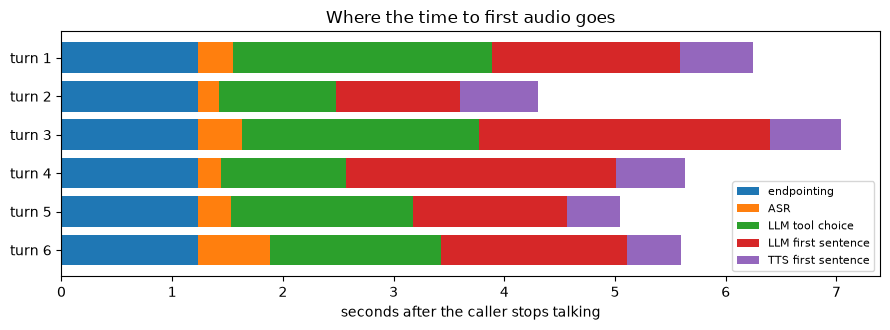

→ the largest stage at the median is 'LLM first sentence' (1.69s of 5.61s).
timing sanity: ASR real-time factor on these turns stayed ≤ 0.07, so the latencies reflect the models, not a stalled machine.


In [36]:
budget = pd.DataFrame({"p50 (s)": turns[STAGES + ["time to first audio"]].quantile(0.5), "p95 (s)": turns[STAGES + ["time to first audio"]].quantile(0.95)})
budget["share of p50 TTFA"] = (budget["p50 (s)"] / budget.loc["time to first audio", "p50 (s)"]).where(budget.index != "time to first audio")
print(budget.round(3).to_string())
print(f"(6 turns: p95 is interpolated between the two slowest turns; LLM calls replayed from the cache: {int(turns.replayed.sum())} of {len(turns)} turns)")

fig, ax = plt.subplots(figsize=(9, 3.4))
left = np.zeros(len(turns))
for stage in STAGES:
    ax.barh([f"turn {i + 1}" for i in range(len(turns))], turns[stage], left=left, label=stage)
    left += turns[stage].to_numpy()
ax.set(xlabel="seconds after the caller stops talking", title="Where the time to first audio goes")
ax.legend(fontsize=8, loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
biggest = budget["p50 (s)"].drop("time to first audio").idxmax()
print(f"→ the largest stage at the median is '{biggest}' ({budget.loc[biggest, 'p50 (s)']:.2f}s of {budget.loc['time to first audio', 'p50 (s)']:.2f}s).")
demo_audio_s = np.array([len(decode_audio(minds_rows[i]["audio"]["bytes"])[0]) / 8_000 for i in AGENT_DEMO_IDX])
asr_rtf_turns = turns["ASR"].to_numpy() / demo_audio_s
if asr_rtf_turns.max() > 1.0:
    print(f"⚠️ ASR took longer than the audio itself on {int((asr_rtf_turns > 1).sum())} of {len(turns)} turns (max RTF {asr_rtf_turns.max():.1f}). "
          "That means other programs were competing for memory or the GPU during this run: treat these latencies as upper bounds and re-run on an idle machine.")
else:
    print(f"timing sanity: ASR real-time factor on these turns stayed ≤ {asr_rtf_turns.max():.2f}, so the latencies reflect the models, not a stalled machine.")

**How to cut it**, with each lever computed from the turns we just ran (plus Sections 6 and 9):

In [37]:
tiny_asr = np.array([transcribe(asr_pipes["tiny.en"], decode_audio(minds_rows[i]["audio"]["bytes"], 16_000)[0])[1] for i in AGENT_DEMO_IDX])
p50 = lambda s: float(np.median(s))
no_streaming = turns["endpointing"] + turns["ASR"] + turns["LLM tool choice"] + turns["LLM full reply"] + turns["TTS whole reply"]
speak_approved = turns["endpointing"] + turns["ASR"] + turns["LLM tool choice"] + turns["TTS approved answer (1st sentence)"]
T_FAST = 0.3
reply_cache_share = turns["reply cached prompt tokens"].sum() / max(turns["reply prompt tokens"].sum(), 1)
levers = pd.DataFrame([
    {"lever": "baseline (as built)", "p50 TTFA (s)": p50(turns["time to first audio"]), "trade-off": "—"},
    {"lever": "no streaming: wait for the full reply, synthesize it all", "p50 TTFA (s)": p50(no_streaming), "trade-off": "simpler code, but first audio waits for the whole reply and all of its synthesis"},
    {"lever": "smaller ASR (tiny.en instead of base.en)", "p50 TTFA (s)": p50(turns["time to first audio"] - turns["ASR"] + tiny_asr),
     "trade-off": f"WER on clean audio {robust.loc['clean', 'tiny.en']:.1%} vs {robust.loc['clean', 'base.en']:.1%} (Section 7)"},
    {"lever": f"shorter silence threshold ({T_FAST}s instead of {T_END}s)", "p50 TTFA (s)": p50(turns["time to first audio"] - T_END + T_FAST),
     "trade-off": f"cuts off {cut_off[thresholds == T_FAST][0]:.0%} of callers instead of {cut_off[thresholds == T_END][0]:.0%} (Section 9)"},
    {"lever": "speak the approved answer directly (skip LLM call 2)", "p50 TTFA (s)": p50(speak_approved), "trade-off": "less natural phrasing, but no invented details"},
])
print(levers.round(2).to_string(index=False))
print(f"\nprompt caching: the server reused {reply_cache_share:.0%} of reply-call prompt tokens from its KV cache (shared system prompt and history prefix)")
filler_wave, fa, fv, _ = synthesize("One moment, let me check that for you.")
print(f"filler audio: synthesized once in {fa + fv:.2f}s and cached → can start playing {p50(turns['endpointing'] + turns['ASR']):.2f}s after the caller stops "
      f"(it only masks the wait; the answer still arrives at the times above)")

                                                   lever  p50 TTFA (s)                                                                        trade-off
                                     baseline (as built)          5.61                                                                                —
no streaming: wait for the full reply, synthesize it all          6.03 simpler code, but first audio waits for the whole reply and all of its synthesis
                smaller ASR (tiny.en instead of base.en)          5.37                                      WER on clean audio 7.6% vs 7.3% (Section 7)
        shorter silence threshold (0.3s instead of 1.2s)          4.71                                cuts off 42% of callers instead of 7% (Section 9)
    speak the approved answer directly (skip LLM call 2)          3.75                                   less natural phrasing, but no invented details

prompt caching: the server reused 53% of reply-call prompt tokens from its KV cache (sh

filler audio: synthesized once in 0.27s and cached → can start playing 1.54s after the caller stops (it only masks the wait; the answer still arrives at the times above)


Other levers we can't measure on this laptop: **streaming ASR** with partial results (start the LLM before the final transcript), running the LLM **speculatively** during the endpointing wait and discarding it if the caller keeps talking, **smaller or distilled LLMs** for routing, **co-locating** ASR/LLM/TTS near the telephony edge to cut network hops, and **streaming TTS** that emits audio chunks before the sentence is finished.

**Cascaded vs speech-to-speech, and the frameworks** (described from their documentation; none are installed or called here):

| | What it is | Why teams pick it |
|---|---|---|
| **Cascaded** STT → LLM → TTS (this notebook) | three swappable components with text in between | inspect and log the transcript, use any LLM and tools, per-stage evaluation, cheaper; but more latency and paralinguistic cues (tone, laughter, hesitation) are lost in the text step |
| **OpenAI Realtime API** (`gpt-realtime`) | a speech-to-speech model over WebRTC, WebSocket or SIP, with built-in voice activity/turn detection, tool calling and interruption handling | lowest integration effort, natural prosody, handles barge-in; less control, harder to audit each step |
| **Gemini Live API** | a stateful WebSocket session streaming audio/video in and native audio out, with VAD, barge-in and tools | same idea on Google's models, multimodal (camera or screen) input |
| **Moshi** (Kyutai, open weights) | a **full-duplex** speech-text model: it listens and speaks at the same time in parallel audio streams, with ~200 ms practical latency reported | research-grade open model for truly overlapping conversation |
| **LiveKit Agents** | open-source framework on LiveKit's WebRTC infrastructure: STT/LLM/TTS or realtime-model plugins, turn detection (including an open-weights end-of-turn model), telephony | production plumbing for rooms, phones and interruptions |
| **Pipecat** (Daily, open source) | a Python framework that builds voice agents as **pipelines of frame processors** with transports for WebRTC, WebSockets and telephony, plus a Smart Turn model | fine-grained control of every stage, many provider integrations |

Hosted cells run only when their API key is set:

In [38]:
if os.environ.get("OPENAI_API_KEY"):
    hosted = OpenAI()                                                   # uses OPENAI_API_KEY and the default OpenAI URL
    clip, _ = decode_audio(minds_rows[AGENT_DEMO_IDX[0]]["audio"]["bytes"], 16_000)
    wav_file = io.BytesIO()
    sf.write(wav_file, clip, 16_000, format="WAV")
    wav_file.seek(0)
    wav_file.name = "caller.wav"
    start = time.perf_counter()
    hosted_text = hosted.audio.transcriptions.create(model="gpt-4o-mini-transcribe", file=wav_file).text
    stt_s = time.perf_counter() - start
    start = time.perf_counter()
    hosted_speech = hosted.audio.speech.create(model="gpt-4o-mini-tts", voice="alloy", input=FAQ_ANSWERS["freeze"])
    tts_s = time.perf_counter() - start
    print(f"hosted STT {stt_s:.2f}s → {hosted_text!r} | hosted TTS {tts_s:.2f}s, {len(hosted_speech.content):,} bytes of audio")
else:
    print("⏭️ Skipped: set OPENAI_API_KEY to time hosted speech-to-text and text-to-speech on one clip. "
          "A Realtime API session needs a WebRTC or WebSocket client (see the OpenAI Realtime docs in Resources).")
if not os.environ.get("GEMINI_API_KEY"):
    print("⏭️ Skipped: set GEMINI_API_KEY (and install google-genai) to try the Gemini Live API — this notebook has no Live client.")

⏭️ Skipped: set OPENAI_API_KEY to time hosted speech-to-text and text-to-speech on one clip. A Realtime API session needs a WebRTC or WebSocket client (see the OpenAI Realtime docs in Resources).
⏭️ Skipped: set GEMINI_API_KEY (and install google-genai) to try the Gemini Live API — this notebook has no Live client.


### ✍️ Your Turn

A turn's stages took: endpointing 0.53 s, ASR 0.21 s, LLM tool choice 0.95 s, LLM first sentence 0.80 s, TTS first sentence 0.62 s. Compute `[time_to_first_audio, largest_stage_share]`: the total, and the largest stage's share of it.

In [39]:
stage_times = {"endpointing": 0.53, "ASR": 0.21, "LLM tool choice": 0.95, "LLM first sentence": 0.80, "TTS first sentence": 0.62}
budget_answer = None  # TODO: your code here
check("budget_answer", budget_answer, [3.11, 0.95 / 3.11], atol=1e-6, hint="total = sum(stage_times.values()); max(stage_times.values()) / total")

⏳ budget_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
stage_times = {"endpointing": 0.53, "ASR": 0.21, "LLM tool choice": 0.95, "LLM first sentence": 0.80, "TTS first sentence": 0.62}
total = sum(stage_times.values())
budget_answer = [total, max(stage_times.values()) / total]
check("budget_answer", budget_answer, [3.11, 0.95 / 3.11])
```

The two LLM stages together are over half of the budget, which is why voice agents route with small fast models and stream the reply.
</details>

> 💡 **Interview angle:** "How would you reduce voice-agent latency?" — measure per stage first (p50 *and* p95). Then: smarter endpointing (semantic end-of-turn instead of a long fixed silence), streaming ASR, a small fast LLM for routing and prompt-cache-friendly prompts, stream LLM tokens into sentence-level TTS, skip generation where an approved answer exists, filler audio during slow tools, and co-locate services. Or move to a speech-to-speech model, trading control and auditability.

## 11. Evaluating and Operating Voice Agents 🟡

| Layer | Metric | How |
|---|---|---|
| ASR | **WER / CER**, *by slice* (channel, noise, accent, domain terms like account numbers) | human-transcribed sample of real calls, fixed normalizer |
| Turn-taking | **cut-off rate**, false barge-ins, missed barge-ins, response delay | VAD/endpoint logs + labelled call sample |
| Latency | **time to first audio p50/p95**, per-stage p95 | spans per stage, as in Section 10 and the Production Agents notebook |
| Understanding | intent/tool-routing accuracy, argument accuracy | labelled transcripts (Mini Project) |
| Task | **task success / containment rate** (solved without a human), escalation rate, repeat-call rate | end-state checks, CRM outcomes, simulated callers |
| Speech output | **MOS** (mean opinion score: listeners rate 1–5, ITU-T P.800), intelligibility | human panels; automatic MOS predictors such as **UTMOS** and **DNSMOS**; round-trip WER (Section 8) |
| Safety | PII leaks, policy violations, spoofing attempts | redaction audits, red-team calls |

A voice agent can have great WER and still fail callers (cut-offs, wrong tool, slow). Report a **scorecard**, not one number. Here's one assembled from what this notebook measured:

In [40]:
scorecard = pd.DataFrame([
    {"area": "ASR", "metric": "WER, clean read speech (base.en)", "value": f"{robust.loc['clean', 'base.en']:.1%}"},
    {"area": "ASR", "metric": "WER, phone-line audio (base.en)", "value": f"{robust.loc['phone line (8 kHz μ-law)', 'base.en']:.1%}"},
    {"area": "ASR", "metric": "WER, babble noise 5 dB (base.en)", "value": f"{robust.loc['babble 5 dB', 'base.en']:.1%}"},
    {"area": "turn-taking", "metric": f"callers cut off at T_END = {T_END}s", "value": f"{cut_off[thresholds == T_END][0]:.0%}"},
    {"area": "latency", "metric": "time to first audio p50 / p95 (6 turns)", "value": f"{turns['time to first audio'].quantile(0.5):.2f}s / {turns['time to first audio'].quantile(0.95):.2f}s"},
    {"area": "understanding", "metric": "intent routed correctly (6 demo turns)", "value": f"{(turns['routed intent'] == turns['true intent']).mean():.0%}"},
    {"area": "speech output", "metric": "round-trip WER, book sentences", "value": f"{round_trip[round_trip.kind == 'book text'].WER.mean():.1%}"},
])
print(scorecard.to_string(index=False))

         area                                  metric         value
          ASR        WER, clean read speech (base.en)          7.3%
          ASR         WER, phone-line audio (base.en)          7.6%
          ASR        WER, babble noise 5 dB (base.en)         12.6%
  turn-taking         callers cut off at T_END = 1.2s            7%
      latency time to first audio p50 / p95 (6 turns) 5.61s / 6.84s
understanding  intent routed correctly (6 demo turns)          100%
speech output          round-trip WER, book sentences          1.2%


**Logging and PII.** Transcripts are *personal data*: callers read out card numbers, addresses, dates of birth and names, and the audio itself is biometric. Redact **before** logs leave the service, keep raw audio only where needed with short retention, restrict access, and honour deletion requests. Numbers arrive as digits *or as words* ("four five six seven"), so redaction must handle both. A simple rule-based redactor on all 563 MInDS-14 transcripts:

In [41]:
NUMBER_WORDS = r"(?:zero|oh|one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve|twenty|thirty|forty|fifty|hundred|thousand|double|triple)"
REDACTIONS = [                                                                           # (rule, pattern, replacement); order matters
    ("email", re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.]+\b"), "[EMAIL]"),
    ("money amount", re.compile(r"[$£€]\s?\d[\d,]*(?:\.\d+)?"), "[AMOUNT]"),
    ("date / ordinal", re.compile(r"\b\d{1,2}(?:st|nd|rd|th)\b", re.I), "[DATE]"),
    ("digits", re.compile(r"\b\d[\d\s-]*\d\b|\b\d\b"), "[NUMBER]"),
    ("spoken digit run", re.compile(rf"\b{NUMBER_WORDS}(?:[\s-]+{NUMBER_WORDS}){{2,}}\b", re.I), "[NUMBER]"),
    ("self-introduced name", re.compile(r"\b(?:this is|my name is)\s+([A-Z][a-z]+)\b"), None),
]


def redact(text, counts=None):
    for rule, pattern, token in REDACTIONS:
        if token is None:                                                              # keep the cue phrase, replace only the name
            new_text = pattern.sub(lambda m: m.group(0).replace(m.group(1), "[NAME]"), text)
        else:
            new_text = pattern.sub(token, text)
        if counts is not None and new_text != text:
            counts[rule] += 1
        text = new_text
    return text


rule_hits = Counter()
redacted = [(r["transcription"], redact(r["transcription"], rule_hits)) for r in minds_rows]
changed = [(a, b) for a, b in redacted if a != b]
print(f"{len(changed)} of {len(redacted)} transcripts had something redacted | transcripts hit per rule: {dict(rule_hits)}")
for before, after in changed[:5]:
    start = max(0, after.find("[") - 50)                                               # show the text around the first redaction
    print(f"  before: …{before[start:start + 110]}\n  after : …{after[start:start + 110]}")
print("⚠️ Regex rules both over- and under-redact (a capitalised word is not always a name; addresses and account details said in words slip through). "
      "Production systems add NER-based PII detection, redact the matching audio segments too, and audit samples by hand.")

10 of 563 transcripts had something redacted | transcripts hit per rule: {'digits': 7, 'money amount': 3, 'date / ordinal': 1, 'self-introduced name': 1}
  before: …I have to pay bills at 2
  after : …I have to pay bills at [NUMBER]
  before: … can take maybe I can't take all of it is it like 400 or 500 a day thank you
  after : … can take maybe I can't take all of it is it like [NUMBER] or [NUMBER] a day thank you
  before: …to go to the ATM and are usually withdrawal about $200 I wanted can I up that and make it $300 when I'm at the
  after : …to go to the ATM and are usually withdrawal about [AMOUNT] I wanted can I up that and make it [AMOUNT] when I'
  before: …I'm planning to go to the UK on the 16th and come back on the 24th I was wondering if my car
  after : …I'm planning to go to the UK on the [DATE] and come back on the [DATE] I was wondering if my car
  before: …g my card in Nigeria I'll be going there in about 2 weeks and I just wanted to call to see if I needed anythin
  a

**Deepfakes and spoofing.** Cloned voices defeat "voice as a password": modern TTS can imitate a person from a few seconds of audio. For a voice agent:
- **Never authenticate by voice alone.** Use knowledge factors, one-time codes to a registered device, or call-back verification. Treat voice biometrics as one weak signal with **anti-spoofing** detection. The ASVspoof challenges benchmark such countermeasures.
- **Assume inbound audio can be synthetic.** Rate-limit high-risk actions (payments, address changes) and require step-up verification.
- **Don't become the deepfake:** disclose the AI, use only consented voices, watermark outputs where possible, and log synthesized content.

> 💡 **Interview angle:** "How do you evaluate a voice agent?" — a scorecard across layers: WER by slice on real calls, turn-taking errors (cut-offs, false/missed barge-ins), per-stage and end-to-end latency percentiles, routing and argument accuracy, task success/containment and escalations, speech quality (MOS or UTMOS-style proxies, round-trip intelligibility), plus safety (PII redaction audits, spoofing tests). Offline on a labelled set before release, online with sampled human review after.

## 🔧 Build It From Scratch

Two classics, each checked against the library.

### (a) Whisper's log-mel front end in NumPy

Steps, matching `WhisperFeatureExtractor`:
1. **Pad or trim** the waveform to 30 s (480,000 samples).
2. **Reflect-pad** 200 samples on each side (`center=True`), cut 400-sample frames every 160 samples, multiply by a *periodic* Hann window.
3. **Power spectrum** |FFT|² → 201 bins per frame.
4. **Slaney mel filterbank**: 80 triangles evenly spaced on the Slaney mel scale from 0 to 8,000 Hz, each scaled by 2/(width in Hz) so every filter has the same area.
5. **log10** (floor 1e-10), **drop the last frame** (3,001 → 3,000), clamp to *max − 8* (an 80 dB dynamic range), then **(x + 4) / 4** to land roughly in [−1, 1].

In [42]:
def hz_to_mel_slaney(f):
    f = np.asarray(f, dtype=np.float64)
    f_sp, min_log_hz = 200.0 / 3, 1000.0
    logstep = np.log(6.4) / 27.0
    return np.where(f >= min_log_hz, min_log_hz / f_sp + np.log(np.maximum(f, 1e-10) / min_log_hz) / logstep, f / f_sp)


def mel_to_hz_slaney(m):
    m = np.asarray(m, dtype=np.float64)
    f_sp, min_log_hz = 200.0 / 3, 1000.0
    min_log_mel, logstep = min_log_hz / f_sp, np.log(6.4) / 27.0
    return np.where(m >= min_log_mel, min_log_hz * np.exp(logstep * (m - min_log_mel)), f_sp * m)


def slaney_filterbank(sr=16_000, n_fft=400, n_mels=80, f_max=8_000.0):
    fft_freqs = np.linspace(0, sr / 2, n_fft // 2 + 1)
    edges = mel_to_hz_slaney(np.linspace(hz_to_mel_slaney(0.0), hz_to_mel_slaney(f_max), n_mels + 2))
    bank = np.zeros((n_mels, len(fft_freqs)))
    for m in range(n_mels):
        low, centre, high = edges[m], edges[m + 1], edges[m + 2]
        rising, falling = (fft_freqs - low) / (centre - low), (high - fft_freqs) / (high - centre)
        bank[m] = np.maximum(0, np.minimum(rising, falling)) * 2.0 / (high - low)
    return bank                                                     # (mel bins, frequency bins)


def whisper_log_mel(x, n_fft=400, hop=160, n_samples=480_000):
    x = np.pad(np.asarray(x, np.float64), (0, max(0, n_samples - len(x))))[:n_samples]
    padded = np.pad(x, n_fft // 2, mode="reflect")
    window = 0.5 - 0.5 * np.cos(2 * np.pi * np.arange(n_fft) / n_fft)              # periodic Hann
    starts = hop * np.arange(1 + (len(padded) - n_fft) // hop)
    frames = padded[starts[:, None] + np.arange(n_fft)] * window
    power = np.abs(np.fft.rfft(frames, axis=1)) ** 2                             # (frames, 201)
    log_spec = np.log10(np.maximum(power @ MY_FILTERBANK.T, 1e-10)).T[:, :-1]   # (80, 3000)
    log_spec = np.maximum(log_spec, log_spec.max() - 8.0)
    return ((log_spec + 4.0) / 4.0).astype(np.float32)


MY_FILTERBANK = slaney_filterbank()
fb_diff = np.abs(MY_FILTERBANK.T - feature_extractor.mel_filters).max()
print(f"filterbank {MY_FILTERBANK.shape}: max difference vs WhisperFeatureExtractor.mel_filters {fb_diff:.1e}")
assert fb_diff < 1e-8

diffs = []
for r in test_set:
    ours = whisper_log_mel(r["wave"])
    theirs = feature_extractor(r["wave"], sampling_rate=16_000, return_tensors="np").input_features[0]
    diffs.append(np.abs(ours - theirs).max())
print(f"log-mel features on {len(test_set)} utterances: max |difference| {max(diffs):.1e} (median {np.median(diffs):.1e})")
assert max(diffs) < 1e-4
print("✅ matches within 1e-4. The tiny residual is float precision: the library computes the STFT in float32 with torch; we use float64 NumPy.")

filterbank (80, 201): max difference vs WhisperFeatureExtractor.mel_filters 1.2e-16


log-mel features on 40 utterances: max |difference| 3.5e-05 (median 1.1e-05)
✅ matches within 1e-4. The tiny residual is float precision: the library computes the STFT in float32 with torch; we use float64 NumPy.


### (b) WER with the alignment: substitutions, deletions, insertions

Dynamic programming over a table `D[i][j]` = minimum edits to turn the first *i* reference words into the first *j* hypothesis words:

$$D[i][j] = \min\big(D[i-1][j-1] + [r_i \ne h_j],\; D[i-1][j] + 1 \text{ (deletion)},\; D[i][j-1] + 1 \text{ (insertion)}\big)$$

Walking back from the bottom-right corner recovers *which* edits were made.

In [43]:
def wer_alignment(reference, hypothesis):
    """Return dict(S, D, I, hits, N, wer, ops) with ops as (op, ref_word, hyp_word) in order."""
    ref, hyp = reference.split(), hypothesis.split()
    table = np.zeros((len(ref) + 1, len(hyp) + 1), dtype=int)
    table[:, 0], table[0, :] = np.arange(len(ref) + 1), np.arange(len(hyp) + 1)
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            table[i, j] = min(table[i - 1, j - 1] + (ref[i - 1] != hyp[j - 1]), table[i - 1, j] + 1, table[i, j - 1] + 1)
    i, j, ops = len(ref), len(hyp), []
    while i > 0 or j > 0:                                           # prefer diagonal moves, then deletions, then insertions
        if i > 0 and j > 0 and table[i, j] == table[i - 1, j - 1] + (ref[i - 1] != hyp[j - 1]):
            ops.append(("equal" if ref[i - 1] == hyp[j - 1] else "substitute", ref[i - 1], hyp[j - 1]))
            i, j = i - 1, j - 1
        elif i > 0 and table[i, j] == table[i - 1, j] + 1:
            ops.append(("delete", ref[i - 1], None))
            i -= 1
        else:
            ops.append(("insert", None, hyp[j - 1]))
            j -= 1
    ops.reverse()
    count = Counter(op for op, _, _ in ops)
    n = len(ref)
    return {"S": count["substitute"], "D": count["delete"], "I": count["insert"], "hits": count["equal"], "N": n,
            "wer": (count["substitute"] + count["delete"] + count["insert"]) / n, "ops": ops}


demo = wer_alignment("turn on the kitchen lights", "turn the kitten lights please")
print({k: v for k, v in demo.items() if k != "ops"})
print(demo["ops"])

same_split = 0
pairs = [(ref, hyp) for name in asr_pipes for ref, hyp in zip(norm_refs, norm_hyps[name])]
for ref, hyp in pairs:
    ours, lib = wer_alignment(ref, hyp), jiwer.process_words(ref, hyp)
    assert ours["S"] + ours["D"] + ours["I"] == lib.substitutions + lib.deletions + lib.insertions
    assert ours["N"] == lib.hits + lib.substitutions + lib.deletions and math.isclose(ours["wer"], lib.wer)
    same_split += (ours["S"], ours["D"], ours["I"]) == (lib.substitutions, lib.deletions, lib.insertions)
print(f"✅ WER, total edits and N match jiwer on all {len(pairs)} (reference, hypothesis) pairs; identical S/D/I split on {same_split} of them")

tie = wer_alignment("a b", "b a"), jiwer.process_words("a b", "b a")
print(f"ties exist: 'a b' → 'b a' costs 2 either as 2 substitutions or 1 deletion + 1 insertion. "
      f"ours S/D/I = {tie[0]['S']}/{tie[0]['D']}/{tie[0]['I']}, jiwer = {tie[1].substitutions}/{tie[1].deletions}/{tie[1].insertions}")

{'S': 1, 'D': 1, 'I': 1, 'hits': 3, 'N': 5, 'wer': 0.6}
[('equal', 'turn', 'turn'), ('delete', 'on', None), ('equal', 'the', 'the'), ('substitute', 'kitchen', 'kitten'), ('equal', 'lights', 'lights'), ('insert', None, 'please')]
✅ WER, total edits and N match jiwer on all 80 (reference, hypothesis) pairs; identical S/D/I split on 80 of them
ties exist: 'a b' → 'b a' costs 2 either as 2 substitutions or 1 deletion + 1 insertion. ours S/D/I = 2/0/0, jiwer = 0/1/1


When several alignments share the minimum cost, the S/D/I *split* depends on the tie-break rule, but WER and the total number of errors never do. That's why only those are asserted. Report the split as "one minimum-cost alignment".

## ⚠️ Common Pitfalls

### ❌ Pitfall 1: Feeding audio at the wrong sample rate

MInDS-14 recordings are 8 kHz. A raw NumPy array carries no sample rate, so the pipeline assumes 16 kHz: the speech plays at double speed, an octave higher. We score against the dataset's transcripts (see the Mini Project for what they are).

In [44]:
pitfall_rows = ENDPOINT_TUNING[:8]
pitfall_refs = [whisper_normalize(r["transcription"]) for r in pitfall_rows]
wrong_rate = [whisper_normalize(asr_pipes["tiny.en"](decode_audio(r["audio"]["bytes"])[0].copy())["text"]) for r in pitfall_rows]
print(f"❌ 8 kHz array passed as if 16 kHz: WER {jiwer.wer(pitfall_refs, wrong_rate):.2f} | e.g. {wrong_rate[0][:120]!r}{'…' if len(wrong_rate[0]) > 120 else ''}")
try:
    asr_pipes["tiny.en"]({"raw": decode_audio(pitfall_rows[0]["audio"]["bytes"])[0], "sampling_rate": 8_000})
    print("the pipeline resampled it itself")
except ImportError as err:
    print(f"❌ passing sampling_rate=8000 needs torchaudio for resampling here → ImportError: {str(err)[:90]}…")
right_rate = [whisper_normalize(transcribe(asr_pipes["tiny.en"], decode_audio(r["audio"]["bytes"], 16_000)[0])[0]["text"]) for r in pitfall_rows]
print(f"✅ decoded and resampled to 16 kHz first: WER {jiwer.wer(pitfall_refs, right_rate):.2f}")

❌ 8 kHz array passed as if 16 kHz: WER 10.03 | e.g. 'you know what happens when you take me off you know what happens when you take me off you know what happens when you tak'…
❌ passing sampling_rate=8000 needs torchaudio for resampling here → ImportError: torchaudio is required to resample audio samples in AutomaticSpeechRecognitionPipeline. Th…


✅ decoded and resampled to 16 kHz first: WER 0.28


### ❌ Pitfall 2: Forgetting to scale 16-bit integers to [−1, 1]

In [45]:
int16_audio = [(r["wave"] * 32767).astype(np.int16) for r in test_set[:8]]
pit_refs = norm_refs[:8]
unscaled = [whisper_normalize(transcribe(asr_pipes["tiny.en"], a.astype(np.float32))[0]["text"]) for a in int16_audio]
scaled = [whisper_normalize(transcribe(asr_pipes["tiny.en"], a.astype(np.float32) / 32768)[0]["text"]) for a in int16_audio]
print(f"❌ int16 values (±32,768) cast to float: WER {jiwer.wer(pit_refs, unscaled):.2f} | e.g. {unscaled[0][:60]!r}")
print(f"✅ divided by 32,768:                    WER {jiwer.wer(pit_refs, scaled):.2f}  (or read with sf.read(..., dtype='float32'))")

❌ int16 values (±32,768) cast to float: WER 13.86 | e.g. '000000000000000000000000000000000000000000000000000000000000'
✅ divided by 32,768:                    WER 0.04  (or read with sf.read(..., dtype='float32'))


### ❌ Pitfall 3: Sending non-speech audio to Whisper (hallucinations)

An encoder–decoder always *writes something*. Give it 8 s of an air conditioner, a vacuum cleaner or a copy machine and see what happens:

In [46]:
for file in ["AirConditioner_1", "VacuumCleaner_1", "CopyMachine_1"]:
    noise_only = sf.read(DATA_DIR / f"noise_{file}.wav", dtype="float32")[0][:8 * 16_000]
    text = transcribe(asr_pipes["tiny.en"], noise_only)[0]["text"].strip()
    speech_share = (silero_speech_probs(noise_only) > 0.5).mean()
    gate = "✅ VAD gate: no speech → skip ASR, transcript ''" if speech_share < 0.1 else f"VAD found speech ({speech_share:.0%}) → transcribe"
    print(f"❌ {file:16s} → Whisper wrote {text[:70]!r}{'…' if len(text) > 70 else ''} | {gate}")

❌ AirConditioner_1 → Whisper wrote "I can't wait to see you next time." | ✅ VAD gate: no speech → skip ASR, transcript ''
❌ VacuumCleaner_1  → Whisper wrote 'Thank you for watching!' | ✅ VAD gate: no speech → skip ASR, transcript ''


❌ CopyMachine_1    → Whisper wrote 'Thank you. Thank you. Thank you. Thank you. Thank you. Thank you. Than'… | ✅ VAD gate: no speech → skip ASR, transcript ''


Phrases like "Thank you for watching!" come from subtitle-style training data. In a voice agent, a hallucinated "yes" can confirm a payment. Gate ASR with a VAD, and use `no_speech_threshold` / log-probability checks in long-form decoding.

### ❌ Pitfall 4: TTS reading numbers it has no tokens for

In [47]:
plain_tok = tts_processor.tokenizer
sample_sentence = bank_sentences[0]
print("❌ plain tokenizer :", "".join(plain_tok.convert_ids_to_tokens(plain_tok(sample_sentence)["input_ids"])).replace("▁", " "))
print("✅ normalize=True  :", "".join(tts_tokenizer_norm.convert_ids_to_tokens(tts_tokenizer_norm(sample_sentence)["input_ids"])).replace("▁", " "))
plain_wers = []
for sentence in bank_sentences:
    audio_, _, _, _ = synthesize(sentence, plain_tok)
    plain_wers.append(jiwer.wer(whisper_normalize(sentence), whisper_normalize(transcribe(asr_pipes["base.en"], audio_)[0]["text"])))
normalized_wer = round_trip[round_trip.kind == "banking text with numbers"].WER.mean()
print(f"round-trip WER on the {len(bank_sentences)} banking sentences: ❌ plain {np.mean(plain_wers):.2f} vs ✅ normalized {normalized_wer:.2f}")

❌ plain tokenizer :  Your balance is <unk>,<unk>.</s>
✅ normalize=True  :  Your balance is one thousand two hundred and fifty dollars.</s>


round-trip WER on the 4 banking sentences: ❌ plain 0.51 vs ✅ normalized 0.18


### ❌ Pitfall 5: Averaging per-utterance WER

In [48]:
per_utt = counts_tiny[:, 0] / counts_tiny[:, 1]
print(f"❌ mean of per-utterance WERs: {per_utt.mean():.2%}   ✅ corpus WER (total errors / total words): {counts_tiny[:, 0].sum() / counts_tiny[:, 1].sum():.2%}")
short = counts_tiny[:, 1] <= np.median(counts_tiny[:, 1])
print(f"short utterances (≤ median length) have per-utterance WER {per_utt[short].mean():.2%} vs {per_utt[~short].mean():.2%} for long ones: "
      "averaging gives a 5-word clip the same weight as a 40-word one")

❌ mean of per-utterance WERs: 5.50%   ✅ corpus WER (total errors / total words): 4.98%
short utterances (≤ median length) have per-utterance WER 7.22% vs 3.78% for long ones: averaging gives a 5-word clip the same weight as a 40-word one


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1: Phone-audio arithmetic
For **2.5 s** of audio compute `[samples_at_8khz, bytes_g711, bytes_16khz_16bit]`: the number of samples at 8 kHz, the bytes as 8-bit G.711, and the bytes as 16 kHz 16-bit PCM.

In [49]:
phone_math = None  # TODO
check("phone_math", phone_math, [20_000, 20_000, 80_000], hint="samples = seconds × rate; bytes = samples × bytes per sample.")

⏳ phone_math: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
seconds = 2.5
phone_math = [int(seconds * 8_000), int(seconds * 8_000 * 1), int(seconds * 16_000 * 2)]
check("phone_math", phone_math, [20_000, 20_000, 80_000])
```
Wideband 16-bit audio is 4× the bytes of G.711: twice the samples, twice the bytes per sample.
</details>

### 🟢 Exercise 2: Back from mel to hertz
Write `htk_mel_to_hz(mel)`, the inverse of the HTK formula `mel = 2595·log10(1 + f/700)`.

In [50]:
def htk_mel_to_hz(mel):
    return None  # TODO


check("htk_mel_to_hz", htk_mel_to_hz(np.array([0.0, 781.1728387, 2146.0645])), [0.0, 700.0, 4000.0], atol=1e-2,
      hint="f = 700 * (10 ** (mel / 2595) - 1)")

⏳ htk_mel_to_hz: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def htk_mel_to_hz(mel):
    return 700 * (10 ** (np.asarray(mel) / 2595) - 1)


check("htk_mel_to_hz", htk_mel_to_hz(np.array([0.0, 781.1728387, 2146.0645])), [0.0, 700.0, 4000.0], atol=1e-2)
```
Filterbank code uses this inverse to place triangle edges evenly on the mel axis, as `mel_to_hz_slaney` does above.
</details>

### 🟢 Exercise 3: Energy VAD with hangover
Given frame energies in dB, mark a frame as speech if it is above `threshold_db`, and keep marking **`hangover` frames after** the last loud frame (to bridge short gaps). Return a list of 0/1.

In [51]:
def vad_with_hangover(frame_db, threshold_db, hangover):
    return None  # TODO


frames_db = [-60, -58, -30, -28, -59, -61, -62, -25, -60, -60]
check("vad_with_hangover", vad_with_hangover(frames_db, -40, 1), [0, 0, 1, 1, 1, 0, 0, 1, 1, 0],
      hint="Keep a counter: set it to `hangover` on a loud frame, otherwise decrement; speech if loud or counter > 0.")

⏳ vad_with_hangover: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def vad_with_hangover(frame_db, threshold_db, hangover):
    out, left = [], 0
    for db in frame_db:
        loud = db > threshold_db
        out.append(1 if loud or left > 0 else 0)
        left = hangover if loud else max(left - 1, 0)
    return out


frames_db = [-60, -58, -30, -28, -59, -61, -62, -25, -60, -60]
check("vad_with_hangover", vad_with_hangover(frames_db, -40, 1), [0, 0, 1, 1, 1, 0, 0, 1, 1, 0])
```
Hangover stops a VAD from chopping words at short dips (stop consonants, breaths). Too much hangover delays endpointing.
</details>

### 🟡 Exercise 4: Count S, D and I
Write `sdi_counts(reference, hypothesis)` returning `(S, D, I)` from a minimum-edit alignment. The test pairs have a single best alignment, so the answer is unique. (You may reuse ideas from Build It From Scratch, but try it yourself first.)

In [52]:
def sdi_counts(reference, hypothesis):
    return None  # TODO


test_pairs = [("turn on the kitchen lights", "turn the kitten lights please"), ("what is my balance", "what is my balance today"),
              ("freeze my card now", "freeze card")]
got = None if sdi_counts(*test_pairs[0]) is None else [sdi_counts(r, h) for r, h in test_pairs]
check("sdi_counts", got, [(1, 1, 1), (0, 0, 1), (0, 2, 0)],
      hint="Fill the edit-distance table, then walk back from the corner: diagonal = equal/substitute, up = deletion, left = insertion.")

⏳ sdi_counts: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def sdi_counts(reference, hypothesis):
    ref, hyp = reference.split(), hypothesis.split()
    D = [[0] * (len(hyp) + 1) for _ in range(len(ref) + 1)]
    for i in range(len(ref) + 1):
        D[i][0] = i
    for j in range(len(hyp) + 1):
        D[0][j] = j
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            D[i][j] = min(D[i - 1][j - 1] + (ref[i - 1] != hyp[j - 1]), D[i - 1][j] + 1, D[i][j - 1] + 1)
    i, j, S, Dl, I = len(ref), len(hyp), 0, 0, 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and D[i][j] == D[i - 1][j - 1] + (ref[i - 1] != hyp[j - 1]):
            S += ref[i - 1] != hyp[j - 1]
            i, j = i - 1, j - 1
        elif i > 0 and D[i][j] == D[i - 1][j] + 1:
            Dl, i = Dl + 1, i - 1
        else:
            I, j = I + 1, j - 1
    return (S, Dl, I)


test_pairs = [("turn on the kitchen lights", "turn the kitten lights please"), ("what is my balance", "what is my balance today"),
              ("freeze my card now", "freeze card")]
check("sdi_counts", [sdi_counts(r, h) for r, h in test_pairs], [(1, 1, 1), (0, 0, 1), (0, 2, 0)])
for r, h in test_pairs:
    m = jiwer.process_words(r, h)
    assert sdi_counts(r, h) == (m.substitutions, m.deletions, m.insertions)
```
The loop is O(N·M). For long transcripts, libraries use optimized C++ Levenshtein implementations (jiwer uses rapidfuzz).
</details>

### 🟡 Exercise 5: Latency budget percentiles
`turn_stages` holds stage times (seconds) for 8 turns; columns are endpointing, ASR, LLM, TTS. Compute `[p50_ttfa, p95_ttfa, slowest_stage_at_p95]`, where TTFA is the row sum, percentiles use `np.percentile` (default linear interpolation), and the slowest stage is the column name with the largest p95.

In [53]:
turn_stages = pd.DataFrame({"endpointing": [0.53] * 8, "ASR": [0.2, 0.22, 0.19, 0.25, 0.21, 0.2, 0.3, 0.23],
                            "LLM": [1.1, 0.9, 1.3, 4.8, 1.0, 1.2, 0.95, 1.05], "TTS": [0.6, 0.7, 0.65, 0.62, 0.9, 0.61, 0.66, 0.64]})
latency_answer = None  # TODO
ttfa_expected = turn_stages.sum(axis=1).to_numpy()
check("latency_answer", latency_answer, [float(np.percentile(ttfa_expected, 50)), float(np.percentile(ttfa_expected, 95)), "LLM"],
      hint="ttfa = turn_stages.sum(axis=1); np.percentile(ttfa, [50, 95]); turn_stages.quantile(0.95).idxmax()")

⏳ latency_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
turn_stages = pd.DataFrame({"endpointing": [0.53] * 8, "ASR": [0.2, 0.22, 0.19, 0.25, 0.21, 0.2, 0.3, 0.23],
                            "LLM": [1.1, 0.9, 1.3, 4.8, 1.0, 1.2, 0.95, 1.05], "TTS": [0.6, 0.7, 0.65, 0.62, 0.9, 0.61, 0.66, 0.64]})
ttfa = turn_stages.sum(axis=1).to_numpy()
p50_ttfa, p95_ttfa = np.percentile(ttfa, [50, 95])
latency_answer = [float(p50_ttfa), float(p95_ttfa), turn_stages.quantile(0.95).idxmax()]
check("latency_answer", latency_answer, [float(np.percentile(ttfa, 50)), float(np.percentile(ttfa, 95)), "LLM"])
print(latency_answer)
```
One slow LLM call (4.8 s) barely moves the median but dominates p95. That's why voice SLOs are set on p95 and why LLM timeouts with a fallback message matter.
</details>

### 🔴 Exercise 6: A streaming endpointer (interview-style)
Implement `Endpointer(min_speech_frames, min_silence_frames)` with `push(is_speech)` called once per frame. It returns `"start"` on the frame where `min_speech_frames` **consecutive** speech frames have been seen (ignoring short blips), `"end"` on the frame where, after a start, `min_silence_frames` consecutive non-speech frames have been seen, and `None` otherwise. After `"end"` it is ready for the next turn.

In [54]:
class Endpointer:
    def __init__(self, min_speech_frames, min_silence_frames):
        pass  # TODO

    def push(self, is_speech):
        return None  # TODO


stream = [1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]
ep = Endpointer(min_speech_frames=2, min_silence_frames=3)
events = [(i, e) for i, e in enumerate(ep.push(bool(s)) for s in stream) if e is not None]
check("endpointer_events", events or None, [(4, "start"), (10, "end"), (13, "start"), (16, "end")],
      hint="Keep in_turn, a speech run counter and a silence run counter; reset the opposite counter on each frame.")

⏳ endpointer_events: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class Endpointer:
    def __init__(self, min_speech_frames, min_silence_frames):
        self.min_speech, self.min_silence = min_speech_frames, min_silence_frames
        self.in_turn, self.speech_run, self.silence_run = False, 0, 0

    def push(self, is_speech):
        if is_speech:
            self.speech_run, self.silence_run = self.speech_run + 1, 0
        else:
            self.speech_run, self.silence_run = 0, self.silence_run + 1
        if not self.in_turn and self.speech_run == self.min_speech:
            self.in_turn = True
            return "start"
        if self.in_turn and self.silence_run == self.min_silence:
            self.in_turn = False
            return "end"
        return None


stream = [1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]
ep = Endpointer(min_speech_frames=2, min_silence_frames=3)
events = [(i, e) for i, e in enumerate(ep.push(bool(s)) for s in stream) if e is not None]
check("endpointer_events", events, [(4, "start"), (10, "end"), (13, "start"), (16, "end")])
```
The single speech frame at index 0 is ignored (a blip), the one-frame pause at index 6 doesn't end the turn, and silence at 8–10 does. In an interview, mention what you'd add: a maximum turn length, a semantic end-of-turn score that shortens `min_silence_frames` when the transcript looks complete, and barge-in handling while the bot speaks.
</details>

## 🚀 Mini Project: A Voice FAQ Assistant for Bank Callers

**Goal:** decide which Whisper size a bank's voice FAQ assistant should use, from evidence on **30 real caller recordings** from MInDS-14 (US English, 8 kHz, 14 intents, CC BY 4.0).

**Pipeline per call:** endpointing wait (T_END from Section 9) → ASR (**whisper-tiny.en** vs **whisper-base.en**) → LLM routes the request with the `lookup_banking_faq` tool → the approved answer's first sentence is spoken with SpeechT5.

**Decision rule (fixed before running):** *use whisper-tiny.en unless whisper-base.en routes at least **5 percentage points** more calls correctly. The chosen model must then meet a **p95 time to first audio ≤ 3.0 s** on this machine; if it doesn't, name the stage that breaks the budget.*

**About the references.** MInDS-14's `transcription` field was produced by **Google's speech recognizer**, not by human transcribers (Gerz et al., 2021, §4). So "WER" against it means *disagreement with Google ASR*, a proxy. The **intent labels** are real ground truth: each speaker recorded a request for a given intent. We judge models mainly on intent accuracy and latency, and use the dataset transcripts to route an **upper bound** (what routing achieves on another recognizer's text).

**No leakage:** the 150 recordings used to choose T_END, the barge-in recording and the 6 Section 10 turns are excluded.

**Steps:** 1 select calls → 2 transcribe → 3 route with the LLM → 4 time the spoken reply → 5 results → 6 decision.

### Step 1: Select 30 calls

In [55]:
excluded = set(ENDPOINT_TUNING_IDX) | set(AGENT_DEMO_IDX) | {BARGE_IN_IDX}
pool_by_intent = {}
for i, r in enumerate(minds_rows):
    if i not in excluded:
        pool_by_intent.setdefault(r["intent_class"], []).append(i)
project_rng = np.random.default_rng(7)
PROJECT_IDX = [i for c in range(len(INTENTS)) for i in project_rng.choice(pool_by_intent[c], 2, replace=False).tolist()]
PROJECT_IDX += project_rng.choice([i for c in pool_by_intent for i in pool_by_intent[c] if i not in PROJECT_IDX], 2, replace=False).tolist()
project = pd.DataFrame({"row": PROJECT_IDX, "true intent": [INTENTS[minds_rows[i]["intent_class"]] for i in PROJECT_IDX],
                        "dataset transcript": [minds_rows[i]["transcription"] for i in PROJECT_IDX]})
project_audio = [decode_audio(minds_rows[i]["audio"]["bytes"], 16_000)[0] for i in PROJECT_IDX]
project["seconds"] = [len(a) / 16_000 for a in project_audio]
assert not set(PROJECT_IDX) & excluded and len(set(PROJECT_IDX)) == 30
print(f"{len(project)} calls | {project['true intent'].nunique()} intents | duration median {project.seconds.median():.1f}s, max {project.seconds.max():.1f}s | "
      f"{int((project.seconds > 30).sum())} longer than 30 s (transcribed with 30 s chunks by `transcribe`)")
print(project["true intent"].value_counts().to_dict())

30 calls | 14 intents | duration median 6.5s, max 58.5s | 1 longer than 30 s (transcribed with 30 s chunks by `transcribe`)
{'balance': 3, 'cash_deposit': 3, 'abroad': 2, 'address': 2, 'app_error': 2, 'atm_limit': 2, 'business_loan': 2, 'card_issues': 2, 'direct_debit': 2, 'freeze': 2, 'high_value_payment': 2, 'joint_account': 2, 'latest_transactions': 2, 'pay_bill': 2}


### Step 2: Transcribe with both models

In [56]:
for name, pipe in asr_pipes.items():
    outs = [transcribe(pipe, a) for a in project_audio]
    project[f"{name} text"] = [o["text"].strip() for o, _ in outs]
    project[f"{name} ASR s"] = [s for _, s in outs]
ref_norm = [whisper_normalize(t) for t in project["dataset transcript"]]
asr_summary = {name: {"disagreement with Google-ASR transcript (WER proxy)": jiwer.wer(ref_norm, [whisper_normalize(t) for t in project[f"{name} text"]]),
                      "ASR p50 s": project[f"{name} ASR s"].median(), "ASR p95 s": project[f"{name} ASR s"].quantile(0.95)} for name in asr_pipes}
print(pd.DataFrame(asr_summary).round(3).to_string())
print("\nexample:", project.loc[0, "dataset transcript"], "|", project.loc[0, "tiny.en text"], "|", project.loc[0, "base.en text"])

                                                     tiny.en  base.en
disagreement with Google-ASR transcript (WER proxy)    0.587    0.570
ASR p50 s                                              0.098    0.213
ASR p95 s                                              0.330    0.734

example: sister card work abroad | Does the card work abroad? | Does the card work abroad?


### Step 3: Route every transcript with the LLM (90 calls)

In [57]:
start = time.perf_counter()
for source in ["dataset transcript", "tiny.en", "base.en"]:
    column = source if source == "dataset transcript" else f"{source} text"
    routed = [route_intent(text) for text in project[column]]
    project[f"{source} intent"] = [intent for intent, _, _ in routed]
    project[f"{source} LLM s"] = [record["latency_s"] for _, record, _ in routed]
    project[f"{source} replayed"] = [record["replayed"] for _, record, _ in routed]
    project[f"{source} correct"] = project[f"{source} intent"] == project["true intent"]
print(f"routing done in {time.perf_counter() - start:.0f}s | LLM calls so far: {LLM_STATS['real']} real, {LLM_STATS['replayed']} replayed")
print(project[["true intent", "dataset transcript intent", "tiny.en intent", "base.en intent"]].head(8).to_string())

routing done in 0s | LLM calls so far: 0 real, 103 replayed
  true intent dataset transcript intent tiny.en intent base.en intent
0      abroad                    abroad         abroad         abroad
1      abroad                    abroad         abroad         abroad
2     address                   address        address        address
3     address                   address        address        address
4   app_error                 app_error      app_error      app_error
5   app_error                 app_error      app_error      app_error
6   atm_limit                 atm_limit      atm_limit      atm_limit
7   atm_limit                 atm_limit      atm_limit      atm_limit


### Step 4: Time the spoken reply

The reply is the approved answer for the routed intent, so synthesis time depends only on that text. We measure each distinct first sentence once on the CPU, then build every call's time to first audio from its own measured ASR and LLM times.

In [58]:
FALLBACK = "I can transfer you to a colleague who can help."
tts_first = {}
for intent in set(project["tiny.en intent"]) | set(project["base.en intent"]):
    first_sentence = re.split(r"(?<=[.!?])\s+", FAQ_ANSWERS.get(intent, FALLBACK))[0]
    _, a_s, v_s, _ = synthesize(first_sentence)
    tts_first[intent] = a_s + v_s
for name in asr_pipes:
    project[f"{name} TTS s"] = project[f"{name} intent"].map(tts_first)
    project[f"{name} TTFA s"] = (T_END + 0.032) + project[f"{name} ASR s"] + project[f"{name} LLM s"] + project[f"{name} TTS s"]
print(f"{len(tts_first)} distinct reply sentences synthesized | TTS first sentence: median {np.median(list(tts_first.values())):.2f}s")

14 distinct reply sentences synthesized | TTS first sentence: median 0.53s


### Step 5: Results

                    intent accuracy        95% CI  no valid tool call  LLM p50 s  WER proxy  TTFA p50 s  TTFA p95 s
transcripts from                                                                                                   
dataset transcript            0.967  [0.83, 0.99]                   0      1.462        NaN         NaN         NaN
whisper-tiny.en               0.967  [0.83, 0.99]                   0      1.338      0.587       3.254       4.983
whisper-base.en               0.967  [0.83, 0.99]                   0      1.131      0.570       3.047       4.371

p95 per stage (s):
                    tiny.en  base.en
ASR                   0.330    0.734
LLM routing           2.297    1.566
TTS first sentence    0.699    0.699
endpointing           1.232    1.232


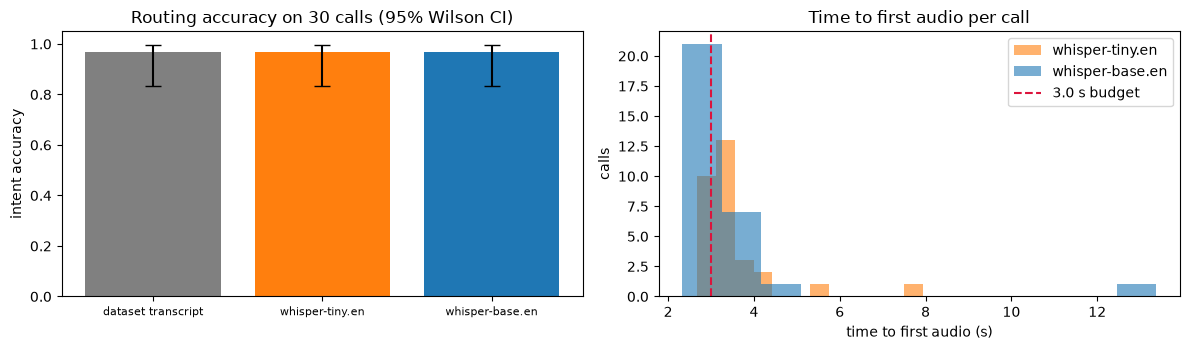

     true intent tiny.en intent base.en intent                                      base.en text
15  cash_deposit       pay_bill       pay_bill  How do we transfer money to a different account?


In [59]:
def wilson_ci(successes, n, z=1.96):
    p = successes / n
    centre = (p + z ** 2 / (2 * n)) / (1 + z ** 2 / n)
    half = z * math.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / (1 + z ** 2 / n)
    return centre - half, centre + half


result_rows = []
for source in ["dataset transcript", "tiny.en", "base.en"]:
    k = int(project[f"{source} correct"].sum())
    low_ci, high_ci = wilson_ci(k, len(project))
    row = {"transcripts from": source if source == "dataset transcript" else f"whisper-{source}", "intent accuracy": k / len(project),
           "95% CI": f"[{low_ci:.2f}, {high_ci:.2f}]", "no valid tool call": int(project[f"{source} intent"].isna().sum()),
           "LLM p50 s": project[f"{source} LLM s"].median()}
    if source in asr_pipes:
        row.update({"WER proxy": asr_summary[source]["disagreement with Google-ASR transcript (WER proxy)"],
                    "TTFA p50 s": project[f"{source} TTFA s"].median(), "TTFA p95 s": project[f"{source} TTFA s"].quantile(0.95)})
    result_rows.append(row)
results = pd.DataFrame(result_rows).set_index("transcripts from")
print(results.round(3).to_string())

budget_rows = {name: {stage: project[f"{name} {col}"].quantile(0.95) for stage, col in [("ASR", "ASR s"), ("LLM routing", "LLM s"), ("TTS first sentence", "TTS s")]}
               for name in asr_pipes}
budget_p95 = pd.DataFrame(budget_rows)
budget_p95.loc["endpointing"] = T_END + 0.032
print("\np95 per stage (s):\n" + budget_p95.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
accs = results["intent accuracy"]
errs = np.array([[a - wilson_ci(int(round(a * 30)), 30)[0], wilson_ci(int(round(a * 30)), 30)[1] - a] for a in accs]).T
axes[0].bar(results.index, accs, yerr=errs, capsize=6, color=["gray", "tab:orange", "tab:blue"])
axes[0].set(ylim=(0, 1.05), ylabel="intent accuracy", title="Routing accuracy on 30 calls (95% Wilson CI)")
axes[0].tick_params(axis="x", labelsize=8)
for name, color in zip(asr_pipes, ["tab:orange", "tab:blue"]):
    axes[1].hist(project[f"{name} TTFA s"], bins=12, alpha=0.6, color=color, label=f"whisper-{name}")
axes[1].axvline(3.0, ls="--", color="crimson", label="3.0 s budget")
axes[1].set(xlabel="time to first audio (s)", ylabel="calls", title="Time to first audio per call")
axes[1].legend()
plt.tight_layout()
plt.show()

errors = project[~project["base.en correct"] | ~project["tiny.en correct"]]
print(errors[["true intent", "tiny.en intent", "base.en intent", "base.en text"]].to_string())

### Step 6: Decision (computed with the rule stated up front)

In [60]:
acc_tiny, acc_base = results.loc["whisper-tiny.en", "intent accuracy"], results.loc["whisper-base.en", "intent accuracy"]
acc_upper = results.loc["dataset transcript", "intent accuracy"]
only_base = int((project["base.en correct"] & ~project["tiny.en correct"]).sum())
only_tiny = int((project["tiny.en correct"] & ~project["base.en correct"]).sum())
chosen = "base.en" if acc_base - acc_tiny >= 0.05 else "tiny.en"
p95_chosen = results.loc[f"whisper-{chosen}", "TTFA p95 s"]
print(f"1. Intent accuracy: tiny {acc_tiny:.0%}, base {acc_base:.0%} (difference {acc_base - acc_tiny:+.0%}; calls only base got right: {only_base}, "
      f"only tiny: {only_tiny}); routing on the dataset's Google-ASR transcripts: {acc_upper:.0%}.")
print(f"2. With 30 calls each accuracy has a wide CI ({results.loc['whisper-tiny.en', '95% CI']} for tiny), so small differences are not conclusive.")
print(f"3. Rule → choose whisper-{chosen} ({'base is ≥ 5 points better' if chosen == 'base.en' else 'base is not ≥ 5 points better'}).")
if p95_chosen <= 3.0:
    print(f"4. Latency: p95 time to first audio {p95_chosen:.2f}s ≤ 3.0 s → ✅ meets the budget on this machine.")
else:
    worst_stage = budget_p95[chosen].idxmax()
    print(f"4. Latency: p95 time to first audio {p95_chosen:.2f}s > 3.0 s → ❌ misses the budget; the largest p95 stage is '{worst_stage}' "
          f"({budget_p95.loc[worst_stage, chosen]:.2f}s) — fix that stage first (see Section 10's levers).")
stage_share = (budget_p95[chosen] / budget_p95[chosen].sum()).sort_values(ascending=False)
print(f"5. Share of the summed per-stage p95 for whisper-{chosen}: " + ", ".join(f"{stage} {share:.0%}" for stage, share in stage_share.items())
      + f" | ASR p95 {asr_summary[chosen]['ASR p95 s']:.2f}s vs {asr_summary['base.en' if chosen == 'tiny.en' else 'tiny.en']['ASR p95 s']:.2f}s for the other model.")
slow_asr_calls = int(sum((project[f"{name} ASR s"] / project["seconds"] > 1).sum() for name in asr_pipes))
if slow_asr_calls:
    print(f"⚠️ {slow_asr_calls} ASR calls took longer than their own audio (RTF > 1): the machine was short of memory or GPU time during this run, "
          "so p95 latencies here are inflated. Re-run on an idle machine before trusting the latency part of the decision.")

print(f"\nLLM calls this run: {LLM_STATS['real']} sent to the server, {LLM_STATS['replayed']} replayed from the cache | "
      f"notebook wall time so far {(time.perf_counter() - NOTEBOOK_START) / 60:.1f} min | peak memory of this Python process {peak_rss_gb():.2f} GB")

1. Intent accuracy: tiny 97%, base 97% (difference +0%; calls only base got right: 0, only tiny: 0); routing on the dataset's Google-ASR transcripts: 97%.
2. With 30 calls each accuracy has a wide CI ([0.83, 0.99] for tiny), so small differences are not conclusive.
3. Rule → choose whisper-tiny.en (base is not ≥ 5 points better).
4. Latency: p95 time to first audio 4.98s > 3.0 s → ❌ misses the budget; the largest p95 stage is 'LLM routing' (2.30s) — fix that stage first (see Section 10's levers).
5. Share of the summed per-stage p95 for whisper-tiny.en: LLM routing 50%, endpointing 27%, TTS first sentence 15%, ASR 7% | ASR p95 0.33s vs 0.73s for the other model.

LLM calls this run: 0 sent to the server, 103 replayed from the cache | notebook wall time so far 3.4 min | peak memory of this Python process 2.21 GB


**Stretch goals**

1. **Accents and channels:** add MInDS-14's `en-GB` and `en-AU` subsets (part of en-AU was collected over real phone calls) and report accuracy per locale.
2. **Noise:** mix babble at 5 dB into the calls (Section 7) and re-run the decision. Does base.en start to earn its place?
3. **Human references:** transcribe 30 calls yourself (with a second person for disagreements) and compute true WER instead of the Google-ASR proxy.
4. **Cheaper routing:** replace the LLM with a sentence-embedding classifier trained on other MInDS-14 rows and compare accuracy and latency.
5. **Semantic endpointing:** use Whisper's partial transcripts to end turns early when the request is complete, and measure cut-offs vs latency.

### 🗣️ How to talk about this in an interview

- "I built a cascaded voice FAQ agent (Whisper → gpt-oss with a tool → SpeechT5) and evaluated it on 30 real bank-caller recordings at 8 kHz, stratified across 14 intents, with the endpointing threshold tuned on 150 *other* recordings."
- "The dataset's transcripts turned out to be Google ASR output, so I treated WER against them as a proxy and judged models on intent accuracy with Wilson confidence intervals, plus time-to-first-audio percentiles."
- "I fixed the decision rule before looking at results: the smaller model wins unless the bigger one is 5 points more accurate, and the pick must meet a p95 latency budget. The table above has the numbers."
- "I broke time to first audio into per-stage p95s, so the fix targets whichever stage dominates on the target hardware (endpointing wait, LLM routing or TTS) instead of guessing, and the notebook flags runs where the machine itself was stalling."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. How does Whisper work?**

<details><summary>Show answer</summary>

- **30-second answer:** Whisper is an encoder–decoder transformer. Audio is resampled to 16 kHz, padded or cut to 30 s and turned into an 80-bin log-mel spectrogram (3,000 frames). Two convolution layers halve it to 1,500 positions for the encoder; the decoder then generates text tokens autoregressively with cross-attention to the audio, prompted by special tokens for language, task (transcribe/translate) and timestamps. It was trained on 680,000 hours of weakly supervised audio–transcript pairs from the web, which is why it's robust across accents and noise.
- **Go deeper:** Sizes range from tiny (39M) to large (1.55B); `.en` models are English-only; large-v3 uses 128 mel bins. Longer audio needs chunked or sequential long-form decoding with timestamp tokens. Word timestamps come from aligning cross-attention (DTW). Because the decoder is a language model, it can hallucinate on silence or noise; mitigate with VAD, `no_speech_threshold` and compression-ratio checks. Distil-Whisper shrinks the decoder for speed.
- **❌ Common wrong answer:** "It's a CTC model that labels each frame" or "it streams word by word natively."

</details>

**Q2. Compare CTC, attention encoder–decoder and transducer ASR.**

<details><summary>Show answer</summary>

- **30-second answer:** **CTC** predicts a token or blank per frame and collapses repeats; outputs are conditionally independent given the audio, so it's fast and streamable but benefits from an external LM. **Encoder–decoder** (Whisper) reads the whole chunk and generates tokens autoregressively with cross-attention: accurate and multilingual, but not natively streaming, and it can hallucinate. **Transducers** (RNN-T/TDT) add a prediction network over previous tokens and a joint network: streaming with token-history conditioning, the usual choice for on-device and low-latency production ASR.
- **Go deeper:** CTC and transducers enforce monotonic alignment, so they rarely invent long fluent passages. Encoder–decoders can be made streaming with chunked attention or used with local-agreement policies. Hybrid CTC/attention training is common. Decoding costs: CTC one pass; encoder–decoder O(tokens) decoder steps; transducer steps per frame and token.
- **❌ Common wrong answer:** "Transducers are just CTC with a bigger encoder" or "encoder–decoders are always better."

</details>

**Q3. What does WER measure, and what are its pitfalls?**

<details><summary>Show answer</summary>

- **30-second answer:** WER = (substitutions + deletions + insertions) / reference words, from a minimum-edit word alignment. Pitfalls: it depends heavily on **normalization** (casing, punctuation, "two" vs "2"; this notebook measured raw vs normalized WER differing by more than 10×), it can exceed 100%, every word counts the same (a wrong account digit = a wrong "um"), corpus WER ≠ mean per-utterance WER, and references can themselves be machine-made or wrong.
- **Go deeper:** Report the normalizer, the dataset and slices (noise, channel, accent, domain terms). Add CER for languages without spaces, entity or keyword error rates for what matters to the business (names, numbers), and task metrics downstream. Use bootstrap CIs to compare models on small sets.
- **❌ Common wrong answer:** "WER is the percentage of words that are wrong, so it can't be above 100%."

</details>

**Q4. Explain a neural TTS pipeline and what a vocoder does.**

<details><summary>Show answer</summary>

- **30-second answer:** Text normalization (numbers, dates, abbreviations) → tokens or phonemes → an **acoustic model** predicts a mel spectrogram with the right content, duration, pitch and speaker (conditioned on a speaker embedding) → a **vocoder** converts mel frames into a waveform. HiFi-GAN is a fast parallel GAN vocoder; WaveNet was autoregressive and slow.
- **Go deeper:** Autoregressive acoustic models (SpeechT5, Tacotron) are the latency bottleneck (measured here); non-autoregressive ones (FastSpeech-style) predict durations in parallel; VITS-style models train end to end; codec-LM TTS generates discrete audio tokens and decodes them with a neural codec. Evaluate naturalness with MOS (or UTMOS-style predictors) and intelligibility with round-trip ASR WER. Missing normalization makes numbers unpronounceable (Pitfall 4).
- **❌ Common wrong answer:** "The vocoder converts text to audio."

</details>

**Q5. How do VAD, endpointing and barge-in work in a voice agent?**

<details><summary>Show answer</summary>

- **30-second answer:** A **VAD** labels short frames as speech or not: energy thresholds, WebRTC's GMM VAD, or a neural VAD like Silero. **Endpointing** decides the turn is over, classically after a fixed silence (e.g. 0.5–1 s), increasingly with **semantic end-of-turn** models that read the transcript or prosody. **Barge-in** keeps VAD running on the mic while the bot speaks (after echo cancellation); sustained speech stops TTS, cancels pending generation and truncates the bot's message in history to what was heard.
- **Go deeper:** Short silence thresholds cut people off; long ones add latency to *every* turn. On the 150 MInDS-14 recordings here, the threshold needed to keep cut-offs ≤ 10% was far longer than typical "snappy" settings. Require a minimum speech duration to avoid false barge-ins on coughs and clicks; measure cut-off, false and missed barge-in rates on labelled calls.
- **❌ Common wrong answer:** "VAD tells you when the user has finished their sentence."

</details>

**Q6. Cascaded STT → LLM → TTS or a speech-to-speech model?**

<details><summary>Show answer</summary>

- **30-second answer:** **Cascaded**: modular, any LLM and tools, a text transcript to log, audit, redact and evaluate per stage; but latency adds up across three models and paralinguistic information (tone, emotion, hesitation) is lost. **Speech-to-speech** (OpenAI Realtime, Gemini Live, Moshi): lower latency, natural prosody, built-in turn-taking and interruptions; but less control, harder evaluation and compliance, and often higher cost. Choose cascaded when correctness, tools and auditability dominate (banking, healthcare); speech-to-speech when conversational feel dominates.
- **Go deeper:** Hybrids exist: speech-to-speech for conversation with tool calls into your backend, or cascaded with streaming everywhere. Full-duplex models (Moshi) model both speakers at once, removing explicit turns. Whatever you choose, keep transcripts for evaluation.
- **❌ Common wrong answer:** "Speech-to-speech is always better because it's end to end."

</details>

**Q7. What changes when the voice agent runs over a phone line?**

<details><summary>Show answer</summary>

- **30-second answer:** Audio is usually **8 kHz, 300–3,400 Hz, G.711 μ-law/A-law** (or a mobile codec), with packet loss, jitter, echo and background noise. You must decode μ-law, resample to the model's rate, and expect higher WER, especially on consonants, names and digits. Latency also includes the telephony network, SIP/RTP media handling and jitter buffers, and DTMF (keypad tones) is an alternative input for sensitive digits.
- **Go deeper:** Evaluate on real 8 kHz calls: this notebook's clean phone-line *simulation* changed WER only slightly on read speech, but real calls add codec artefacts, packet loss, echo and far-field noise. Consider models fine-tuned on telephony audio, use echo cancellation for barge-in, stream audio over WebSockets from the telephony provider, and keep PII like card numbers out of transcripts (DTMF masking, redaction). Wideband codecs (AMR-WB, Opus in VoIP) help when available.
- **❌ Common wrong answer:** "Just upsample to 16 kHz and it's the same as studio audio."

</details>

### 💻 Coding

**Q8. Implement WER with the alignment.**

<details><summary>Show answer</summary>

- **30-second answer:** Split into words; fill a (N+1)×(M+1) DP table with `D[i][j] = min(D[i-1][j-1] + (r≠h), D[i-1][j] + 1, D[i][j-1] + 1)`, initialized with `D[i][0] = i`, `D[0][j] = j`; WER = `D[N][M] / N`. Backtrack from the corner to label substitutions, deletions and insertions (Build It From Scratch (b)).
- **Go deeper:** O(N·M) time and memory (O(M) memory if you only need the distance). Ties mean the S/D/I split isn't unique, though WER is. Normalize both strings first; aggregate errors and reference words over the corpus instead of averaging utterance WERs; use `jiwer`/rapidfuzz in production.
- **❌ Common wrong answer:** Comparing words position by position (`sum(r != h for r, h in zip(ref, hyp))`), which breaks as soon as one word is inserted.

</details>

**Q9. How would you compute log-mel features, and why those parameters?**

<details><summary>Show answer</summary>

- **30-second answer:** Frame the 16 kHz signal into 25 ms windows every 10 ms (400/160 samples) with a Hann window, take |FFT|² (201 bins), apply ~80 triangular mel filters, take the log (with a floor), and normalize. 25 ms is short enough that speech is roughly stationary and long enough to resolve pitch harmonics; 10 ms hops track fast articulation.
- **Go deeper:** Match the model's exact recipe or accuracy silently drops: Whisper uses Slaney mel filters, log10, a max−8 clamp, (x+4)/4, center reflect padding and 30 s padding (reproduced to 1e-4 in this notebook). Other models use natural log, per-utterance mean/variance normalization or different mel counts. Feature pipelines are a classic training/serving skew bug.
- **❌ Common wrong answer:** "Just feed the raw FFT magnitudes; the model will figure it out."

</details>

### 🐛 Debugging Scenarios

**Q10. Users complain the voice bot interrupts them, and others say it feels slow. How do you debug it?**

<details><summary>Show answer</summary>

- **30-second answer:** Both symptoms point at **endpointing**, plus latency elsewhere. Pull traces for complaint calls: VAD decisions, silence threshold, when the bot started speaking relative to the caller's last word, and per-stage timings. Measure the pause distribution and cut-off rate vs threshold on real calls; if a fixed threshold can't satisfy both groups, add semantic end-of-turn detection. Then check the remaining TTFA stages at p95 (ASR, LLM first token, TTS first audio).
- **Go deeper:** Interruptions also come from false VAD triggers on noise (echo not cancelled, energy VAD) and over-eager barge-in; slowness also from long LLM prompts (lost prompt-cache hits), non-streamed TTS, slow tools without filler audio, or network hops. Segment by channel (speakerphone, mobile vs landline) and language, since pause behaviour differs. Ship changes behind an A/B test on cut-off rate and TTFA p95.
- **❌ Common wrong answer:** "Increase the silence timeout to 2 seconds" (fixes interruptions, makes every turn slower).

</details>

**Q11. Offline WER was 6%, but in production the transcripts are bad and the bot sometimes "hears" words when nobody is talking. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Mismatch between evaluation and production: 8 kHz μ-law audio (maybe decoded at the wrong sample rate or unscaled int16, see Pitfalls 1–2), noise and far-field mics, accents and domain vocabulary, and a different text normalization in the offline metric. Words on silence are **Whisper hallucinations**: noise-only audio reached the recognizer without a VAD gate.
- **Go deeper:** Log sample rate, codec and levels at ingestion; replay failing calls through the offline pipeline; label a production sample by slice; gate ASR with a neural VAD and use no-speech/log-probability thresholds; add domain prompts (Whisper `prompt_ids`) or fine-tune on in-domain audio; add noise augmentation. Treat a hallucinated "yes" as a safety issue for confirmations.
- **❌ Common wrong answer:** "Switch to Whisper large" without checking the input pipeline.

</details>

### 🏗️ Design

**Q12. How do you reduce a voice agent's latency?**

<details><summary>Show answer</summary>

- **30-second answer:** Budget time to first audio by stage and measure p50/p95. Then: semantic endpointing (don't wait a fixed second of silence), streaming ASR, a small fast model for routing and prompts that keep a stable prefix for **prompt caching**, stream LLM tokens into **sentence-level TTS**, speak approved answers directly when possible, play **filler audio** during slow tools, pre-warm models, and co-locate STT/LLM/TTS close to the telephony edge.
- **Go deeper:** Speculative execution (start the LLM on a likely-final transcript, cancel on barge-in), response caching for frequent questions, streaming TTS below the sentence level, and speech-to-speech models when control can be traded for speed. Watch p95: one slow LLM call dominates tails (Exercise 5), so add timeouts with graceful fallbacks.
- **❌ Common wrong answer:** "Use a bigger GPU" — the biggest wins are usually endpointing and streaming.

</details>

**Q13. How would you evaluate a voice agent before and after launch?**

<details><summary>Show answer</summary>

- **30-second answer:** A layered scorecard. **ASR:** WER/CER and entity error rate by slice on human-transcribed calls. **Turn-taking:** cut-off, false and missed barge-in rates. **Latency:** TTFA and per-stage p50/p95. **Understanding:** intent/tool and argument accuracy. **Task:** success/containment, escalation and repeat-call rates. **Speech:** MOS panels or automatic predictors plus round-trip intelligibility. **Safety:** PII redaction audits and spoofing tests.
- **Go deeper:** Offline: a frozen labelled set and simulated callers (TTS-voiced user simulators with noise and accents) for regression gates. Online: sampled human review, dashboards from traces, A/B tests on containment and CSAT. Report CIs; small sets (like 30 calls) can't separate close models.
- **❌ Common wrong answer:** "Measure WER and call it done."

</details>

**Q14. Design a voice agent for a bank's call centre.**

<details><summary>Show answer</summary>

- **30-second answer:** Telephony (SIP/PSTN provider) streams 8 kHz audio over WebSocket → media service with echo cancellation, neural VAD, semantic endpointing and barge-in → streaming ASR tuned for telephony → an LLM agent with **narrow tools** (card freeze, balance, FAQ lookup, transfer to human), approved answers for regulated content and identity verification via one-time codes, **never voice alone** → sentence-streamed TTS with a consented brand voice → human handoff with context. Plus traces with per-stage latency, PII redaction, recording retention rules and AI disclosure.
- **Go deeper:** SLOs: TTFA p95, containment, escalation, cut-off rate. Capacity: concurrent calls × (ASR + LLM + TTS) streams, so batch GPUs and autoscale on the peak hour. Safety: step-up verification for payments, DTMF entry for card numbers, deepfake-resistant authentication, fraud monitoring, rate limits on sensitive actions. Rollout: shadow mode on recorded calls, then a small canary with human fallback. See the call-centre case study in Agentic AI System Design.
- **❌ Common wrong answer:** "Connect the phone line to a realtime speech-to-speech API and give it access to the core banking system."

</details>

**Q15. What are the safety and ethical risks of voice AI (cloning, deepfakes, consent), and how do you handle them?**

<details><summary>Show answer</summary>

- **30-second answer:** Voice cloning enables impersonation, fraud ("CEO" calls, fake relatives) and non-consensual deepfakes; voices are biometric personal data. Use only voices with explicit documented consent and licences (check model *and* voice licences, e.g. CC BY-NC weights aren't for products), disclose that callers talk to an AI, never authenticate by voice alone, add anti-spoofing checks and step-up verification, watermark or log synthetic audio, and protect recordings and transcripts as sensitive data.
- **Go deeper:** Regulation is active: the EU AI Act has transparency duties for AI interacting with people and for synthetic media; the US FCC ruled in 2024 that AI-generated voices in robocalls fall under TCPA restrictions. ASVspoof benchmarks spoofing countermeasures. Red-team with synthetic callers, and restrict voice-cloning features behind consent verification.
- **❌ Common wrong answer:** "If the voice sounds natural enough, users won't mind" or "voice biometrics stop deepfakes."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Each answer was verified by running it in this notebook's environment.)

**1.** How many bytes does one minute of raw 16 kHz, 16-bit mono PCM take: `16_000 * 60 * 2`?
<details><summary>Answer</summary>

`1920000` bytes (~1.9 MB). Float32 in memory doubles it.
</details>

**2.** A 5 kHz tone is sampled at 8 kHz without filtering. At what frequency does its FFT peak appear?
<details><summary>Answer</summary>

**3,000 Hz**: it's above the 4 kHz Nyquist frequency, so it aliases to 8,000 − 5,000 Hz.
</details>

**3.** `jiwer.wer("a b c", "a x c d")`
<details><summary>Answer</summary>

`0.6666…` — one substitution (b→x) and one insertion (d) over 3 reference words.
</details>

**4.** What shape does `WhisperFeatureExtractor(...)(np.zeros(7 * 16000), sampling_rate=16000, return_tensors="np").input_features` have?
<details><summary>Answer</summary>

`(1, 80, 3000)` — Whisper always pads to 30 s: 80 mel bins × 3,000 frames.
</details>

**5.** HTK mel value of 700 Hz: `2595 * np.log10(1 + 700 / 700)`?
<details><summary>Answer</summary>

`781.17…` = 2595 · log10(2).
</details>

## 📚 Resources

### 📖 Official Docs
- [Welcome to the Hugging Face Audio course!](https://huggingface.co/learn/audio-course/en/chapter0/introduction) — free course on audio data, ASR, TTS and audio transformers; start with [Introduction to audio data](https://huggingface.co/learn/audio-course/en/chapter1/audio_data)
- [Whisper · Hugging Face](https://huggingface.co/docs/transformers/model_doc/whisper) and [SpeechT5 · Hugging Face](https://huggingface.co/docs/transformers/model_doc/speecht5) — the transformers model docs used here
- [openai/whisper-base.en · Hugging Face](https://huggingface.co/openai/whisper-base.en) — the Whisper model card (training data, limitations, intended use) · [microsoft/speecht5_tts · Hugging Face](https://huggingface.co/microsoft/speecht5_tts) — the SpeechT5 card
- [Welcome to the TorchCodec documentation!](https://meta-pytorch.org/torchcodec/stable/index.html) — audio decoding and resampling · [python-soundfile documentation](https://python-soundfile.readthedocs.io/)
- [GitHub — jitsi/jiwer](https://github.com/jitsi/jiwer) — WER/CER, alignments and text transforms
- [GitHub — snakers4/silero-vad](https://github.com/snakers4/silero-vad) — the neural VAD run in Section 9 · [GitHub — wiseman/py-webrtcvad](https://github.com/wiseman/py-webrtcvad) — the WebRTC VAD
- [Introduction | LiveKit Documentation](https://docs.livekit.io/agents/) and [Turns overview | LiveKit Documentation](https://docs.livekit.io/agents/build/turns/) — LiveKit Agents and its turn detection
- [Pipecat Documentation](https://docs.pipecat.ai/) — pipelines of frame processors for voice agents
- [Getting started with the Realtime API | OpenAI API](https://developers.openai.com/api/docs/guides/realtime) and [Voice agents | OpenAI API](https://developers.openai.com/api/docs/guides/voice-agents) — speech-to-speech sessions, turn detection, tools
- [Gemini Live API overview](https://ai.google.dev/gemini-api/docs/live-api) — bidirectional audio streaming with Gemini
- [G.711: Pulse code modulation (PCM) of voice frequencies](https://www.itu.int/rec/T-REC-G.711) and [P.800: Methods for subjective determination of transmission quality](https://www.itu.int/rec/T-REC-P.800) — the telephony codec and the MOS standard

### 🎥 Videos
- [Grant Sanderson (3Blue1Brown) — But what is the Fourier Transform? A visual introduction.](https://www.youtube.com/watch?v=spUNpyF58BY) (20 min) — the intuition behind spectrograms and Section 3
- [AI Engineer — Engineering voice agents: Latency, quality, and scale — Rishabh Bhargava, Together AI](https://www.youtube.com/watch?v=N7b1PJc7SFc) (25 min) — production latency budgets and model choices for voice agents
- [Intro to Voice AI and Voice Agents: A Conversation with Kwindla Hultman-Kramer](https://www.youtube.com/watch?v=UfaXPwWLCnY) (50 min) — the creator of Pipecat on turn-taking, cascaded vs speech-to-speech and what breaks in production

### 📄 Papers
- [Radford et al. (2022) — Robust Speech Recognition via Large-Scale Weak Supervision](https://arxiv.org/abs/2212.04356) (Whisper)
- [Ao et al. (2021) — SpeechT5: Unified-Modal Encoder-Decoder Pre-Training for Spoken Language Processing](https://arxiv.org/abs/2110.07205)
- [Panayotov et al. (2015) — LibriSpeech: an ASR corpus based on public domain audio books (ICASSP PDF)](https://www.danielpovey.com/files/2015_icassp_librispeech.pdf)
- [Gerz et al. (2021) — Multilingual and Cross-Lingual Intent Detection from Spoken Data](https://arxiv.org/abs/2104.08524) (MInDS-14)
- [Graves et al. (2006) — Connectionist Temporal Classification (ICML PDF)](https://www.cs.toronto.edu/~graves/icml_2006.pdf) · [Graves (2012) — Sequence Transduction with Recurrent Neural Networks](https://arxiv.org/abs/1211.3711) (RNN-T)
- [Baevski et al. (2020) — wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations](https://arxiv.org/abs/2006.11477) · [Gulati et al. (2020) — Conformer: Convolution-augmented Transformer for Speech Recognition](https://arxiv.org/abs/2005.08100)
- [Kong et al. (2020) — HiFi-GAN: Generative Adversarial Networks for Efficient and High Fidelity Speech Synthesis](https://arxiv.org/abs/2010.05646)
- [Gandhi et al. (2023) — Distil-Whisper: Robust Knowledge Distillation via Large-Scale Pseudo Labelling](https://arxiv.org/abs/2311.00430)
- [Défossez et al. (2024) — Moshi: a speech-text foundation model for real-time dialogue](https://arxiv.org/abs/2410.00037)
- [Reddy et al. (2019) — A scalable noisy speech dataset and online subjective test framework](https://arxiv.org/abs/1909.08050) (MS-SNSD) · [Saeki et al. (2022) — UTMOS: UTokyo-SaruLab System for VoiceMOS Challenge 2022](https://arxiv.org/abs/2204.02152) · [Reddy et al. (2020) — DNSMOS: A Non-Intrusive Perceptual Objective Speech Quality metric](https://arxiv.org/abs/2010.15258)

### 📘 Books & Courses
- [Voice AI & Voice Agents | An Illustrated Primer](https://voiceaiandvoiceagents.com/) — a free, practical guide to building voice agents (latency, turn detection, pipelines)
- [Hugging Face Audio course — Pre-trained models for automatic speech recognition](https://huggingface.co/learn/audio-course/en/chapter5/asr_models) and [Pre-trained models for text-to-speech](https://huggingface.co/learn/audio-course/en/chapter6/pre-trained_models)
- [Fine-Tune Whisper For Multilingual ASR with 🤗 Transformers](https://huggingface.co/blog/fine-tune-whisper) — the next step when a slice of your data needs a better model
- [LiveKit — Using a transformer to improve end of turn detection](https://blog.livekit.io/using-a-transformer-to-improve-end-of-turn-detection) — semantic endpointing explained with measurements
- [Festvox: CMU_ARCTIC Databases](http://www.festvox.org/cmu_arctic/) — the voice corpus behind the speaker embedding, and its licence

### 🏋️ Practice
- [Open ASR Leaderboard — hf-audio](https://huggingface.co/spaces/hf-audio/open_asr_leaderboard) — compare ASR models on WER and speed, then test the top ones on your own audio
- [PolyAI/minds14 · Datasets at Hugging Face](https://huggingface.co/datasets/PolyAI/minds14) — extend the Mini Project to other English locales and languages
- [GitHub — pipecat-ai/pipecat](https://github.com/pipecat-ai/pipecat) and [GitHub — livekit/agents](https://github.com/livekit/agents) — run their example voice agents and compare latency with this notebook's budget
- [ASVspoof](https://www.asvspoof.org/) — spoofing and deepfake detection challenges and datasets

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Sample rate, bit depth | how audio is stored | 16 kHz × 16 bit = 256 kbit/s; phone: 8 kHz 8-bit μ-law = 64 kbit/s; `AudioDecoder(bytes, sample_rate=...)`, `sf.read(..., dtype="float32")` |
| Nyquist & resampling | avoid aliasing | max frequency = sr/2; filter before downsampling: `scipy.signal.resample_poly` |
| Spectrogram → log-mel → MFCC | speech features | 25 ms window, 10 ms hop, `|FFT|²` → mel filters → log; MFCC = DCT(log-mel)[:13]; Whisper: 80 × 3000 |
| ASR families | audio → text | CTC (blank + collapse) · encoder–decoder (Whisper) · transducer (streaming) |
| Whisper in transformers | transcription | `pipeline("automatic-speech-recognition", model=..., device=...)`; `return_timestamps=True/"word"`; `chunk_length_s=30` |
| WER | ASR quality | (S + D + I) / N after a fixed normalizer; `jiwer.process_words`; corpus WER, bootstrap CIs, slices |
| RTF & latency | speed | RTF = processing time / audio time; per-turn p50/p95 |
| Noise robustness | real conditions | SNR = 10·log10(Ps/Pn); scale = √(Ps / (Pn·10^(SNR/10))) |
| TTS | text → audio | normalize text → acoustic model (mel) → vocoder (HiFi-GAN); `SpeechT5ForTextToSpeech.generate(ids, speaker_embeddings=...)` |
| Round-trip WER | TTS intelligibility proxy | TTS → ASR → WER against the input text |
| VAD | speech or not | energy threshold + hangover · WebRTC GMM · Silero ONNX (32 ms chunks, state + context) |
| Endpointing | when the turn ends | silence threshold T trades cut-offs vs latency; semantic end-of-turn models |
| Barge-in | handle interruptions | VAD on mic during TTS (with AEC), min speech duration, stop + truncate history |
| Voice agent latency | time to first audio | endpointing + ASR + LLM (tool, first sentence) + TTS first sentence; stream by sentence |
| Evaluation & ops | ship safely | scorecard (WER slices, turn-taking, TTFA p95, task success, MOS proxies), PII redaction, no voice-only auth, consent |

## ➡️ What's Next

**🎓 This completes the Multimodal & Generative Models module.** You can now generate images with diffusion models, build retrieval over images and documents with vision-language models, and build, time and evaluate voice agents.

**Next in the study plan: [11 Data Processing · Polars](../11_Data_Processing/01_Polars.ipynb)** — a change of pace to fast DataFrame engineering. Every model in this module was only as good as the data pipeline feeding it, and Polars is how you prepare large datasets quickly.

**Practise what you learned here:**
- [Multi-Agent System Project](../13_Capstone_Projects/05_Multi_Agent_System_Project.ipynb) — put a voice front end on a multi-agent capstone.
- [Agentic AI System Design](../15_Interview_Prep/08_Agentic_AI_System_Design.ipynb) — Case Study H designs a **call-centre voice agent** end to end. Try it after this notebook and compare your latency budget with the one you measured here.